# `uq_analysis`: file-first UQ analysis (memory-friendly)

This notebook avoids building a single giant `df_all`.
Instead, it reads each eval CSV (ID + OOD) one at a time and produces small summary tables.

Key principle: **calibrate on ID validation only**, then apply calibration to ID test + OOD test.


In [73]:
# Setup + configuration.
# - Ensures project imports work from `<root>/notebooks`.
# - Selects the run prefix/tag to analyze (IMPORTANT: do not mix tags, e.g. _xs_ with _m_).
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
import json
import sys
import numpy as np
import pandas as pd
import yaml
pd.set_option('display.max_columns', 500)
# Resolve project root
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scripts").is_dir() and (NOTEBOOK_DIR / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts").is_dir() and (NOTEBOOK_DIR.parent / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# ----------------
# USER KNOBS (defaults pulled from config)
# ----------------
CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis.yaml"
EVAL_ROOT = PROJECT_ROOT / "outputs" / "evals"
cfg: Dict = {}
if CONFIG_PATH.exists():
    try:
        cfg = yaml.safe_load(CONFIG_PATH.read_text()) or {}
    except Exception as e:
        print(f"[warn] failed to read config {CONFIG_PATH}: {e}")
settings_cfg = cfg.get('settings', {}) if isinstance(cfg, dict) else {}
def _normalize_prefix(v: Optional[str]) -> str:
    if not v:
        return ''
    p = str(v)
    if not p.startswith('_'):
        p = '_' + p
    return p
# Allow either `run_prefix` or legacy `run_tag` from settings/top-level; accept `_l` or `_l_`
run_prefix_raw = settings_cfg.get('run_prefix') or cfg.get('run_prefix')
run_tag_raw = settings_cfg.get('run_tag') or cfg.get('run_tag')
RUN_PREFIX = _normalize_prefix(run_prefix_raw or run_tag_raw)
RUN_TAG = RUN_PREFIX or '_m_'
# Allow overriding eval_root in config
settings_eval_root = settings_cfg.get('eval_root') or cfg.get('eval_root')
if settings_eval_root:
    EVAL_ROOT = (PROJECT_ROOT / settings_eval_root).resolve()
# Datasets (labels must match what the eval scripts used in filenames)
ID_LABEL = cfg.get('id_label', 'id')
OOD_LABELS_PRIMARY = cfg.get('ood_labels_primary', [])
OOD_LABELS_SECONDARY = cfg.get('ood_labels_secondary', [])
OOD_LABELS = cfg.get('ood_labels', ['knn_hard'])
# Large-error definition: top quantile of abs error under point baseline on ID test
LARGE_ERROR_QUANTILE = settings_cfg.get('large_error_quantile', cfg.get('large_error_quantile', 0.90))
# Calibration parameters (ID-val only)
N_RELIABILITY_BINS = cfg.get('n_reliability_bins', 10)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('EVAL_ROOT   :', EVAL_ROOT)
print('RUN_PREFIX  :', RUN_PREFIX)
print('RUN_TAG     :', RUN_TAG)
print('CONFIG_PATH :', CONFIG_PATH)


PROJECT_ROOT: /home/canelo/uncertainty_quantification
EVAL_ROOT   : /home/canelo/uncertainty_quantification/outputs/evals
RUN_PREFIX  : _l
RUN_TAG     : _l
CONFIG_PATH : /home/canelo/uncertainty_quantification/configs/uq_analysis.yaml


In [74]:
# Optional overrides (set to None to keep config defaults)
OVERRIDES = {
    # "run_prefix": None,  # e.g., "_l" or "_l_"
    # "ood_labels": None,  # e.g., ["knn_hard"]
}

if OVERRIDES:
    if OVERRIDES.get("run_prefix") is not None:
        RUN_PREFIX = OVERRIDES["run_prefix"]
        RUN_TAG = RUN_PREFIX
    if OVERRIDES.get("ood_labels") is not None:
        OOD_LABELS = OVERRIDES["ood_labels"]



In [75]:
# Discover eval directories for the selected RUN_TAG.
# This is intentionally simple and explicit to avoid mixing tags.

@dataclass(frozen=True)
class MethodSpec:
    key: str
    label: str
    head_type: str
    aleatoric_source: str
    epistemic_source: str
    kind: str  # "regression" | "ensemble" | "nf" | "dido"


# Core methods (as agreed): analytic + MC + ensemble (+ point baseline)
METHODS_CORE: List[MethodSpec] = [
    MethodSpec("point", "Point", "point", "none", "none", "regression"),
    MethodSpec("lpl_analytic", "Laplace (analytic)", "laplace", "analytic", "none", "regression"),
    MethodSpec("lpl_mc", "Laplace + MC", "laplace", "analytic", "mc", "regression"),
    MethodSpec("esm_lpl", "Laplace + ensemble", "laplace", "analytic", "ensemble", "ensemble"),
    MethodSpec("gau_analytic", "Gauss (analytic)", "gauss", "analytic", "none", "regression"),
    MethodSpec("gau_mc", "Gauss + MC", "gauss", "analytic", "mc", "regression"),
    MethodSpec("esm_gau", "Gauss + ensemble", "gauss", "analytic", "ensemble", "ensemble"),
]

# Auxiliary methods: NF, DIDO
METHODS_AUX: List[MethodSpec] = [
    MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf"),
    MethodSpec("nf_gau", "Gauss (NF)", "gauss", "nf", "none", "nf"),
    MethodSpec("dido_lpl", "Laplace + DIDO", "laplace", "analytic", "dido", "dido"),
    MethodSpec("dido_gau", "Gauss + DIDO", "gauss", "analytic", "dido", "dido"),
]

ENABLE_METHODS = cfg.get("enable_methods", {})
core_map = {
    "point": "point",
    "lpl_analytic": "laplace_analytic",
    "lpl_mc": "laplace_mc",
    "esm_lpl": "laplace_ensemble",
    "gau_analytic": "gauss_analytic",
    "gau_mc": "gauss_mc",
    "esm_gau": "gauss_ensemble",
}
aux_map = {
    "nf_lpl": "nf_laplace",
    "nf_gau": "nf_gauss",
    "dido_lpl": "dido_laplace",
    "dido_gau": "dido_gauss",
}
METHODS_CORE = [m for m in METHODS_CORE if ENABLE_METHODS.get(core_map.get(m.key, m.key), True)]
METHODS_AUX = [m for m in METHODS_AUX if ENABLE_METHODS.get(aux_map.get(m.key, m.key), True)]

# Use run_patterns/runs from config; prefix injected from RUN_PREFIX set in setup cell
run_patterns = cfg.get("run_patterns", {}) or {
    "point": "point{prefix}*",
    "laplace_analytic": "lpl{prefix}*",
    "laplace_mc": "lpl{prefix}*",
    "gauss_analytic": "gau{prefix}*",
    "gauss_mc": "gau{prefix}*",
    "laplace_ensemble": "esm_laplace_lpl{prefix}*",
    "gauss_ensemble": "esm_gauss_gau{prefix}*",
    "nf_laplace": "nf_lpl{prefix}*",
    "nf_gauss": "nf_gau{prefix}*",
    "dido_laplace": "dido_lpl{prefix}*",
    "dido_gauss": "dido_gau{prefix}*",
}
run_overrides = cfg.get("runs", {}) or {}


def _pick_latest_dir(glob_pat: str):
    matches = sorted(EVAL_ROOT.glob(glob_pat))
    return matches[-1] if matches else None


def _resolve_run(pattern_key: str):
    explicit = run_overrides.get(pattern_key)
    if explicit:
        p = Path(explicit)
        return p if p.exists() else None
    pat = run_patterns.get(pattern_key)
    if not pat:
        return None
    pat = pat.format(prefix=RUN_PREFIX)
    return _pick_latest_dir(pat)

# map spec.key prefix to pattern keys
RUN_DIRS: Dict[str, Path] = {}
run_map = {
    "point": "point",
    "lpl": "laplace_mc",
    "gau": "gauss_mc",
    "esm_lpl": "laplace_ensemble",
    "esm_gau": "gauss_ensemble",
    "nf_lpl": "nf_laplace",
    "nf_gau": "nf_gauss",
    "dido_lpl": "dido_laplace",
    "dido_gau": "dido_gauss",
}
for key, pattern_key in run_map.items():
    RUN_DIRS[key] = _resolve_run(pattern_key)

print(f"Resolved eval dirs (prefix='{RUN_PREFIX}'):")
for k, p in RUN_DIRS.items():
    print(f"  {k:10s}: {p}")



Resolved eval dirs (prefix='_l'):
  point     : outputs/evals/point_l_20251220-010530_303656
  lpl       : outputs/evals/lpl_l_20251220-191248_303809
  gau       : outputs/evals/gau_l_20251220-192327_303825
  esm_lpl   : outputs/evals/esm_laplace_lpl_l_20251221-004022_304164
  esm_gau   : outputs/evals/esm_gauss_gau_l_20251221-004030_304170
  nf_lpl    : outputs/evals/nf_lpl_l_20251221-222438_304508
  nf_gau    : outputs/evals/nf_gau_l_20251221-204946_304381
  dido_lpl  : outputs/evals/dido_lpl_l_20251221-004441_304174
  dido_gau  : outputs/evals/dido_gau_l_20251221-004536_304175


In [76]:
# Helpers to load *one* eval file at a time and map to a common schema.
# This is the core memory-saving change: no global concat.
def _read_csv_usecols(path: Path, usecols: List[str]) -> pd.DataFrame:
    # Use intersection only to be robust to minor schema changes.
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    keep = [c for c in usecols if c in cols]
    return pd.read_csv(path, usecols=keep)
def _first_existing(base: Path, names: List[str]) -> Path:
    for name in names:
        p = base / name
        if p.exists():
            return p
    return base / names[0]

def load_id_regression(run_dir: Path, split: str, *, variant: str) -> pd.DataFrame:
    """variant: "point" | "analytic" | "mc" """
    run_dir = Path(run_dir)
    if variant == "point":
        path = _first_existing(run_dir, [f"{split}_preds.csv", f"preds_{split}.csv"])
        df = _read_csv_usecols(path, ["id", "split", "head_type", "y_true", "y_pred"])
        df = df.rename(columns={"y_pred": "mu"})
        df["sigma_ale_raw"] = np.nan
        df["sigma_epi_raw"] = np.nan
        return df

    if variant == "analytic":
        candidates = [f"{split}_preds.csv", f"preds_{split}.csv", f"mc_preds_{split}.csv"]
        path = _first_existing(run_dir, candidates)
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_det",
                "y_pred_mc_mean",
                "sigma_ale_raw",
                "sigma_ale_orig",
                "sigma_epi_raw",
                "sigma_epi_orig",
            ],
        )
        if "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        elif "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
            df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
        if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
            df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
        df["sigma_epi_raw"] = np.nan  # analytic ignores epistemic
        if "mu" not in df.columns:
            df["mu"] = np.nan
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        return df

    if variant == "mc":
        candidates = [f"mc_preds_{split}.csv", f"{split}_preds.csv", f"preds_{split}.csv"]
        path = _first_existing(run_dir, candidates)
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_mc_mean",
                "y_pred_det",
                "sigma_ale_orig",
                "sigma_ale_raw",
                "sigma_epi_orig",
                "sigma_epi_raw",
            ],
        )
        # Prefer MC mean; if missing, derive from MC samples, else fall back to det
        if "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        else:
            mc_cols = [c for c in df.columns if c.startswith("y_pred_mc_")]
            if mc_cols:
                df["mu"] = df[mc_cols].mean(axis=1)
            elif "y_pred_det" in df.columns:
                df = df.rename(columns={"y_pred_det": "mu"})
            else:
                df["mu"] = np.nan
        if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
            df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
        if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
            df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        if "sigma_epi_raw" not in df.columns:
            df["sigma_epi_raw"] = np.nan
        return df

    raise ValueError(f"unknown variant={variant}")

def load_id_ensemble(run_dir: Path, split: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    fname = f"ensemble_preds_{split}.csv"
    path = run_dir / fname
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            # Newer ensemble eval schema
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            # Older/alternate names
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    # Standardize prediction
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    # Ensure required columns exist
    if "mu" not in df.columns:
        df["mu"] = np.nan
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df
def load_id_nf(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "flow_eval_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df
def load_id_dido(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "dido_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df
def load_ood_regression(run_dir: Path, label: str, *, variant: str | None = None) -> pd.DataFrame:
    """Load OOD eval outputs for a base regression run.
    variant:
      - None / "analytic" / "point": reads `ood_<label>_test.csv`
      - "mc": reads the same `ood_<label>_test.csv` (MC columns inline; legacy `mc_preds_ood_<label>.csv` still accepted)
    """
    run_dir = Path(run_dir)
    if variant == "mc":
        candidates = [
            f"ood_{label}_test.csv",      # primary
            f"mc_preds_ood_{label}.csv",  # legacy
        ]
        path = _first_existing(run_dir, candidates)
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_mc_mean",
                "y_pred_det",
                "y_pred",
                "sigma_ale_orig",
                "sigma_ale_raw",
                "sigma_epi_orig",
                "sigma_epi_raw",
            ],
        )
        if "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        elif "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        elif "y_pred" in df.columns:
            df = df.rename(columns={"y_pred": "mu"})
        else:
            df["mu"] = np.nan
        if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
            df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
        if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
            df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        if "sigma_epi_raw" not in df.columns:
            df["sigma_epi_raw"] = np.nan
        return df
    path = run_dir / f"ood_{label}_test.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_det",
            "y_pred_mean",
            "y_pred_method",
            "y_pred",
            "y_pred_mc_mean",
            "sigma_ale_raw",
            "sigma_epi_raw",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    # Standardize prediction -> mu
    if "y_pred_det" in df.columns:
        df = df.rename(columns={"y_pred_det": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    elif "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "mu"})
    elif "y_pred_mc_mean" in df.columns:
        df = df.rename(columns={"y_pred_mc_mean": "mu"})
    else:
        raise ValueError(f"No prediction column found in {path}")
    # Standardize sigmas (analytic heads typically only have aleatoric)
    if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df
def load_ood_nf(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"flow_eval_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df
def load_ood_dido(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"dido_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df


## Large Error (from point model)

In [77]:
# Compute the large-error threshold tau from the point baseline on ID test.
# This tau is used across methods (method-agnostic definition).

point_dir = RUN_DIRS.get("point")
if point_dir is None:
    raise FileNotFoundError("No point eval dir found for RUN_TAG")

df_point_test = load_id_regression(point_dir, split="test", variant="point")
abs_err_point = np.abs(df_point_test["y_true"].to_numpy(float) - df_point_test["mu"].to_numpy(float))
LARGE_ERROR_TAU = float(np.quantile(abs_err_point, LARGE_ERROR_QUANTILE))
print(f"LARGE_ERROR_TAU (point ID test, q={LARGE_ERROR_QUANTILE:.2f}): {LARGE_ERROR_TAU:.4f}")


LARGE_ERROR_TAU (point ID test, q=0.95): 7939.7084


In [78]:
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    def _require(key: str) -> Path:
        p = RUN_DIRS.get(key)
        if p is None:
            raise FileNotFoundError(f"No eval dir for {key}; check run_prefix/runs config")
        return p
    if spec.key == "point":
        return load_id_regression(_require("point"), split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(_require("lpl"), split="test", variant="mc")
        return load_id_regression(_require("lpl"), split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(_require("gau"), split="test", variant="mc")
        return load_id_regression(_require("gau"), split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(_require("esm_lpl"), split="test")
        return load_id_ensemble(_require("esm_gau"), split="test")
    raise ValueError(f"Unhandled core spec: {spec}")



In [79]:
# Compute core ID-test metrics (file-first).
# Produces a small summary table; does NOT build a giant df.
from scripts.uq_eval import gaussian_nll
from scipy.stats import norm
def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))
# Calibration maps (may be empty if calibration not run)
try:
    alpha
except NameError:
    alpha = {}
try:
    beta
except NameError:
    beta = {}
if not alpha:
    alpha_cfg = cfg.get("alpha", {})
    alpha = alpha_cfg if isinstance(alpha_cfg, dict) else {}
if not beta:
    beta_cfg = cfg.get("beta", {})
    beta = beta_cfg if isinstance(beta_cfg, dict) else {}
if not alpha and not beta:
    print("[info] No calibration parameters found; using raw sigmas (alpha=beta=1).")
def calibrated_sigmas(
    *,
    head_type: str,
    ale_src: str,
    epi_src: str,
    sigma_ale_raw: np.ndarray,
    sigma_epi_raw: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # If NF doesn't have its own alpha (no val flow files), fall back to analytic alpha.
    def _alpha_lookup(ht: str, asrc: str) -> float:
        if (ht, asrc) in alpha:
            return float(alpha[(ht, asrc)])
        if asrc == "nf" and (ht, "analytic") in alpha:
            return float(alpha[(ht, "analytic")])
        return 1.0
    a = _alpha_lookup(head_type, ale_src)
    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    s_a2 = a * (np.asarray(sigma_ale_raw, float) ** 2)
    s_e2 = b * (np.asarray(sigma_epi_raw, float) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["lpl"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["lpl"], split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["gau"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["gau"], split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(RUN_DIRS["esm_lpl"], split="test")
        return load_id_ensemble(RUN_DIRS["esm_gau"], split="test")
    raise ValueError(f"Unhandled core spec: {spec}")


## Calibration

In [80]:
# Fit simple alpha/beta calibration on ID validation splits and print results.
# Toggle CALIB_OBJ between "nll" and "crps" to choose the objective.
# If calibration is not desired, skip this cell; downstream will use raw sigmas.

import numpy as np
import pandas as pd
from scipy.stats import norm as _norm

CALIB_OBJ = "nll"  # "nll" | "crps"

def _gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]; mu = mu[mask]; sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * _norm.cdf(z) - 1) + 2 * _norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def method_id_val_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="val", variant="point")
    if spec.key.startswith("lpl_"):
        return load_id_regression(RUN_DIRS["lpl"], split="val", variant="mc" if spec.epistemic_source == "mc" else "analytic")
    if spec.key.startswith("gau_"):
        return load_id_regression(RUN_DIRS["gau"], split="val", variant="mc" if spec.epistemic_source == "mc" else "analytic")
    if spec.epistemic_source == "ensemble":
        return load_id_ensemble(RUN_DIRS["esm_lpl" if spec.head_type == "laplace" else "esm_gau"], split="val")
    raise ValueError(f"Unhandled spec for val load: {spec}")

def _fit_scale_crps(y, mu, s_a2, s_e2, mask):
    scales = np.logspace(-2, 2, num=9)
    best_crps = float("inf")
    best_a = best_b = 1.0
    y_m = y[mask]; mu_m = mu[mask]
    for a_mult in scales:
        for b_mult in scales:
            sigma = np.sqrt(np.maximum(a_mult * s_a2 + b_mult * s_e2, 0.0))
            crps_val = _gaussian_crps_mean(y_m, mu_m, sigma[mask])
            if np.isfinite(crps_val) and crps_val < best_crps:
                best_crps, best_a, best_b = crps_val, a_mult, b_mult
    return best_a, best_b

alpha = {}
beta = {}

for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    try:
        df_val = method_id_val_frame(spec)
    except FileNotFoundError as e:
        print(f"[skip calib] {spec.label}: {e}")
        continue

    y = df_val["y_true"].to_numpy(float)
    mu = df_val["mu"].to_numpy(float)
    err2 = (y - mu) ** 2
    s_a = df_val.get("sigma_ale_raw", pd.Series(np.nan, index=df_val.index)).to_numpy(float)
    s_e = df_val.get("sigma_epi_raw", pd.Series(0.0, index=df_val.index)).fillna(0.0).to_numpy(float)
    s_a2 = np.nan_to_num(s_a, nan=0.0) ** 2
    s_e2 = np.nan_to_num(s_e, nan=0.0) ** 2

    mask = np.isfinite(err2) & np.isfinite(s_a2) & np.isfinite(s_e2)
    if not np.any(mask):
        print(f"[skip calib] {spec.label}: no finite data")
        continue

    if CALIB_OBJ.lower() == "crps":
        if spec.epistemic_source in {"none", "dido"}:
            denom = float(np.nanmean(s_a2[mask]))
            a = float(np.nanmean(err2[mask]) / denom) if denom > 0 else 1.0
            b = 0.0
        else:
            a, b = _fit_scale_crps(y, mu, s_a2, s_e2, mask)
    else:  # NLL-like (least squares on err^2 vs variance)
        if spec.epistemic_source in {"none", "dido"}:
            denom = float(np.nanmean(s_a2[mask]))
            a = float(np.nanmean(err2[mask]) / denom) if denom > 0 else 1.0
            b = 0.0
        else:
            X = np.stack([s_a2[mask], s_e2[mask]], axis=1)
            y_vec = err2[mask]
            try:
                coeffs, *_ = np.linalg.lstsq(X, y_vec, rcond=None)
                a = float(max(coeffs[0], 1e-8)); b = float(max(coeffs[1], 1e-8))
            except Exception:
                a, b = 1.0, 1.0

    alpha[(spec.head_type, spec.aleatoric_source)] = a
    beta[(spec.head_type, spec.aleatoric_source, spec.epistemic_source)] = b
    print(f"[calib/{CALIB_OBJ}] {spec.label}: alpha={a:.4g}, beta={b:.4g} (n={mask.sum()})")

print("Calibration maps set for downstream cells.")


[calib/nll] Laplace (analytic): alpha=0.5494, beta=0 (n=12679)


[calib/nll] Laplace + MC: alpha=0.1941, beta=0.953 (n=12679)
[calib/nll] Laplace + ensemble: alpha=0.2444, beta=1e-08 (n=12679)
[calib/nll] Gauss (analytic): alpha=0.4408, beta=0 (n=12679)
[calib/nll] Gauss + MC: alpha=0.2604, beta=0.1585 (n=12679)
[calib/nll] Gauss + ensemble: alpha=0.4387, beta=1e-08 (n=12679)
Calibration maps set for downstream cells.


In [81]:
rows = []
for spec in METHODS_CORE:
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Calibrated sigmas (point has NaNs -> treat as 0)
    if spec.head_type == "point":
        sigma_total = np.full_like(mu, np.nan, dtype=float)
        mae = float(np.mean(np.abs(y - mu)))
        rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
        rows.append({"method": spec.label, "n": int(len(df)), "MAE": mae, "RMSE": rmse, "NLL": np.nan, "CRPS": np.nan, "mean_sigma_total": np.nan})
        continue
    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)
    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "mean_sigma_total": float(np.nanmean(s_t)) if np.any(np.isfinite(s_t)) else float("nan"),
        }
    )
df_core_metrics = pd.DataFrame(rows)
display(df_core_metrics)

,method,n,MAE,RMSE,NLL,CRPS,mean_sigma_total,head_type,aleatoric_source,epistemic_source
0,Point,25358,2205.017043,4399.471557,NaN,NaN,NaN,NaN,NaN,NaN
1,Laplace (analytic),25358,2492.417219,4835.148348,10.169707,1893.467519,2237.650746,laplace,analytic,none
2,Laplace + MC,25358,2559.358448,4831.539729,9.450472,1921.777235,3243.623590,laplace,analytic,mc
3,Laplace + ensemble,25358,2084.424459,4140.386515,9.248042,1561.654433,2273.604465,laplace,analytic,ensemble
4,Gauss (analytic),25358,3689.349464,6658.201062,9.917997,2731.616667,5028.585381,gauss,analytic,none
5,Gauss + MC,25358,3674.631045,6549.058712,9.865507,2714.313451,5223.644185,gauss,analytic,mc
6,Gauss + ensemble,25358,3187.595718,6033.839589,9.536912,2367.854851,4515.523110,gauss,analytic,ensemble


## Model Metrics

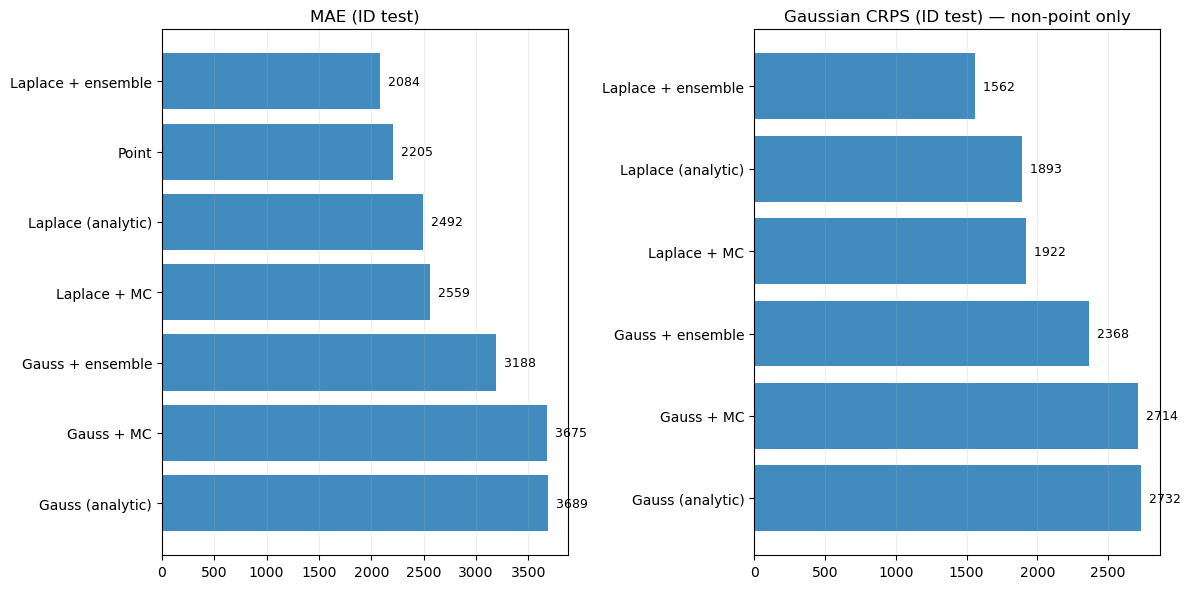

In [82]:
# Visualize core ID-test metrics from df_core_metrics.
# Note: point baseline is included for MAE; probabilistic metric shown is CRPS.

import numpy as np
import matplotlib.pyplot as plt

dfm = df_core_metrics.copy()

# Consistent ordering (best-to-worst by MAE)
method_order = dfm.sort_values("MAE")["method"].tolist()

def _barh(ax, df, metric, title):
    sub = df.set_index("method").reindex(method_order).reset_index()
    sub = sub[np.isfinite(sub[metric].to_numpy(float))]
    if sub.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    y = np.arange(len(sub))
    vals = sub[metric].to_numpy(float)

    ax.barh(y, vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["method"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

    # annotate values
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.4g}", va="center", ha="left", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

# Accuracy metric (include point)
_barh(axes[0], dfm, "MAE", "MAE (ID test)")

# Probabilistic metric (exclude point implicitly via NaNs)
df_prob = dfm[dfm["head_type"] != "point"].copy()
_barh(axes[1], df_prob, "CRPS", "Gaussian CRPS (ID test) — non-point only")

plt.tight_layout()
plt.show()


In [83]:
# Compute core ID-test metrics (file-first).
# Produces a small summary table; does NOT build a giant df.
from scripts.uq_eval import gaussian_nll
from scipy.stats import norm
def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def calibrated_sigmas(
    *,
    head_type: str,
    ale_src: str,
    epi_src: str,
    sigma_ale_raw: np.ndarray,
    sigma_epi_raw: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # If NF doesn't have its own alpha (no val flow files), fall back to analytic alpha.
    def _alpha_lookup(ht: str, asrc: str) -> float:
        if (ht, asrc) in alpha:
            return float(alpha[(ht, asrc)])
        if asrc == "nf" and (ht, "analytic") in alpha:
            return float(alpha[(ht, "analytic")])
        return 1.0
    a = _alpha_lookup(head_type, ale_src)
    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    s_a2 = a * (np.asarray(sigma_ale_raw, float) ** 2)
    s_e2 = b * (np.asarray(sigma_epi_raw, float) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["lpl"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["lpl"], split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["gau"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["gau"], split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(RUN_DIRS["esm_lpl"], split="test")
        return load_id_ensemble(RUN_DIRS["esm_gau"], split="test")
    raise ValueError(f"Unhandled core spec: {spec}")
rows = []
for spec in METHODS_CORE:
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Calibrated sigmas (point has NaNs -> treat as 0)
    if spec.head_type == "point":
        sigma_total = np.full_like(mu, np.nan, dtype=float)
        mae = float(np.mean(np.abs(y - mu)))
        rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
        rows.append({"method": spec.label, "n": int(len(df)), "MAE": mae, "RMSE": rmse, "NLL": np.nan, "CRPS": np.nan, "mean_sigma_total": np.nan})
        continue
    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)
    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "mean_sigma_total": float(np.nanmean(s_t)) if np.any(np.isfinite(s_t)) else float("nan"),
        }
    )
df_core_metrics = pd.DataFrame(rows)
display(df_core_metrics)


,method,n,MAE,RMSE,NLL,CRPS,mean_sigma_total,head_type,aleatoric_source,epistemic_source
0,Point,25358,2205.017043,4399.471557,NaN,NaN,NaN,NaN,NaN,NaN
1,Laplace (analytic),25358,2492.417219,4835.148348,10.169707,1893.467519,2237.650746,laplace,analytic,none
2,Laplace + MC,25358,2559.358448,4831.539729,9.450472,1921.777235,3243.623590,laplace,analytic,mc
3,Laplace + ensemble,25358,2084.424459,4140.386515,9.248042,1561.654433,2273.604465,laplace,analytic,ensemble
4,Gauss (analytic),25358,3689.349464,6658.201062,9.917997,2731.616667,5028.585381,gauss,analytic,none
5,Gauss + MC,25358,3674.631045,6549.058712,9.865507,2714.313451,5223.644185,gauss,analytic,mc
6,Gauss + ensemble,25358,3187.595718,6033.839589,9.536912,2367.854851,4515.523110,gauss,analytic,ensemble


,method,cov_raw_10,cov_raw_20,cov_raw_30,cov_raw_40,cov_raw_50,cov_raw_60,cov_raw_70,cov_raw_80,cov_raw_90,cov_10,cov_20,cov_30,cov_40,cov_50,cov_60,cov_70,cov_80,cov_90,ece
0,Laplace (analytic),0.192286,0.369627,0.522715,0.637629,0.731485,0.808266,0.865605,0.914386,0.953033,0.096222,0.191853,0.285275,0.378263,0.465770,0.552173,0.628914,0.709165,0.796869,4.394405
1,Laplace + MC,0.211215,0.396680,0.556274,0.685661,0.777270,0.846557,0.896364,0.937298,0.966046,0.141415,0.270605,0.395260,0.504496,0.610261,0.696545,0.770487,0.838236,0.895694,7.017904
2,Laplace + ensemble,0.247456,0.455517,0.605095,0.717564,0.803770,0.869272,0.917501,0.951061,0.976063,0.124616,0.242566,0.353813,0.456345,0.543813,0.625207,0.701159,0.774312,0.852433,3.564161
3,Gauss (analytic),0.186292,0.368089,0.531312,0.662828,0.770132,0.849752,0.907012,0.946486,0.974367,0.123708,0.248442,0.370613,0.487854,0.594487,0.688580,0.777033,0.852709,0.917225,6.229461
4,Gauss + MC,0.206365,0.400860,0.583879,0.722336,0.819347,0.886150,0.931501,0.961472,0.981189,0.129545,0.254673,0.377869,0.502208,0.618503,0.717919,0.801877,0.869627,0.928543,7.786278
5,Gauss + ensemble,0.213818,0.411507,0.578871,0.709007,0.802508,0.874754,0.923338,0.957055,0.980637,0.137471,0.271157,0.402792,0.521374,0.628401,0.720009,0.797421,0.866630,0.926611,8.576299


,method,ece
0,Laplace (analytic),4.394405
1,Laplace + MC,7.017904
2,Laplace + ensemble,3.564161
3,Gauss (analytic),6.229461
4,Gauss + MC,7.786278
5,Gauss + ensemble,8.576299


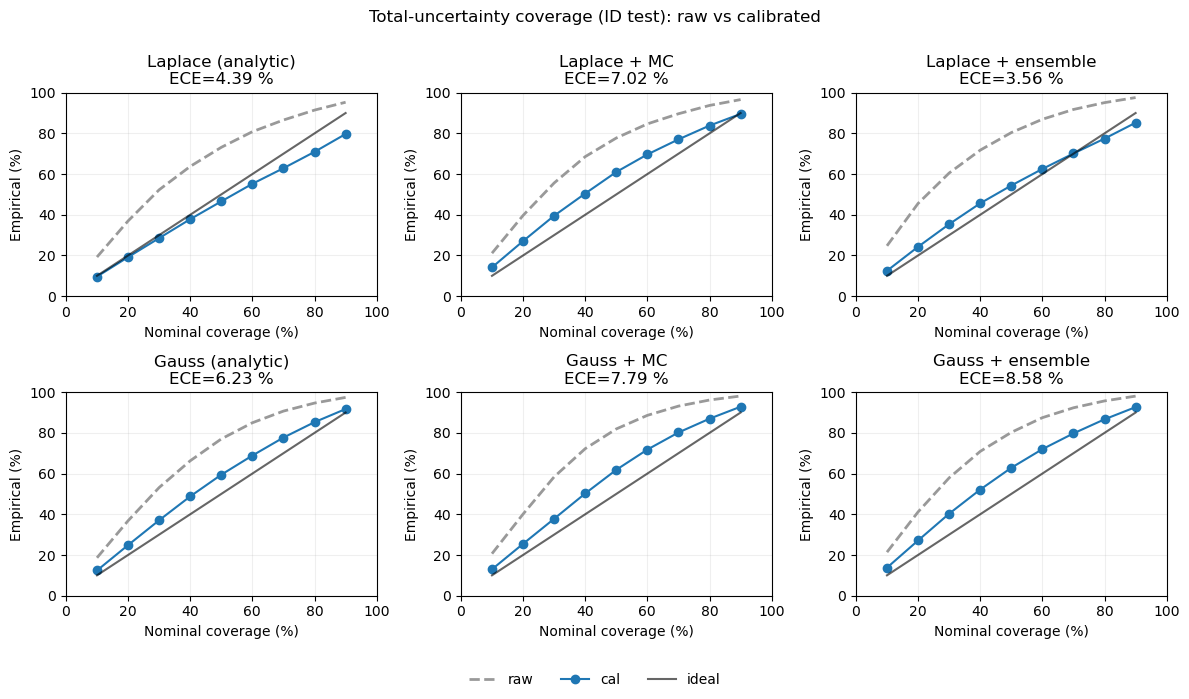

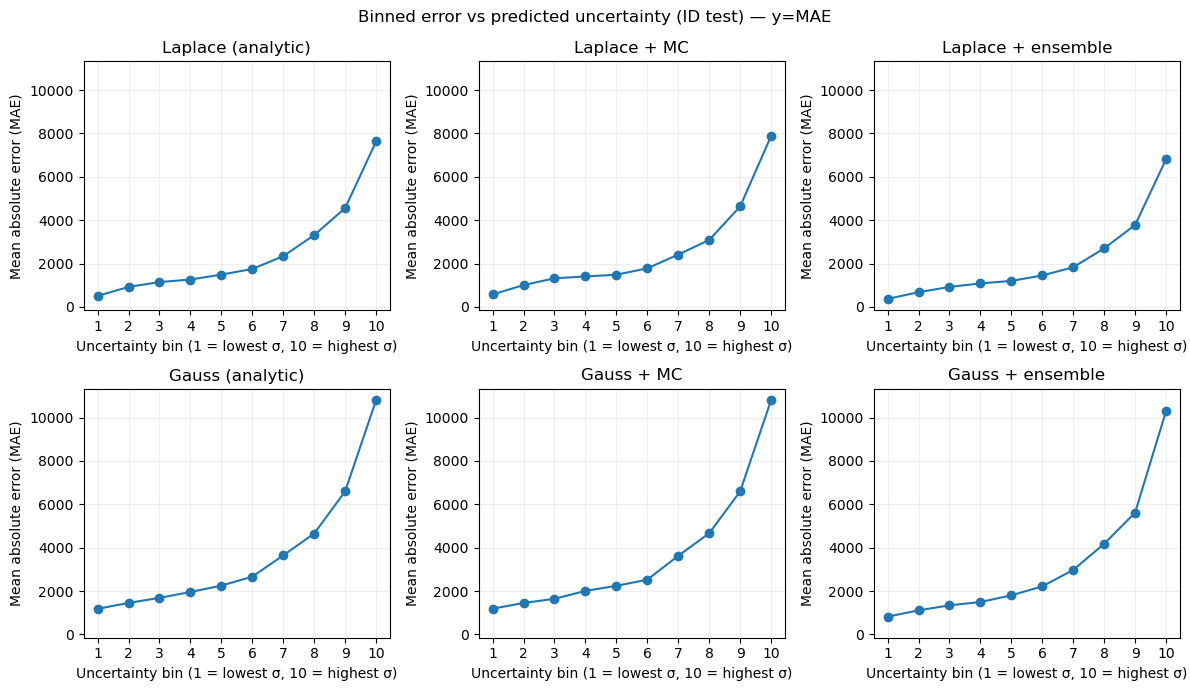

In [84]:
# Calibration diagnostics on ID test (core methods).
# - Coverage at 10–90% (step 10) + ECE (mean abs coverage error over 10–90, in percentage points)
# - Also plots "before calibration" (raw sigmas) as a grey dashed line.
# - Replaces the variance-vs-error² scatter with an intuitive binned plot:
#     bin by predicted uncertainty (σ_total), then plot mean MAE or mean CRPS per bin (toggle).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
# Toggle for the binned plot y-axis:
BIN_METRIC = "mae"  # "mae" or "crps"
nominal_levels_plot = np.arange(10, 100, 10)  # 10..90
z_for_level = {lvl: float(norm.ppf((1 + (lvl / 100.0)) / 2.0)) for lvl in nominal_levels_plot}
def compute_coverage_points(y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, levels, z_map):
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    err = np.abs(y - mu)
    out = {}
    mask_base = np.isfinite(err) & np.isfinite(sigma_total) & (sigma_total > 0)
    for lvl in levels:
        z = z_map[lvl]
        out[lvl] = float(np.mean(err[mask_base] <= z * sigma_total[mask_base])) if np.any(mask_base) else float("nan")
    return out
def gaussian_crps_per_row(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    out = np.full_like(y, np.nan, dtype=float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return out
    yy = y[mask]
    mm = mu[mask]
    ss = np.clip(sigma[mask], 1e-8, None)
    z = (yy - mm) / ss
    crps = ss * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    out[mask] = crps
    return out
def compute_bins_and_means(
    y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, *, n_bins: int
) -> pd.DataFrame:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    abs_err = np.abs(y - mu)
    crps = gaussian_crps_per_row(y, mu, sigma_total)
    mask = np.isfinite(sigma_total) & (sigma_total > 0) & np.isfinite(abs_err)
    if not np.any(mask):
        return pd.DataFrame(columns=["bin", "bin_sigma_mean", "bin_mae_mean", "bin_crps_mean", "n"])
    s = sigma_total[mask]
    ae = abs_err[mask]
    cr = crps[mask]
    # Equal-count bins by predicted σ (more intuitive than variance)
    bins = pd.qcut(s, n_bins, labels=False, duplicates="drop")
    df = pd.DataFrame({"bin": bins.astype(int) + 1, "sigma": s, "abs_err": ae, "crps": cr})
    out = (
        df.groupby("bin")
        .agg(
            bin_sigma_mean=("sigma", "mean"),
            bin_mae_mean=("abs_err", "mean"),
            bin_crps_mean=("crps", "mean"),
            n=("abs_err", "size"),
        )
        .reset_index()
        .sort_values("bin")
        .reset_index(drop=True)
    )
    return out
coverage_rows = []
ece_rows = []
bins_rows = []
for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Raw total sigma (no alpha/beta)
    s_raw = np.sqrt(
        np.maximum(
            np.nan_to_num(sigma_ale_raw, nan=0.0) ** 2 + np.nan_to_num(sigma_epi_raw, nan=0.0) ** 2,
            0.0,
        )
    )
    # Calibrated total sigma
    _, _, s_cal = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    cov_raw = compute_coverage_points(y, mu, s_raw, nominal_levels_plot, z_for_level)
    cov_cal = compute_coverage_points(y, mu, s_cal, nominal_levels_plot, z_for_level)
    # ECE over 10–90 as mean abs coverage error in percentage points
    diffs = [abs(cov_cal[lvl] - (lvl / 100.0)) for lvl in nominal_levels_plot]
    diffs = [d for d in diffs if np.isfinite(d)]
    ece_pp = float(100.0 * np.mean(diffs)) if diffs else float("nan")
    coverage_rows.append(
        {
            "method": spec.label,
            **{f"cov_raw_{lvl}": cov_raw[lvl] for lvl in nominal_levels_plot},
            **{f"cov_{lvl}": cov_cal[lvl] for lvl in nominal_levels_plot},
            "ece": ece_pp,  # percent points
        }
    )
    ece_rows.append({"method": spec.label, "ece": ece_pp})
    # Bins for the option-2 plot (bin by calibrated σ_total)
    bdf = compute_bins_and_means(y, mu, s_cal, n_bins=N_RELIABILITY_BINS)
    bdf["method"] = spec.label
    bins_rows.append(bdf)
df_core_coverage = pd.DataFrame(coverage_rows)
df_cal_error = pd.DataFrame(ece_rows)
bins_rows = [b for b in bins_rows if not b.empty]
df_bins = pd.concat(bins_rows, ignore_index=True) if bins_rows else pd.DataFrame()
display(df_core_coverage)
display(df_cal_error)

# --- Coverage subplots (10-90%), with ECE in title and raw-vs-cal curves ---
methods_order = [m for m in df_core_coverage["method"] if "point" not in m.lower()]
n_methods = len(methods_order)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()
for ax, method in zip(axes, methods_order):
    row = df_core_coverage[df_core_coverage["method"] == method].iloc[0]
    ece_pp = float(row["ece"])
    cov_cal = [row[f"cov_{lvl}"] * 100 for lvl in nominal_levels_plot]
    cov_raw = [row[f"cov_raw_{lvl}"] * 100 for lvl in nominal_levels_plot]
    ax.plot(nominal_levels_plot, cov_raw, "--", color="0.6", linewidth=2.0, label="raw")
    ax.plot(nominal_levels_plot, cov_cal, "-o", color="tab:blue", label="cal")
    ax.plot(nominal_levels_plot, nominal_levels_plot, "k-", alpha=0.6, label="ideal")
    ax.set_title(f"{method}\nECE={ece_pp:.2f} %")
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)
for ax in axes[len(methods_order):]:
    ax.set_axis_off()


handles, labels = axes[0].get_legend_handles_labels()

fig.suptitle("Total-uncertainty coverage (ID test): raw vs calibrated")

# Legend at the bottom
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)

# Leave a small bottom margin for the legend
fig.tight_layout(rect=[0, 0.06, 1, 0.98])

plt.show()

# --- Option 2 (requested): binned mean error vs uncertainty bin (toggle MAE/CRPS) ---
metric_key = str(BIN_METRIC).strip().lower()
if metric_key not in {"mae", "crps"}:
    raise ValueError(f"BIN_METRIC must be 'mae' or 'crps', got {BIN_METRIC!r}")
y_col = "bin_mae_mean" if metric_key == "mae" else "bin_crps_mean"
y_label = "Mean absolute error (MAE)" if metric_key == "mae" else "Mean Gaussian CRPS"
y_vals = df_bins[y_col].to_numpy(float)
y_vals = y_vals[np.isfinite(y_vals)]
y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))
pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
y_lim = (y_min - pad, y_max + pad)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()
for ax, method in zip(axes, methods_order):
    sub = df_bins[df_bins["method"] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    ax.plot(sub["bin"], sub[y_col], "-o", color="tab:blue")
    ax.set_ylim(*y_lim)
    ax.set_title(method)
    ax.set_xlabel("Uncertainty bin (1 = lowest σ, 10 = highest σ)")
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(1, N_RELIABILITY_BINS + 1))
    ax.grid(True, alpha=0.2)
for ax in axes[len(methods_order):]:
    ax.set_axis_off()
fig.suptitle(f"Binned error vs predicted uncertainty (ID test) — y={metric_key.upper()}", y=0.98)
fig.tight_layout()
plt.show()


## Import OOD

,ood_label,method,head_type,aleatoric_source,epistemic_source,n,MAE,CRPS
0,knn_hard,Laplace + ensemble,laplace,analytic,ensemble,1585,5207.929849,4103.056487
1,knn_hard,Point,point,none,none,1585,5349.239090,NaN
2,knn_hard,Laplace (analytic),laplace,analytic,none,1585,5368.672024,4218.714643
3,knn_hard,Laplace + MC,laplace,analytic,mc,1585,5494.136890,4203.128493
4,knn_hard,Gauss + ensemble,gauss,analytic,ensemble,1585,5839.654201,4406.610436
5,knn_hard,Gauss (analytic),gauss,analytic,none,1585,6271.379314,4690.164343
6,knn_hard,Gauss + MC,gauss,analytic,mc,1585,6375.190670,4737.017384


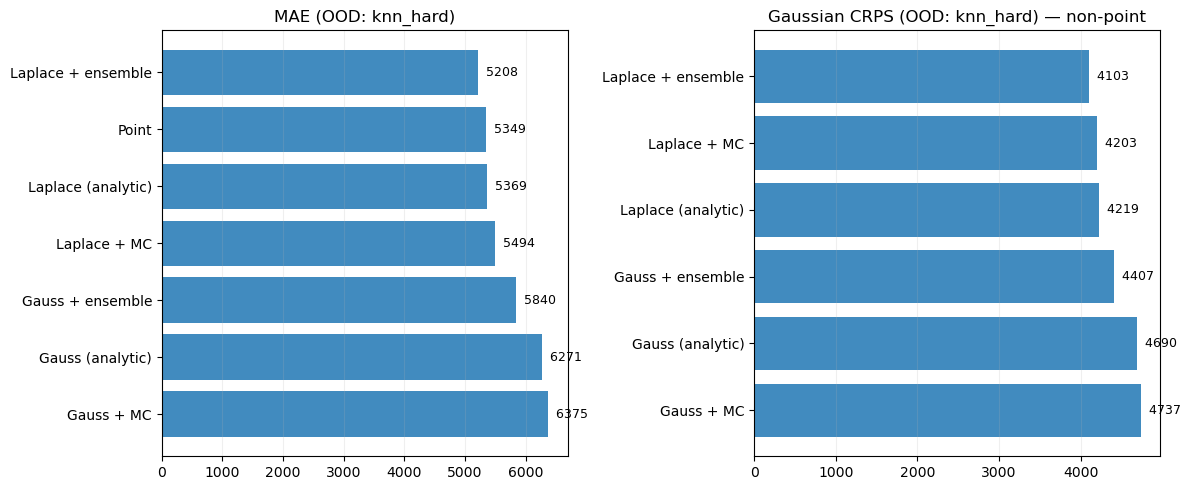

In [85]:

# --- OOD: file-first loading (memory efficient) ---
# Loads ONE (method, OOD split) CSV at a time and immediately reduces it to a small summary table.
# Also exposes `method_ood_frame(...)` for on-demand loading later (no global concat).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Toggle calibrated vs raw sigmas for CRPS
USE_CALIBRATED_SIGMAS = True


def load_ood_ensemble(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    candidates = [
        run_dir / f"ensemble_preds_ood_{label}.csv",
        run_dir / f"ensemble_ood_{label}.csv",
        run_dir / f"ood_{label}_test.csv",
    ]
    path = next((p for p in candidates if p.exists()), candidates[0])
    if not path.exists():
        raise FileNotFoundError(f"Ensemble OOD file not found for {label} under {run_dir}")

    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )

    # Standardize prediction -> mu
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    else:
        df["mu"] = np.nan

    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    else:
        df["sigma_ale_raw"] = np.nan

    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    else:
        df["sigma_epi_raw"] = np.nan

    return df


def method_ood_frame(spec: MethodSpec, label: str) -> pd.DataFrame:
    # Map MethodSpec -> (run_dir, loader, variant)
    if spec.key == "point":
        run_dir = RUN_DIRS.get("point")
        if run_dir is None:
            raise FileNotFoundError("No point eval dir found")
        return load_ood_regression(run_dir, label, variant=None)

    if spec.key.startswith("lpl_"):
        run_dir = RUN_DIRS.get("lpl")
        if run_dir is None:
            raise FileNotFoundError("No lpl eval dir found")
        variant = "mc" if spec.epistemic_source == "mc" else None
        return load_ood_regression(run_dir, label, variant=variant)

    if spec.key.startswith("gau_"):
        run_dir = RUN_DIRS.get("gau")
        if run_dir is None:
            raise FileNotFoundError("No gau eval dir found")
        variant = "mc" if spec.epistemic_source == "mc" else None
        return load_ood_regression(run_dir, label, variant=variant)

    if spec.epistemic_source == "ensemble":
        ens_dir = RUN_DIRS.get("esm_lpl") if spec.head_type == "laplace" else RUN_DIRS.get("esm_gau")
        if ens_dir is None:
            raise FileNotFoundError("No ensemble eval dir found")
        return load_ood_ensemble(ens_dir, label)

    raise ValueError(f"Unhandled OOD spec: {spec}")


# Build SMALL tables (one row per method×OOD split)
ood_rows = []
quality_rows = []

for ood_label in OOD_LABELS:
    for spec in METHODS_CORE:
        try:
            df = method_ood_frame(spec, ood_label)
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"[skip] {spec.key} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        y = df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float)
        mu = df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)
        n = int(len(df))

        row = {
            "ood_label": ood_label,
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": n,
            "mae": float(np.nanmean(np.abs(y - mu))) if n else float("nan"),
            "rmse": float(np.sqrt(np.nanmean((y - mu) ** 2))) if n else float("nan"),
        }

        qrow = {
            "ood_label": ood_label,
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": n,
            "MAE": float(np.nanmean(np.abs(y - mu))) if n else float("nan"),
            "CRPS": float("nan"),
        }

        if spec.head_type != "point":
            sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
            sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

            if USE_CALIBRATED_SIGMAS:
                s_a, s_e, s_t = calibrated_sigmas(
                    head_type=spec.head_type,
                    ale_src=spec.aleatoric_source,
                    epi_src=spec.epistemic_source,
                    sigma_ale_raw=sigma_ale_raw,
                    sigma_epi_raw=sigma_epi_raw,
                )
            else:
                s_a = np.asarray(sigma_ale_raw, float)
                s_e = np.asarray(sigma_epi_raw, float)
                s_t = np.sqrt(
                    np.maximum(
                        np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2,
                        0.0,
                    )
                )

            row.update(
                {
                    "mean_Ua": float(np.nanmean(s_a)),
                    "mean_Ue": float(np.nanmean(s_e)),
                    "mean_Utot": float(np.nanmean(s_t)),
                }
            )

            qrow["CRPS"] = gaussian_crps_mean(y, mu, s_t)

        ood_rows.append(row)
        quality_rows.append(qrow)
        del df


df_ood_index = (
    pd.DataFrame(ood_rows)
    .sort_values(["ood_label", "mae"], ascending=[True, True])
    .reset_index(drop=True)
)
# display(df_ood_index)


df_ood_quality = (
    pd.DataFrame(quality_rows)
    .sort_values(["ood_label", "MAE"], ascending=[True, True])
    .reset_index(drop=True)
)
display(df_ood_quality)


def _barh(ax, df, metric, title):
    sub = df[np.isfinite(df[metric].to_numpy(float))].copy()
    if sub.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    sub = sub.sort_values(metric, ascending=True)
    y = np.arange(len(sub))
    vals = sub[metric].to_numpy(float)

    ax.barh(y, vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["method"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.4g}", va="center", ha="left", fontsize=9)


for ood_label in OOD_LABELS:
    sub = df_ood_quality[df_ood_quality["ood_label"] == ood_label].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    _barh(axes[0], sub, "MAE", f"MAE (OOD: {ood_label})")

    sub_non_point = sub[sub["head_type"] != "point"].copy()
    _barh(axes[1], sub_non_point, "CRPS", f"Gaussian CRPS (OOD: {ood_label}) — non-point")

    plt.tight_layout()
    plt.show()


,dataset,method,spec_key,head_type,aleatoric_source,epistemic_source,n,Ua_mean,Ua_median,Ua_q10,Ua_q90,Ue_mean,Ue_median,Ue_q10,Ue_q90,Utot_mean,Utot_median,Utot_q10,Utot_q90
0,id,Gauss + MC,gau_mc,gauss,analytic,mc,25358,5028.585896,3355.585133,1831.402904,10142.496908,1305.637034,946.213060,597.818843,2429.316538,5223.644185,3531.473376,1963.549748,10455.232508
1,ood:knn_hard,Gauss + MC,gau_mc,gauss,analytic,mc,1585,8326.082305,5644.056528,2616.017083,18257.205415,1517.007936,996.093574,642.581827,3172.245564,8480.359347,5768.712525,2714.084378,18501.671630
2,id,Gauss + ensemble,esm_gau,gauss,analytic,ensemble,25358,4515.523107,2882.861070,1672.453178,9384.779949,0.150568,0.107700,0.059545,0.278329,4515.523110,2882.861074,1672.453181,9384.779952
3,ood:knn_hard,Gauss + ensemble,esm_gau,gauss,analytic,ensemble,1585,6644.937993,4018.821377,2030.828521,15171.496273,0.200293,0.125728,0.061540,0.407059,6644.937997,4018.821377,2030.828523,15171.496277
4,id,Laplace + MC,lpl_mc,laplace,analytic,mc,25358,2237.650476,1433.424257,838.132218,4198.695294,2275.085787,1652.613362,1091.800478,4101.506425,3243.623590,2210.535270,1403.307123,6004.360073
5,ood:knn_hard,Laplace + MC,lpl_mc,laplace,analytic,mc,1585,3888.478141,2192.853668,1275.733896,8572.364060,3326.952031,1938.983317,1414.899647,6010.300221,5350.768213,2965.782894,1984.237057,10833.134902
6,id,Laplace + ensemble,esm_lpl,laplace,analytic,ensemble,25358,2273.604463,1415.503972,853.720432,4312.244637,0.089856,0.056399,0.028706,0.170495,2273.604465,1415.503974,853.720433,4312.244638
7,ood:knn_hard,Laplace + ensemble,esm_lpl,laplace,analytic,ensemble,1585,3350.268544,1857.624873,1175.446864,7040.185666,0.140735,0.080580,0.036291,0.266725,3350.268547,1857.624874,1175.446864,7040.185670


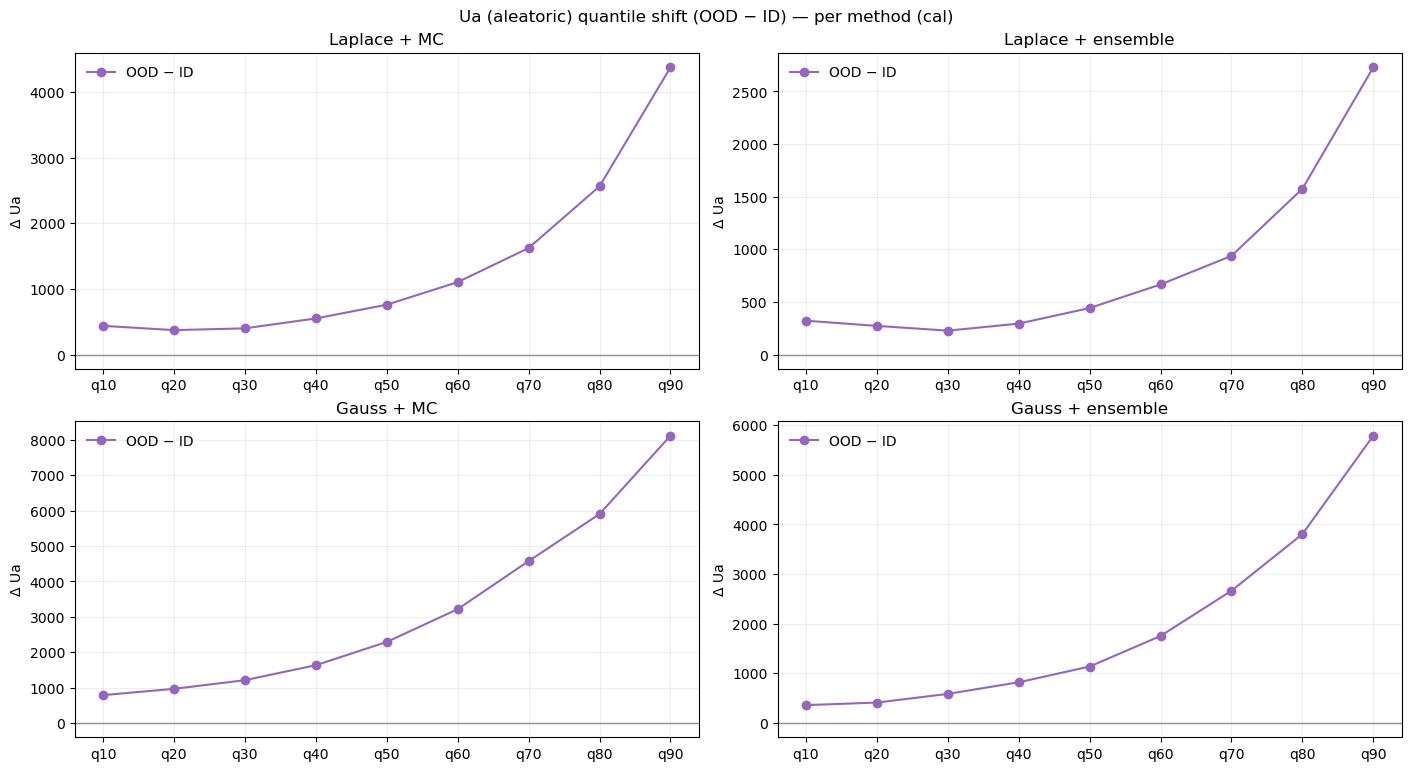

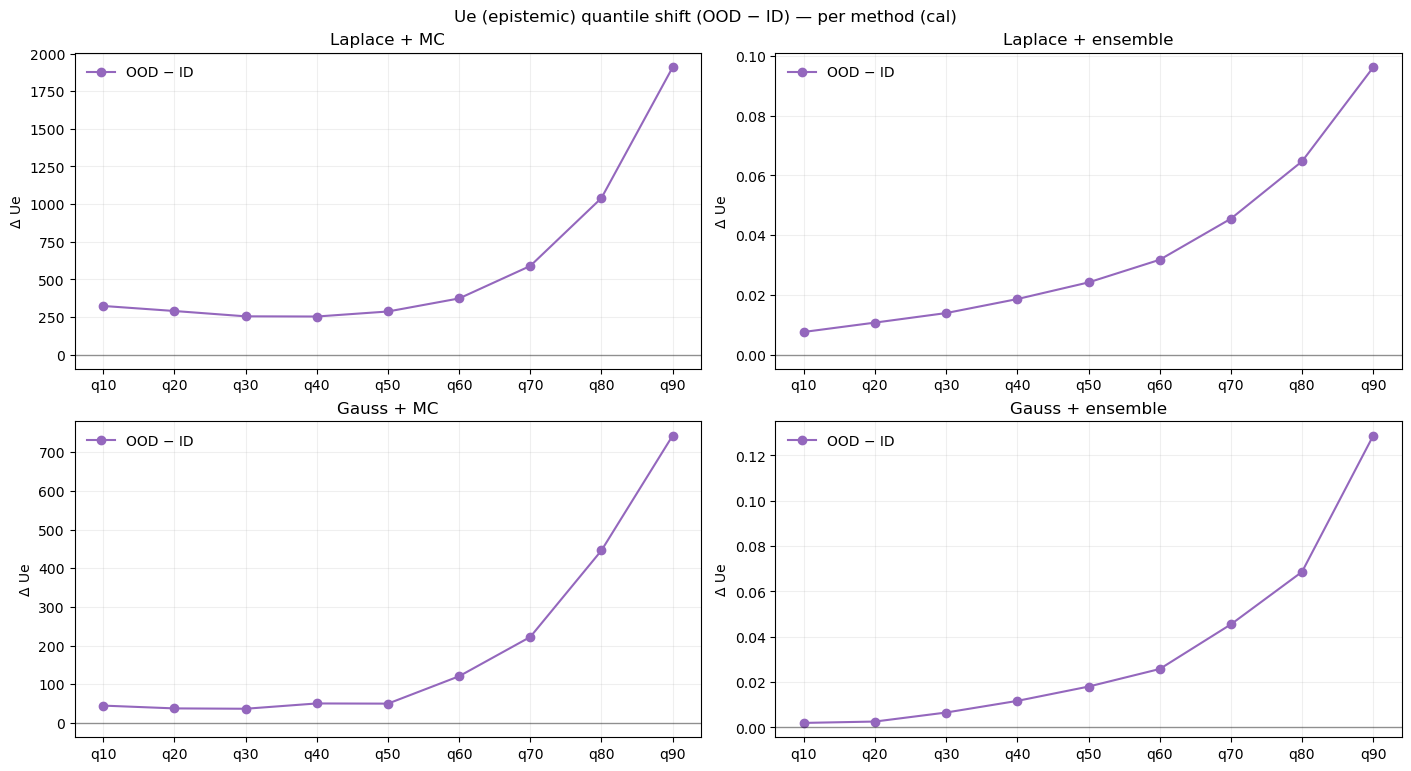

In [86]:
# --- Cell A: ID→OOD shift in Ua vs Ue (file-first, memory efficient) ---
# UPDATED: quantile markers are computed PER METHOD (no concatenation).
# Now plots Δ = OOD − ID instead of absolute values.
# Note: we avoid fillna(0) for sigma_epi_raw so missing epistemic doesn't create artificial zeros.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INCLUDE_ALEATORIC_ONLY_BASELINES = False  # set True to include analytic-only methods (Ua only)
USE_CALIBRATED_SIGMAS = True  # True = alpha/beta calibrated; False = raw sigmas
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def _has_epistemic(spec: MethodSpec) -> bool:
    return str(spec.epistemic_source).lower() in {"mc", "ensemble", "dido"}

def _summary(x: np.ndarray) -> dict:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"mean": np.nan, "median": np.nan, "q10": np.nan, "q90": np.nan}
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "q10": float(np.quantile(x, 0.10)),
        "q90": float(np.quantile(x, 0.90)),
    }

def _sigmas_for(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    # IMPORTANT: keep NaNs; do NOT fill with 0.0 for epistemic here
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)

    if USE_CALIBRATED_SIGMAS:
        # calibrated_sigmas expects arrays; use 0.0 for Utot when epi missing but keep Ue NaN
        sE0 = np.nan_to_num(sE_raw, nan=0.0)
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE0,
        )
        sA = np.asarray(sA, float)
        sE = np.asarray(sE, float)
        sT = np.asarray(sT, float)
        sE[~np.isfinite(sE_raw)] = np.nan  # preserve missing epi for Ue stats/quantiles
        return sA, sE, sT

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _quantile_row(vals: np.ndarray, qs: list[float]) -> dict:
    vals = np.asarray(vals, float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {f"q{int(q*100)}": np.nan for q in qs}
    return {f"q{int(q*100)}": float(np.quantile(vals, q)) for q in qs}

# ---- Choose methods ----
methods_shift = []
methods_ale_only = []
for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    if _has_epistemic(spec):
        methods_shift.append(spec)
    else:
        methods_ale_only.append(spec)

methods_used = methods_shift + methods_ale_only if INCLUDE_ALEATORIC_ONLY_BASELINES else methods_shift

# ---- Table: summaries per method × dataset ----
rows = []
datasets = [("id", None)] + [(f"ood:{lbl}", lbl) for lbl in OOD_LABELS]

for spec in methods_used:
    for dataset_name, ood_label in datasets:
        try:
            df = method_id_test_frame(spec) if dataset_name == "id" else method_ood_frame(spec, ood_label)
        except Exception as e:
            print(f"[skip] {spec.key} / {dataset_name}: {type(e).__name__}: {e}")
            continue

        sA, sE, sT = _sigmas_for(spec, df)
        sa, se, st = _summary(sA), _summary(sE), _summary(sT)

        rows.append(
            {
                "dataset": dataset_name,
                "method": spec.label,
                "spec_key": spec.key,
                "head_type": spec.head_type,
                "aleatoric_source": spec.aleatoric_source,
                "epistemic_source": spec.epistemic_source,
                "n": int(len(df)),
                "Ua_mean": sa["mean"], "Ua_median": sa["median"], "Ua_q10": sa["q10"], "Ua_q90": sa["q90"],
                "Ue_mean": se["mean"], "Ue_median": se["median"], "Ue_q10": se["q10"], "Ue_q90": se["q90"],
                "Utot_mean": st["mean"], "Utot_median": st["median"], "Utot_q10": st["q10"], "Utot_q90": st["q90"],
            }
        )
        del df

df_shift = pd.DataFrame(rows)
if df_shift.empty:
    raise RuntimeError("No OOD/ID rows loaded; check RUN_DIRS and eval filenames.")
display(df_shift.sort_values(["method", "dataset"]).reset_index(drop=True))

# ---- Plots: Δ quantiles per method (OOD − ID) ----
plot_specs = [("Ua", "Ua (aleatoric)"), ("Ue", "Ue (epistemic)")]
n_methods = len(methods_used)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

for sig_key, sig_title in plot_specs:
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(7.0 * ncols, 3.8 * nrows), sharex=False, sharey=False, constrained_layout=True
    )
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, spec in zip(axes, methods_used):
        # ID
        try:
            df_id = method_id_test_frame(spec)
            sA_id, sE_id, _ = _sigmas_for(spec, df_id)
        except Exception as e:
            ax.set_axis_off()
            ax.set_title(f"{spec.label}\n(skip ID: {type(e).__name__})")
            continue

        # OOD (aggregate across all OOD labels for this method)
        sA_ood_list, sE_ood_list = [], []
        for ood_label in OOD_LABELS:
            try:
                df_o = method_ood_frame(spec, ood_label)
                sA_o, sE_o, _ = _sigmas_for(spec, df_o)
                sA_ood_list.append(sA_o)
                sE_ood_list.append(sE_o)
            except Exception:
                continue

        if sA_ood_list:
            sA_ood = np.concatenate(sA_ood_list)
            sE_ood = np.concatenate(sE_ood_list)
        else:
            sA_ood = np.array([])
            sE_ood = np.array([])

        id_vals = sA_id if sig_key == "Ua" else sE_id
        ood_vals = sA_ood if sig_key == "Ua" else sE_ood

        q_id = _quantile_row(id_vals, QUANTILES)
        q_ood = _quantile_row(ood_vals, QUANTILES)

        delta = [
            (q_ood[f"q{int(q*100)}"] - q_id[f"q{int(q*100)}"])
            for q in QUANTILES
        ]

        x = np.arange(len(QUANTILES))
        ax.plot(x, delta, "o-", label="OOD − ID", color="tab:purple")
        ax.axhline(0.0, color="k", lw=1, alpha=0.4)
        ax.set_xticks(x)
        ax.set_xticklabels([f"q{int(q*100)}" for q in QUANTILES])
        ax.set_title(spec.label)
        ax.set_ylabel(f"Δ {sig_key}")
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)

    for ax in axes[n_methods:]:
        ax.set_axis_off()

    fig.suptitle(f"{sig_title} quantile shift (OOD − ID) — per method ({'cal' if USE_CALIBRATED_SIGMAS else 'raw'})")
    plt.show()


In [87]:
# Debug why Laplace+MC / Gauss+MC have no OOD Ue line
import numpy as np
import pandas as pd

targets = [s for s in METHODS_CORE if s.key in {"lpl_mc", "gau_mc"}]

for spec in targets:
    print("\n===", spec.label, "===")
    try:
        df_id = method_id_test_frame(spec)
        print("ID cols:", [c for c in ["mc_flag","n_mc","sigma_epi_raw","sigma_epi_orig"] if c in df_id.columns])
        for c in ["sigma_epi_raw","sigma_epi_orig"]:
            if c in df_id.columns:
                arr = pd.to_numeric(df_id[c], errors="coerce").to_numpy(float)
                print(f"  ID {c}: finite_frac={np.isfinite(arr).mean():.3f}, median={np.nanmedian(arr):.3g}")
    except Exception as e:
        print("  [ID load failed]", type(e).__name__, e)

    for ood_label in OOD_LABELS:
        try:
            df_o = method_ood_frame(spec, ood_label)
        except Exception as e:
            print(f"  [OOD load failed] {ood_label}:", type(e).__name__, e)
            continue

        print(f"  OOD={ood_label} cols:", [c for c in ["mc_flag","n_mc","sigma_epi_raw","sigma_epi_orig"] if c in df_o.columns])
        for c in ["sigma_epi_raw","sigma_epi_orig"]:
            if c in df_o.columns:
                arr = pd.to_numeric(df_o[c], errors="coerce").to_numpy(float)
                print(f"    OOD {c}: finite_frac={np.isfinite(arr).mean():.3f}, median={np.nanmedian(arr):.3g}")



=== Laplace + MC ===
ID cols: ['sigma_epi_raw']
  ID sigma_epi_raw: finite_frac=1.000, median=1.69e+03
  OOD=knn_hard cols: ['sigma_epi_raw']
    OOD sigma_epi_raw: finite_frac=1.000, median=1.99e+03

=== Gauss + MC ===


ID cols: ['sigma_epi_raw']
  ID sigma_epi_raw: finite_frac=1.000, median=2.38e+03
  OOD=knn_hard cols: ['sigma_epi_raw']
    OOD sigma_epi_raw: finite_frac=1.000, median=2.5e+03


## OOD detection (ID vs OOD, Ua/Ue/Utot)

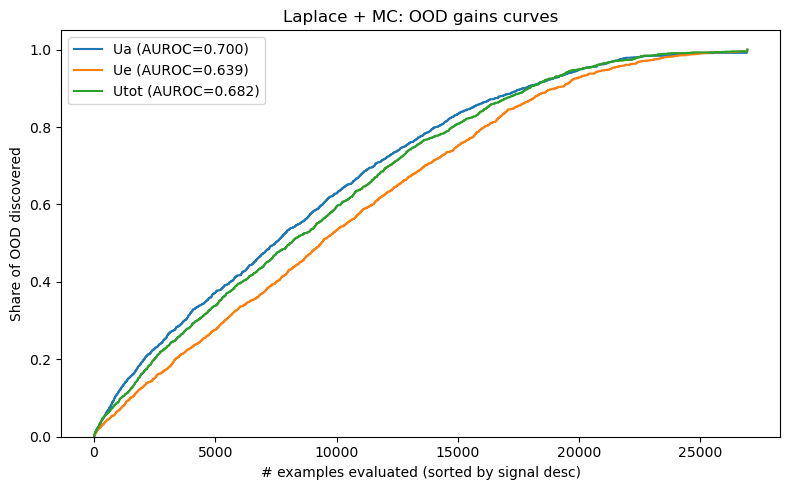

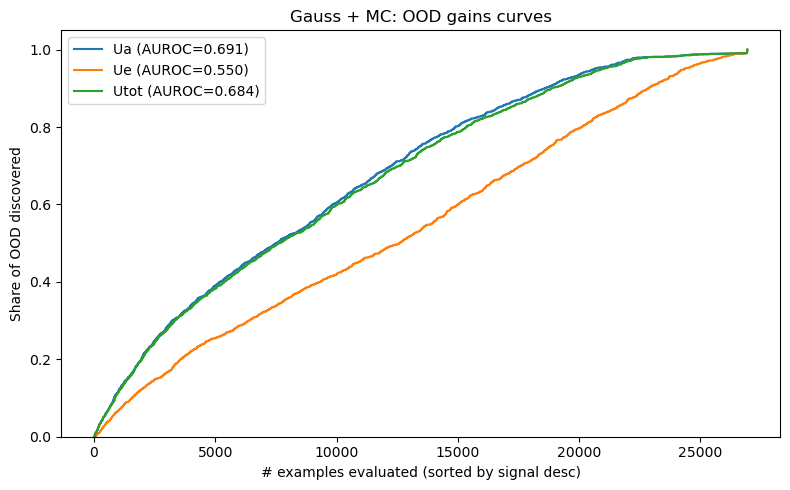

In [88]:
# --- Gains plots for OOD detection: cumulative OOD recall vs # evaluated, with AUROC ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

USE_CALIBRATED_SIGMAS_LOCAL = True  # toggle: True = calibrated, False = raw
OOD_LABEL = "knn_hard"
SPECS = [s for s in METHODS_CORE if s.key in {"gau_mc", "lpl_mc"}]
SIGNALS = ["Ua", "Ue", "Utot"]

def _sigmas_for(spec, df):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

for spec in SPECS:
    df_id = method_id_test_frame(spec).copy()
    df_ood = method_ood_frame(spec, label=OOD_LABEL).copy()
    if df_id.empty or df_ood.empty:
        print(f"[{spec.label}] missing ID or OOD rows; skipping.")
        continue

    df_id["is_ood"] = 0
    df_ood["is_ood"] = 1
    df_all = pd.concat([df_id, df_ood], ignore_index=True)

    sA, sE, sT = _sigmas_for(spec, df_all)
    df_all["Ua"] = sA
    df_all["Ue"] = sE
    df_all["Utot"] = sT

    plt.figure(figsize=(8, 5))
    ood_total = df_all["is_ood"].sum()
    if ood_total == 0:
        print(f"[{spec.label}] no OOD rows after merge; skipping plot.")
        plt.close()
        continue

    for sig in SIGNALS:
        d = df_all[["is_ood", sig]].dropna()
        if d.empty or d["is_ood"].nunique() < 2:
            print(f"[{spec.label}] {sig}: insufficient data for AUROC; skipping.")
            continue

        d = d.sort_values(sig, ascending=False, kind="mergesort")
        cum_ood = d["is_ood"].cumsum()
        share_ood = cum_ood / float(ood_total)
        x = np.arange(1, len(d) + 1)

        auroc = roc_auc_score(d["is_ood"], d[sig])
        plt.plot(x, share_ood, label=f"{sig} (AUROC={auroc:.3f})")

    plt.xlabel("# examples evaluated (sorted by signal desc)")
    plt.ylabel("Share of OOD discovered")
    plt.ylim(0, 1.05)
    plt.title(f"{spec.label}: OOD gains curves")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Large-error detection

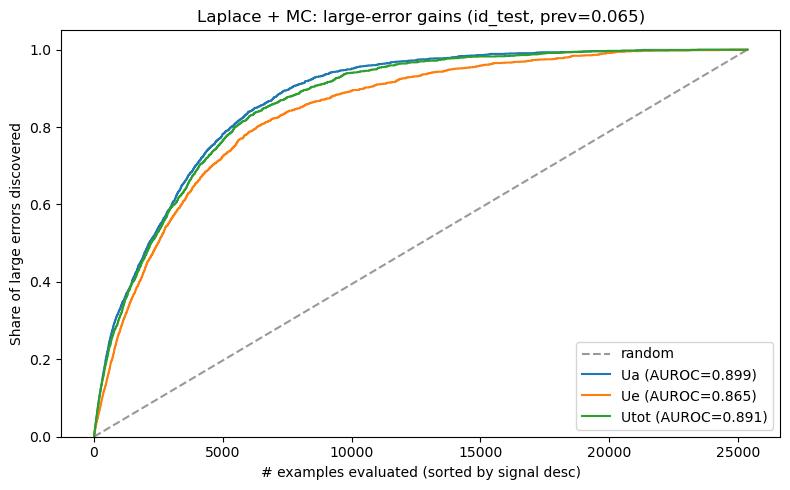

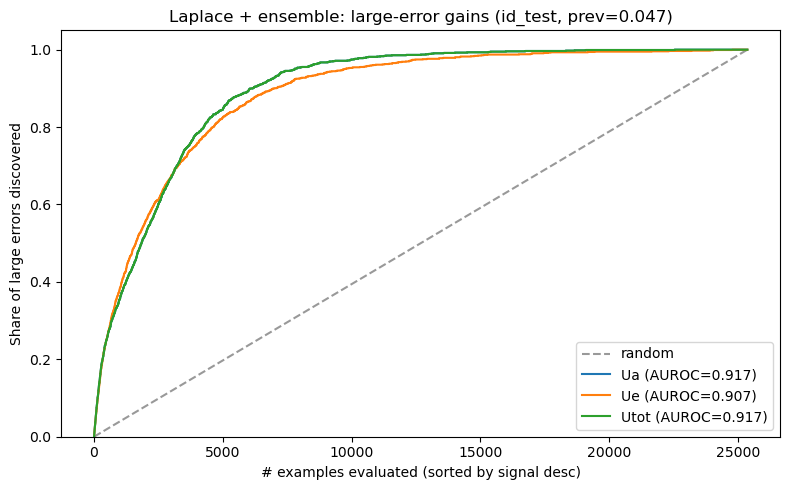

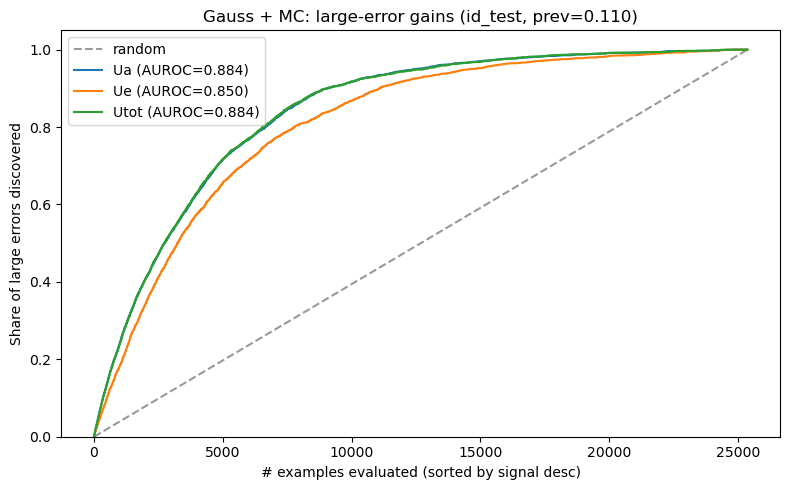

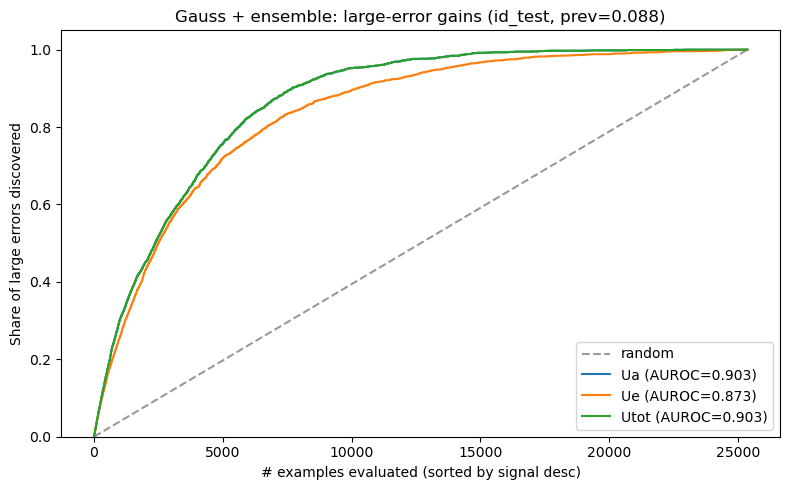

In [89]:
# --- Gains plots for large-error detection: cumulative large-error recall vs # evaluated ---
# Uses LARGE_ERROR_TAU (defined earlier from point baseline on ID test).
# Toggle whether to evaluate on ID test only or ID test + OOD.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

USE_CALIBRATED_SIGMAS_LOCAL = True  # True = calibrated, False = raw
EVAL_SCOPE = "id_test"  # "id_test" | "id_test+ood"
SIGNALS = ["Ua", "Ue", "Utot"]

# Which OOD sets to include when EVAL_SCOPE == "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)

# Methods: include non-point heads, but exclude analytic-only (no epistemic)
SPECS = [
    s for s in METHODS_CORE
    if (s.head_type != "point") and (str(s.epistemic_source).lower() != "none")
]

try:
    _ = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e


def _sigmas_for(spec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT


for spec in SPECS:
    parts = []

    # ID test
    try:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load ID test: {type(e).__name__}: {e}")
        continue

    # OOD
    if EVAL_SCOPE.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")
                continue

    df_all = pd.concat(parts, ignore_index=True)
    if df_all.empty:
        print(f"[{spec.label}] empty eval frame; skipping")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    is_large = (abs_err > float(LARGE_ERROR_TAU))

    total_pos = int(np.nansum(is_large.astype(int)))
    n_all = int(len(df_all))
    if total_pos == 0 or n_all == 0:
        print(f"[{spec.label}] no large-error positives under tau={LARGE_ERROR_TAU:.4g}; skipping")
        continue

    sA, sE, sT = _sigmas_for(spec, df_all)
    df_all["Ua"] = sA
    df_all["Ue"] = sE
    df_all["Utot"] = sT
    df_all["is_large"] = is_large.astype(int)

    plt.figure(figsize=(8, 5))
    prev = total_pos / float(n_all)

    # Random baseline (expected recall ~ fraction evaluated)
    x_base = np.arange(1, n_all + 1)
    plt.plot(x_base, x_base / float(n_all), "k--", alpha=0.4, label="random")

    for sig in SIGNALS:
        d = df_all[["is_large", sig]].dropna()
        if d.empty or d["is_large"].nunique() < 2:
            print(f"[{spec.label}] {sig}: insufficient data; skipping")
            continue

        d = d.sort_values(sig, ascending=False, kind="mergesort")
        cum_pos = d["is_large"].cumsum()
        share_pos = cum_pos / float(total_pos)
        x = np.arange(1, len(d) + 1)

        auroc = roc_auc_score(d["is_large"], d[sig])
        plt.plot(x, share_pos, label=f"{sig} (AUROC={auroc:.3f})")

    plt.xlabel("# examples evaluated (sorted by signal desc)")
    plt.ylabel("Share of large errors discovered")
    plt.ylim(0, 1.05)
    plt.title(f"{spec.label}: large-error gains ({EVAL_SCOPE}, prev={prev:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [90]:
# --- Cohort candidates quick check (ID) ---
# Goal: find 1–2 cohort definitions that (a) have enough samples per cohort and (b) yield a reasonable number of cohorts.
# This cell only inspects dataset sizes; it does NOT use model outputs yet.

import numpy as np
import pandas as pd

DATASET_CSV = "datasets/craigslist_cleaned.csv"
ID_COL = "id"

# Candidate cohort definitions (edit as needed)
CANDIDATE_COHORTS = {
    "manufacturer": ["manufacturer"],
    "manufacturer+model": ["manufacturer", "model"],
    "manufacturer+age_bucket": ["manufacturer", "age_bucket"],
    "manufacturer+model+age_bucket": ["manufacturer", "model", "age_bucket"],
    "region": ["region"],
    "state": ["state"],
    "type": ["type"],
    "fuel": ["fuel"],
    "transmission": ["transmission"],
    "drive": ["drive"],
}

# Bucket settings
AGE_BINS = [0, 2, 4, 7, 10, 15, 25, 100]  # years
AGE_LABELS = [f"{AGE_BINS[i]}-{AGE_BINS[i+1]}" for i in range(len(AGE_BINS) - 1)]

MIN_N_LIST = [50, 100, 200, 500]  # what "stable" means

usecols = {ID_COL, "manufacturer", "model", "region", "state", "type", "fuel", "transmission", "drive", "age_years"}
usecols = [c for c in usecols]  # deterministic order not required
df = pd.read_csv(DATASET_CSV, usecols=usecols)

# Build age bucket
df["age_years"] = pd.to_numeric(df["age_years"], errors="coerce")
df["age_bucket"] = pd.cut(df["age_years"], bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True)

print(f"[data] loaded {len(df):,} rows from {DATASET_CSV}")

def cohort_stats(cols):
    tmp = df.dropna(subset=cols).copy()
    key = tmp[cols].astype(str).agg(" / ".join, axis=1)
    counts = key.value_counts()
    return counts

rows = []
for name, cols in CANDIDATE_COHORTS.items():
    missing = [c for c in cols if c not in df.columns]
    if missing:
        rows.append({"cohort_name": name, "cols": cols, "status": f"missing: {missing}"})
        continue

    counts = cohort_stats(cols)
    n_total = int(counts.sum())
    n_cohorts = int(counts.size)
    q50 = float(np.quantile(counts.to_numpy(), 0.50)) if n_cohorts else np.nan
    q90 = float(np.quantile(counts.to_numpy(), 0.90)) if n_cohorts else np.nan
    q99 = float(np.quantile(counts.to_numpy(), 0.99)) if n_cohorts else np.nan

    row = {
        "cohort_name": name,
        "cols": " + ".join(cols),
        "n_rows_used": n_total,
        "n_cohorts": n_cohorts,
        "cohort_size_q50": q50,
        "cohort_size_q90": q90,
        "cohort_size_q99": q99,
        "max_cohort_size": int(counts.max()) if n_cohorts else np.nan,
    }

    for mn in MIN_N_LIST:
        row[f"cohorts_ge_{mn}"] = int((counts >= mn).sum())
        row[f"rows_in_ge_{mn}"] = int(counts[counts >= mn].sum())

    # show a few example cohorts (largest)
    top = counts.head(5)
    row["top5_examples"] = "; ".join([f"{idx} ({int(v)})" for idx, v in top.items()])

    rows.append(row)

df_cohort_check = pd.DataFrame(rows)

# Sort by how many cohorts survive MIN_N=200 (good default)
sort_col = "cohorts_ge_200" if "cohorts_ge_200" in df_cohort_check.columns else None
if sort_col:
    df_cohort_check = df_cohort_check.sort_values(sort_col, ascending=False)

display(df_cohort_check.reset_index(drop=True))

print("\nSuggestion:")
print("- Pick 1 cohort with many cohorts_ge_200 and decent rows_in_ge_200 (stable, broad coverage).")
print("- Consider 2nd cohort that’s more granular but still has enough cohorts_ge_200 (e.g., manufacturer+age_bucket or manufacturer+model+age_bucket).")


[data] loaded 126,789 rows from datasets/craigslist_cleaned.csv


,cohort_name,cols,n_rows_used,n_cohorts,cohort_size_q50,cohort_size_q90,cohort_size_q99,max_cohort_size,cohorts_ge_50,rows_in_ge_50,cohorts_ge_100,rows_in_ge_100,cohorts_ge_200,rows_in_ge_200,cohorts_ge_500,rows_in_ge_500,top5_examples
0,region,region,126789,359,214.0,931.6,1135.64,1202,317,125964,271,122262,187,110068,94,80201,central nj (1202); hawaii (1189); rochester (1...
1,manufacturer+model,manufacturer + model,126789,9985,2.0,20.0,227.32,1985,473,81414,248,65785,117,47091,26,19194,ford / f-150 (1985); chevrolet / silverado 150...
2,manufacturer+age_bucket,manufacturer + age_bucket,126789,105,952.0,2450.2,6150.12,6818,89,126467,87,126328,81,125434,68,121091,ford / 10-15 (6818); ford / 4-7 (6167); chevro...
3,manufacturer+model+age_bucket,manufacturer + model + age_bucket,126789,14085,2.0,17.0,137.16,685,538,63408,230,41853,62,18338,5,2928,ford / f-150 / 10-15 (685); ford / f-150 / 4-7...
4,state,state,126789,49,1856.0,5051.4,12294.40,16564,49,126789,48,126710,48,126710,41,124405,ca (16564); ny (7669); oh (6092); mi (5695); w...
5,manufacturer,manufacturer,126789,21,4093.0,10710.0,19583.40,20363,21,126789,21,126789,21,126789,21,126789,ford (20363); chevrolet (16465); toyota (10710...
6,type,type,126789,13,6118.0,26795.4,28362.32,28415,13,126789,11,126634,11,126634,11,126634,sedan (28415); not_available (27976); suv (220...
7,fuel,fuel,126789,5,5826.0,68315.4,100650.24,104243,5,126789,5,126789,5,126789,4,126361,gas (104243); not_available (14424); diesel (5...
8,transmission,transmission,126789,4,19977.5,71289.7,84733.27,86227,4,126789,4,126789,4,126789,4,126789,automatic (86227); other (36436); manual (3519...
9,drive,drive,126789,4,35224.5,40078.9,40726.09,40798,4,126789,4,126789,4,126789,4,126789,4wd (40798); not_available (38401); fwd (32048...



Suggestion:
- Pick 1 cohort with many cohorts_ge_200 and decent rows_in_ge_200 (stable, broad coverage).
- Consider 2nd cohort that’s more granular but still has enough cohorts_ge_200 (e.g., manufacturer+age_bucket or manufacturer+model+age_bucket).


[meta] loaded 126,789 unique ids from datasets/craigslist_cleaned.csv
[noise-cohort] using specs: ['Laplace (analytic)', 'Gauss (analytic)', 'Laplace (NF)', 'Gauss (NF)']


,cohort_def,method,n_cohorts,"corr(log Var(resid), log E[sA^2])",median_abs_bias
2,manufacturer+age_bucket,Laplace (NF),68,0.890163,281.516664
3,manufacturer+age_bucket,Laplace (analytic),68,0.890163,281.516777
1,manufacturer+age_bucket,Gauss (analytic),68,0.888710,551.758074
0,manufacturer+age_bucket,Gauss (NF),68,0.888710,551.758090
4,manufacturer+model,Gauss (NF),28,0.957803,697.769469
5,manufacturer+model,Gauss (analytic),28,0.957803,697.769494
7,manufacturer+model,Laplace (analytic),28,0.911952,328.726126
6,manufacturer+model,Laplace (NF),28,0.911952,328.726233


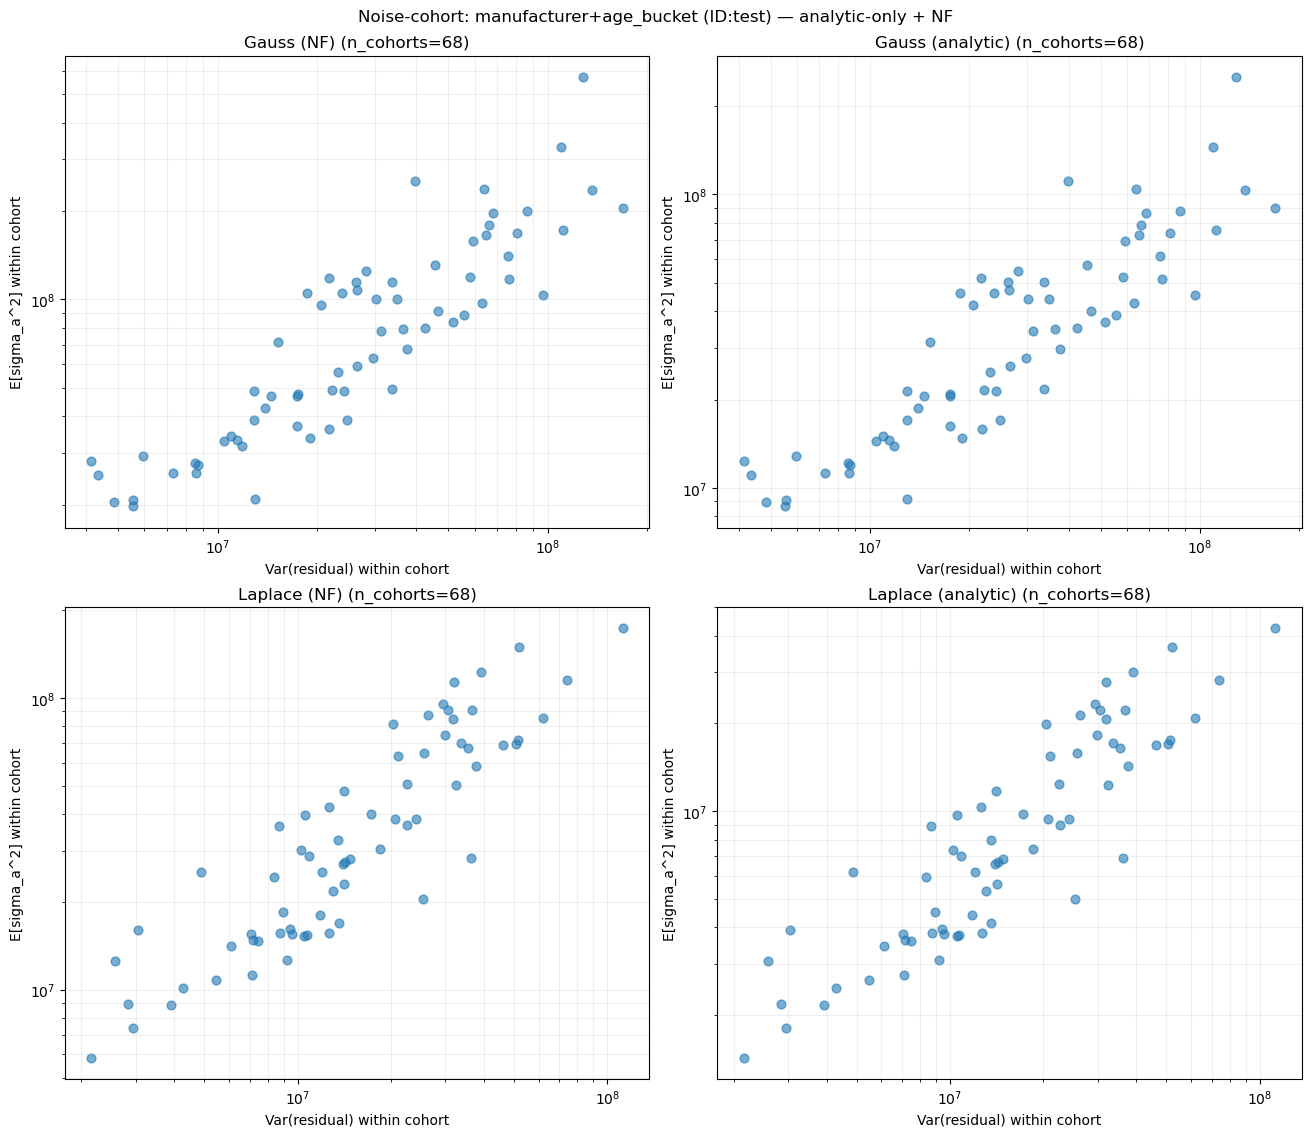

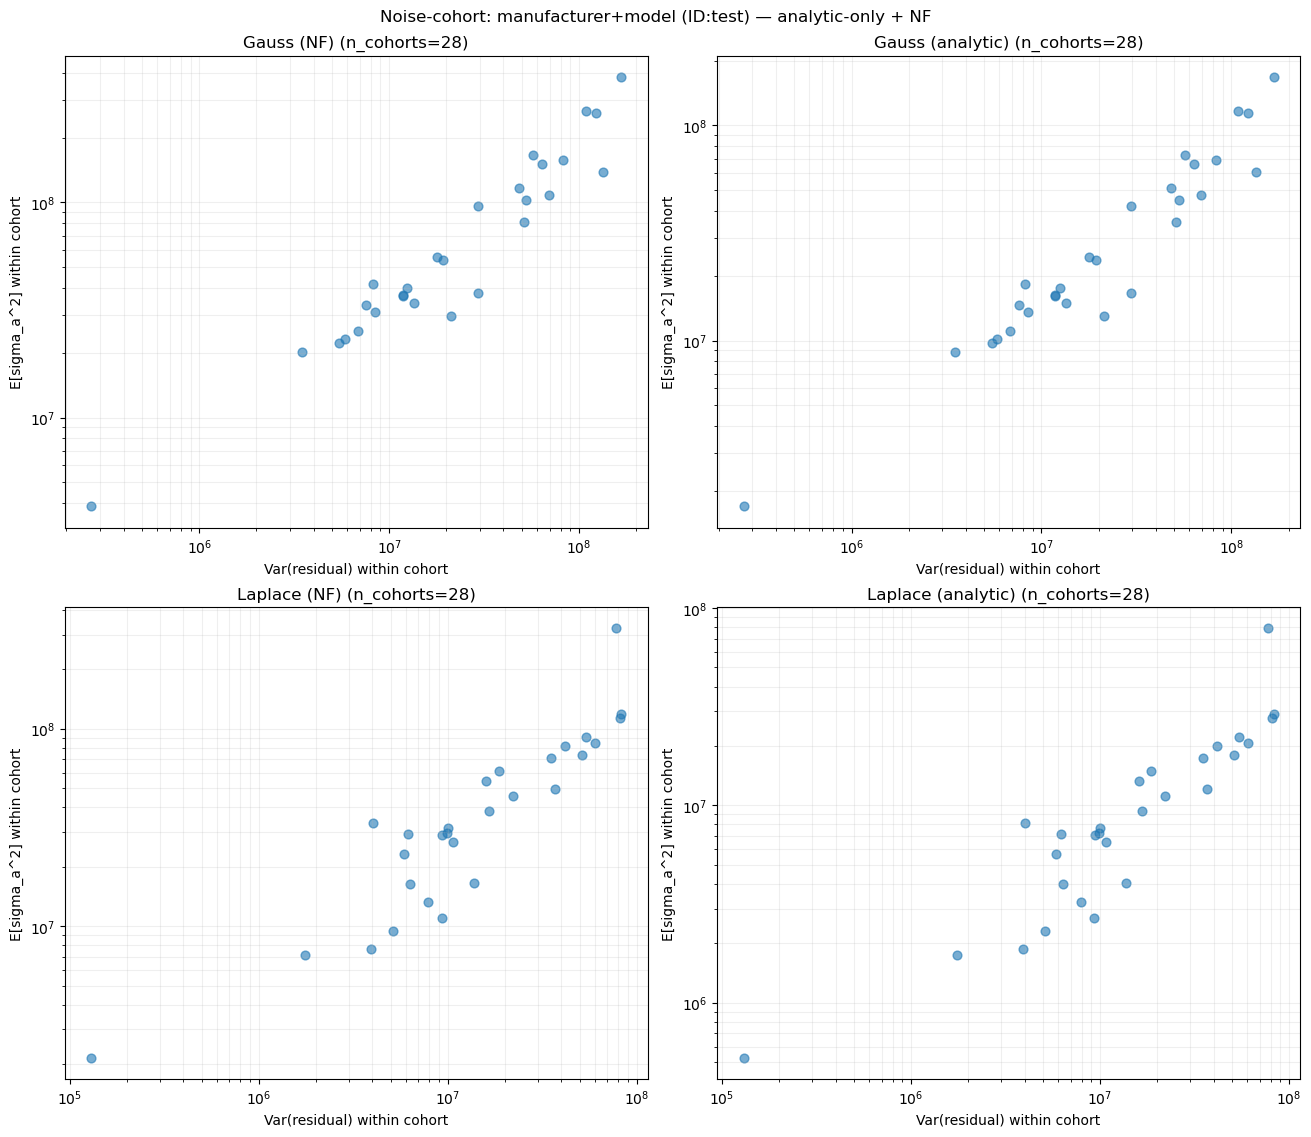

In [91]:
# --- Noise-cohort analysis (aleatoric validity) on ID:test — analytic-only variants ---
# Uses ONLY: Laplace (analytic), Gauss (analytic), and NF heads (if enabled + available).
# Cohorts:
#  1) manufacturer + age_bucket
#  2) manufacturer + model + age_bucket
#
# For each cohort g, compute:
#   Var_g(residual)  where residual = y_true - mu
#   E_g[sigma_a^2]   where sigma_a is aleatoric sigma (raw or calibrated)
# Also report bias_g = mean(residual) to check contamination by systematic error.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_CSV = "datasets/craigslist_cleaned.csv"
ID_COL = "id"

USE_CALIBRATED_SIGMAS_LOCAL = True
MIN_COHORT_N = 100

AGE_BINS = [0, 2, 4, 7, 10, 15, 25]
AGE_LABELS = [f"{AGE_BINS[i]}-{AGE_BINS[i+1]}" for i in range(len(AGE_BINS) - 1)]

COHORT_DEFS = {
    "manufacturer+age_bucket": ["manufacturer", "age_bucket"],
    "manufacturer+model": ["manufacturer", "model"],
}

# ---- Load cohort metadata once ----
usecols = [ID_COL, "manufacturer", "model", "age_years"]
meta = pd.read_csv(DATASET_CSV, usecols=usecols)
meta[ID_COL] = pd.to_numeric(meta[ID_COL], errors="coerce")
meta = meta.dropna(subset=[ID_COL]).drop_duplicates(subset=[ID_COL]).copy()
meta[ID_COL] = meta[ID_COL].astype(int)

meta["age_years"] = pd.to_numeric(meta["age_years"], errors="coerce")
meta["age_bucket"] = pd.cut(meta["age_years"], bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True)

print(f"[meta] loaded {len(meta):,} unique ids from {DATASET_CSV}")

def _attach_meta(df_eval: pd.DataFrame) -> pd.DataFrame:
    if ID_COL not in df_eval.columns:
        raise KeyError(f"Eval frame missing '{ID_COL}' column; cannot join cohorts")
    out = df_eval.copy()
    out[ID_COL] = pd.to_numeric(out[ID_COL], errors="coerce")
    out = out.dropna(subset=[ID_COL])
    out[ID_COL] = out[ID_COL].astype(int)
    out = out.merge(meta[[ID_COL, "manufacturer", "model", "age_bucket"]], on=ID_COL, how="left")
    return out

def _cohort_key(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    return df[cols].astype(str).agg(" / ".join, axis=1)

def _compute_group_table(df_eval: pd.DataFrame, spec: MethodSpec, cohort_name: str, cols: list[str]) -> pd.DataFrame:
    df_eval = _attach_meta(df_eval)
    miss = [c for c in cols if c not in df_eval.columns]
    if miss:
        raise KeyError(f"Missing {miss} after join for cohort={cohort_name}")

    y = df_eval["y_true"].to_numpy(float)
    mu = df_eval["mu"].to_numpy(float)
    resid = y - mu

    sA_raw = df_eval.get("sigma_ale_raw", pd.Series(np.nan, index=df_eval.index)).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL and spec.aleatoric_source == "analytic":
        # Analytic-only: apply alpha for (head_type, "analytic") if available; no epistemic term.
        sE_raw = np.zeros_like(sA_raw, dtype=float)
        sA, _, _ = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src="none",
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        # NF or raw mode: treat sigma_ale_raw as the aleatoric sigma directly.
        sA = np.asarray(sA_raw, float)

    tmp = pd.DataFrame(
        {
            "cohort": _cohort_key(df_eval, cols),
            "resid": resid,
            "sA2": np.square(sA),
        }
    )
    tmp = tmp[np.isfinite(tmp["resid"]) & np.isfinite(tmp["sA2"])]

    g = (
        tmp.groupby("cohort")
        .agg(
            n=("resid", "size"),
            resid_var=("resid", "var"),
            resid_bias=("resid", "mean"),
            mean_sA2=("sA2", "mean"),
        )
        .reset_index()
    )
    g = g[g["n"] >= int(MIN_COHORT_N)].copy()
    g["cohort_def"] = cohort_name
    g["method"] = spec.label
    g["kind"] = spec.kind
    return g

# ---- Choose ONLY analytic-only + NF specs (skip point, skip MC, skip ensembles, skip DIDO) ----
def _is_analytic_only(spec: MethodSpec) -> bool:
    return (spec.head_type in {"laplace", "gauss"}) and (str(spec.epistemic_source).lower() == "none")

def _is_nf(spec: MethodSpec) -> bool:
    return str(spec.kind).lower() == "nf" or str(spec.aleatoric_source).lower() == "nf"

SPECS = [s for s in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else [])) if (_is_analytic_only(s) or _is_nf(s))]
print("[noise-cohort] using specs:", [s.label for s in SPECS])

tables = []
for spec in SPECS:
    try:
        if _is_nf(spec):
            if RUN_DIRS.get(spec.key) is None:
                raise FileNotFoundError(f"RUN_DIRS[{spec.key!r}] is None")
            df_id = load_id_nf(RUN_DIRS[spec.key])
        else:
            # analytic-only laplace/gauss
            df_id = method_id_test_frame(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load ID test: {type(e).__name__}: {e}")
        continue

    for cohort_name, cols in COHORT_DEFS.items():
        try:
            tables.append(_compute_group_table(df_id, spec, cohort_name, cols))
        except Exception as e:
            print(f"[skip] {spec.label} / {cohort_name}: {type(e).__name__}: {e}")

if not tables:
    raise RuntimeError("No cohort tables produced. Check that eval frames have 'id' and that NF files exist (if enabled).")

df_noise = pd.concat(tables, ignore_index=True)

# ---- Summary correlations (log-log) per method + cohort_def ----
summary_rows = []
for (cohort_def, method), sub in df_noise.groupby(["cohort_def", "method"]):
    sub = sub[(sub["resid_var"] > 0) & (sub["mean_sA2"] > 0)].copy()
    if len(sub) < 5:
        continue
    x = np.log(sub["resid_var"].to_numpy(float))
    y = np.log(sub["mean_sA2"].to_numpy(float))
    corr = float(np.corrcoef(x, y)[0, 1]) if (np.std(x) > 0 and np.std(y) > 0) else float("nan")
    summary_rows.append(
        {
            "cohort_def": cohort_def,
            "method": method,
            "n_cohorts": int(len(sub)),
            "corr(log Var(resid), log E[sA^2])": corr,
            "median_abs_bias": float(np.median(np.abs(sub["resid_bias"].to_numpy(float)))),
        }
    )
df_noise_summary = pd.DataFrame(summary_rows).sort_values(
    ["cohort_def", "corr(log Var(resid), log E[sA^2])"], ascending=[True, False]
)
display(df_noise_summary)

# ---- Plots: subplots per cohort_def (one subplot per method) ----
def _plot_grid_for_cohort(cohort_def: str, df_all: pd.DataFrame):
    methods_here = sorted(df_all["method"].unique().tolist())
    n = len(methods_here)
    if n == 0:
        print(f"[plot] no methods for cohort_def={cohort_def}")
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5.5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, method in zip(axes, methods_here):
        sub = df_all[(df_all["method"] == method) & (df_all["resid_var"] > 0) & (df_all["mean_sA2"] > 0)].copy()
        if sub.empty:
            ax.set_axis_off()
            continue

        ax.scatter(
            sub["resid_var"],
            sub["mean_sA2"],
            s=40,          # constant marker size
            alpha=0.6,
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Var(residual) within cohort")
        ax.set_ylabel("E[sigma_a^2] within cohort")
        ax.set_title(f"{method} (n_cohorts={len(sub)})")
        ax.grid(True, which="both", alpha=0.2)

    for ax in axes[n:]:
        ax.set_axis_off()

    fig.suptitle(f"Noise-cohort: {cohort_def} (ID:test) — analytic-only + NF", y=1.02)
    plt.show()

for cohort_def, sub in df_noise.groupby("cohort_def"):
    _plot_grid_for_cohort(cohort_def, sub)


[skip] Laplace (NF): cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='nf_lpl', label='Laplace (NF)', head_type='laplace', aleatoric_source='nf', epistemic_source='none', kind='nf')
[skip] Gauss (NF): cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='nf_gau', label='Gauss (NF)', head_type='gauss', aleatoric_source='nf', epistemic_source='none', kind='nf')
[skip] Laplace + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')
[skip] Gauss + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_gau', label='Gauss + DIDO', head_type='gauss', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


,method,kind,head_type,aleatoric_source,epistemic_source,eval_scope,use_calibrated,nominal,mean_width
0,Laplace (analytic),regression,laplace,analytic,none,id_test,True,0.9,7361.215890
1,Laplace + ensemble,ensemble,laplace,analytic,ensemble,id_test,True,0.9,7479.493101
2,Laplace + MC,regression,laplace,analytic,mc,id_test,True,0.9,10670.572051
3,Gauss + ensemble,ensemble,gauss,analytic,ensemble,id_test,True,0.9,14854.749129
4,Gauss (analytic),regression,gauss,analytic,none,id_test,True,0.9,16542.573805
5,Gauss + MC,regression,gauss,analytic,mc,id_test,True,0.9,17184.260167


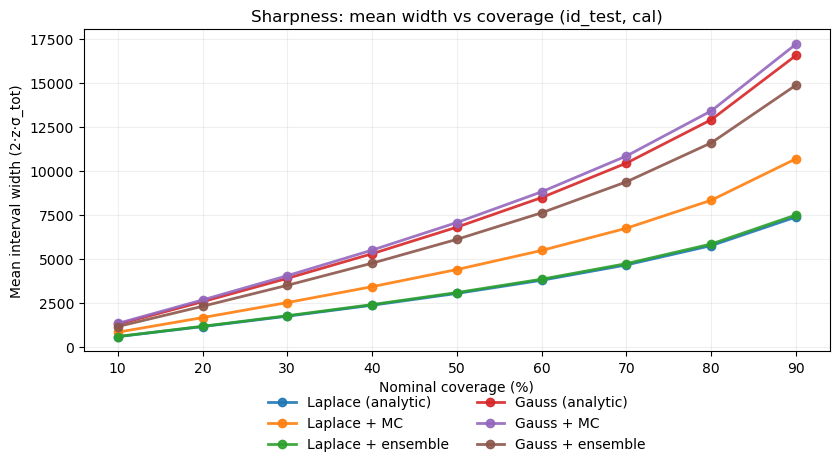

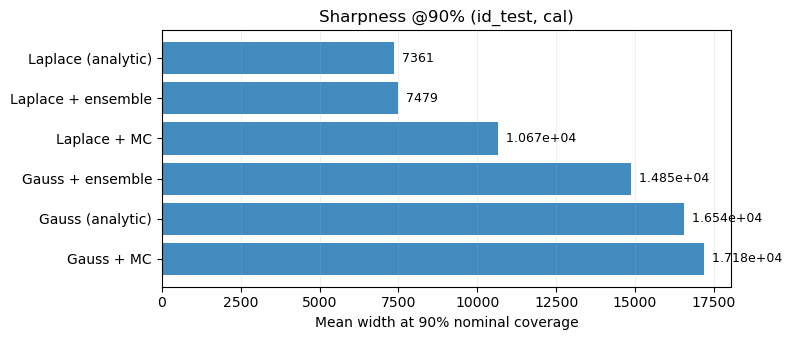

In [92]:
# --- Sharpness: interval width vs nominal coverage (and width@90%) ---
# Uses total predictive sigma σ_tot (raw or calibrated), assuming symmetric normal intervals:
#   PI(level) = [mu ± z(level)*σ_tot]
# Sharpness metric: mean interval width = 2*z*σ_tot  (lower is sharper at same coverage).
#
# Robust to missing methods; skips methods without σ_tot.
# Toggle raw vs calibrated sigmas with USE_CALIBRATED_SIGMAS_LOCAL.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

USE_CALIBRATED_SIGMAS_LOCAL = True     # True = calibrated_sigmas(...); False = raw sigma columns
EVAL_SCOPE = "id_test"                 # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)    # used when EVAL_SCOPE includes OOD

# Nominal coverage grid
LEVELS = np.arange(0.10, 1.00, 0.10)   # 0.1 ... 0.9
LEVEL_90 = 0.90

def _z_for_level(level: float) -> float:
    level = float(level)
    return float(norm.ppf((1.0 + level) / 2.0))

Z = {lvl: _z_for_level(lvl) for lvl in LEVELS}
Z90 = _z_for_level(LEVEL_90)

def _sigma_total_from_df(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
        return np.asarray(sT, float)

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    return np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))

def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)

rows = []
width90_rows = []
curve_cache = {}  # method -> (levels, mean_widths)

for spec in METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else []):
    if spec.head_type == "point":
        continue

    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load eval frames: {type(e).__name__}: {e}")
        continue

    try:
        sT = _sigma_total_from_df(spec, df_all)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot compute sigma_total: {type(e).__name__}: {e}")
        continue

    mask = np.isfinite(sT) & (sT > 0)
    if not np.any(mask):
        print(f"[skip] {spec.label}: no finite sigma_total")
        continue

    sT = sT[mask]

    mean_widths = []
    for lvl in LEVELS:
        w = 2.0 * Z[lvl] * sT
        mean_widths.append(float(np.mean(w)))

    curve_cache[spec.label] = (LEVELS.copy(), np.array(mean_widths, float))

    for lvl, mw in zip(LEVELS, mean_widths):
        rows.append(
            {
                "method": spec.label,
                "kind": spec.kind,
                "head_type": spec.head_type,
                "aleatoric_source": spec.aleatoric_source,
                "epistemic_source": spec.epistemic_source,
                "eval_scope": EVAL_SCOPE,
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
                "nominal": float(lvl),
                "z": float(Z[lvl]),
                "mean_width": float(mw),
            }
        )

    w90 = float(np.mean(2.0 * Z90 * sT))
    width90_rows.append(
        {
            "method": spec.label,
            "kind": spec.kind,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "eval_scope": EVAL_SCOPE,
            "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            "nominal": LEVEL_90,
            "mean_width": w90,
        }
    )

df_width_curve = pd.DataFrame(rows)
df_width_90 = pd.DataFrame(width90_rows).sort_values("mean_width", ascending=True).reset_index(drop=True)

display(df_width_90)

# --- Plot 1: mean interval width vs nominal coverage (one line per method) ---
plt.figure(figsize=(8.5, 5))
for method, (lvls, mws) in curve_cache.items():
    plt.plot(lvls * 100, mws, marker="o", linewidth=2, alpha=0.9, label=method)
plt.xlabel("Nominal coverage (%)")
plt.ylabel("Mean interval width (2·z·σ_tot)")
plt.title(f"Sharpness: mean width vs coverage ({EVAL_SCOPE}, {'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})")
plt.grid(True, alpha=0.2)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

# --- Plot 2: mean width at 90% (barh) ---
if not df_width_90.empty:
    plt.figure(figsize=(8, max(3.5, 0.45 * len(df_width_90))))
    y = np.arange(len(df_width_90))
    vals = df_width_90["mean_width"].to_numpy(float)
    plt.barh(y, vals, alpha=0.85)
    plt.yticks(y, df_width_90["method"].tolist())
    plt.gca().invert_yaxis()
    plt.xlabel("Mean width at 90% nominal coverage")
    plt.title(f"Sharpness @90% ({EVAL_SCOPE}, {'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})")
    plt.grid(True, axis="x", alpha=0.2)
    for yi, v in zip(y, vals):
        plt.text(v, yi, f"  {v:.4g}", va="center", ha="left", fontsize=9)
    plt.tight_layout()
    plt.show()


[skip] Laplace (NF): cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='nf_lpl', label='Laplace (NF)', head_type='laplace', aleatoric_source='nf', epistemic_source='none', kind='nf')
[skip] Gauss (NF): cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='nf_gau', label='Gauss (NF)', head_type='gauss', aleatoric_source='nf', epistemic_source='none', kind='nf')
[skip] Laplace + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')
[skip] Gauss + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_gau', label='Gauss + DIDO', head_type='gauss', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


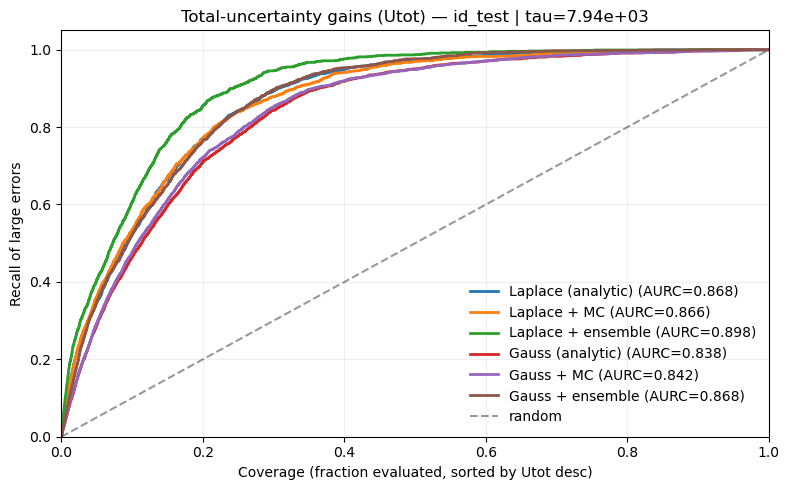

,method,head_type,aleatoric_source,epistemic_source,n,prev_large,AURC
0,Laplace + ensemble,laplace,analytic,ensemble,25358,0.046770,0.897549
1,Laplace (analytic),laplace,analytic,none,25358,0.061440,0.867664
2,Gauss + ensemble,gauss,analytic,ensemble,25358,0.087665,0.867518
3,Laplace + MC,laplace,analytic,mc,25358,0.065108,0.865886
4,Gauss + MC,gauss,analytic,mc,25358,0.109551,0.842168
5,Gauss (analytic),gauss,analytic,none,25358,0.108368,0.838324


In [93]:
# --- Total-uncertainty gains curve for catching large errors (AURC) ---
# Uses LARGE_ERROR_TAU (defined earlier from point baseline on ID test).
# Plots cumulative recall of large errors vs coverage when ranking by Utot.
# Handles missing methods gracefully.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = True  # True = calibrated, False = raw
EVAL_SCOPE = "id_test"              # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)

try:
    _ = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e

def _sigma_total(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
        return np.asarray(sT, float)
    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    return np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))

def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)

# Methods: all non-point heads with uncertainty
SPECS = [s for s in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else [])) if s.head_type != "point"]

summary = []
plt.figure(figsize=(8, 5))

# Random baseline (expected recall = coverage)
for spec in SPECS:
    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load eval frames: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    is_large = abs_err > float(LARGE_ERROR_TAU)

    if np.nansum(is_large.astype(int)) == 0:
        print(f"[skip] {spec.label}: no large-error positives under tau={LARGE_ERROR_TAU:.4g}")
        continue

    try:
        sT = _sigma_total(spec, df_all)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot compute Utot: {type(e).__name__}: {e}")
        continue

    mask = np.isfinite(sT) & np.isfinite(is_large)
    if not np.any(mask):
        print(f"[skip] {spec.label}: no finite Utot values")
        continue

    d = pd.DataFrame({"Utot": sT[mask], "is_large": is_large[mask].astype(int)})
    d = d.dropna()
    if d["is_large"].nunique() < 2:
        print(f"[skip] {spec.label}: insufficient positives/negatives")
        continue

    d = d.sort_values("Utot", ascending=False, kind="mergesort")
    total_pos = float(d["is_large"].sum())
    cum_pos = d["is_large"].cumsum().to_numpy(float)
    recall = cum_pos / total_pos
    coverage = np.arange(1, len(d) + 1) / float(len(d))

    # AURC = area under recall vs coverage
    aurc = float(np.trapezoid(recall, coverage))

    summary.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(d)),
            "prev_large": float(total_pos / len(d)),
            "AURC": aurc,
        }
    )

    plt.plot(coverage, recall, lw=2, label=f"{spec.label} (AURC={aurc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")

plt.xlabel("Coverage (fraction evaluated, sorted by Utot desc)")
plt.ylabel("Recall of large errors")
plt.title(f"Total-uncertainty gains (Utot) — {EVAL_SCOPE} | tau={LARGE_ERROR_TAU:.3g}")
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.grid(True, alpha=0.2)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

df_aurc = pd.DataFrame(summary).sort_values("AURC", ascending=False).reset_index(drop=True)
display(df_aurc)


[skip] Laplace + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')
[skip] Gauss + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_gau', label='Gauss + DIDO', head_type='gauss', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


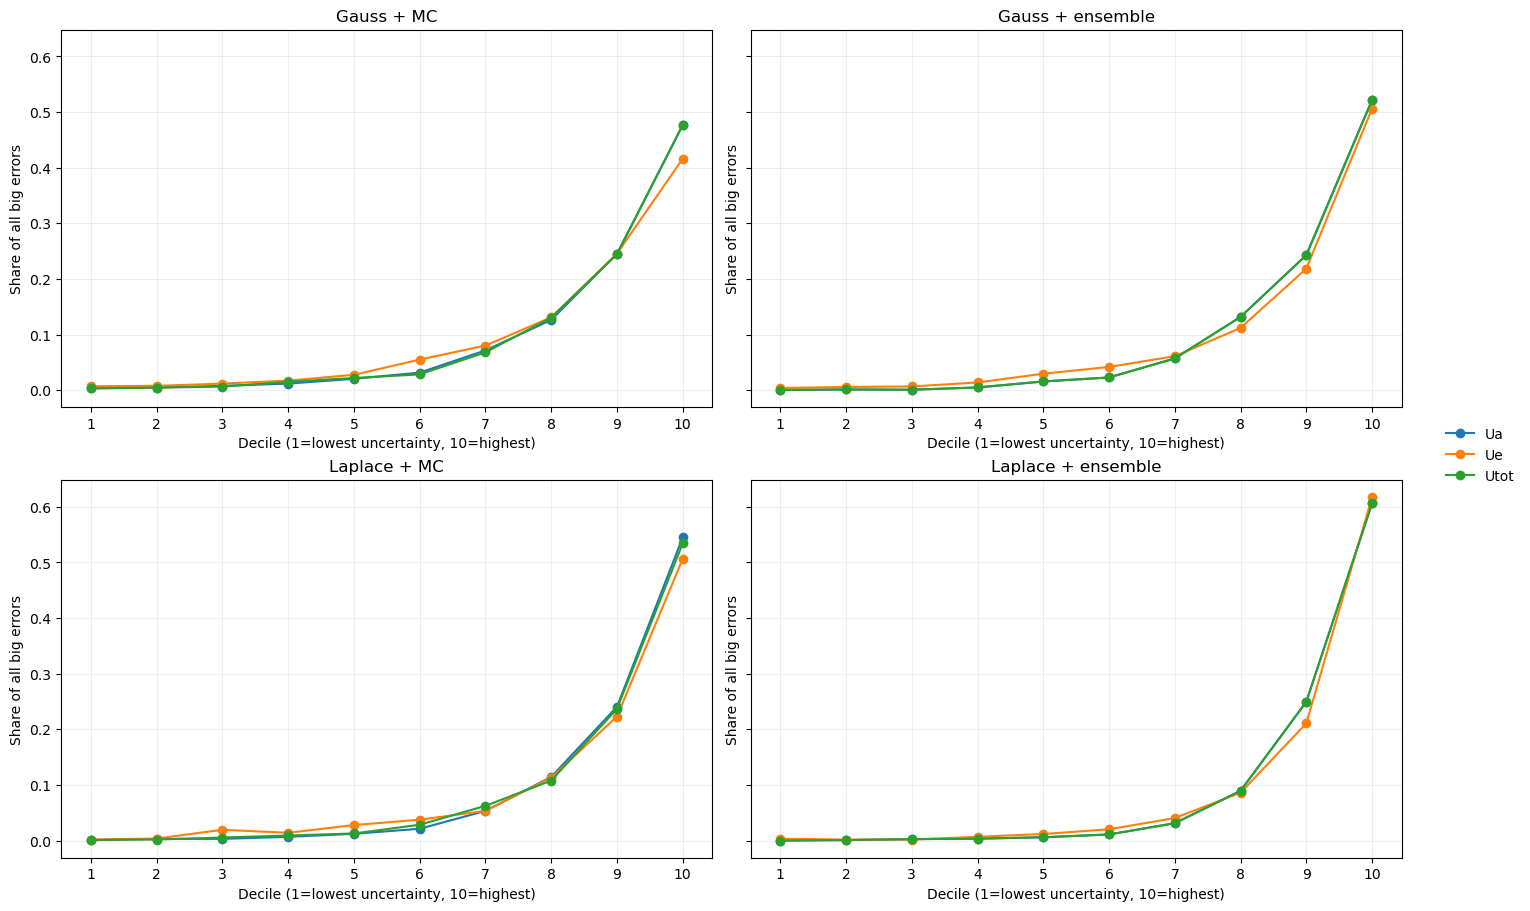

In [94]:
# --- Big-error share by uncertainty decile (Ua / Ue / Utot) ---
# Now: plot ONLY methods that have both aleatoric + epistemic signals.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = True  # True = calibrated, False = raw
EVAL_SCOPE = "id_test"              # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)
SIGNALS = ["Ua", "Ue", "Utot"]
N_BINS = 10

try:
    _ = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)

# Methods: only those with epistemic signals
SPECS = [s for s in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else []))
         if (s.head_type != "point" and str(s.epistemic_source).lower() in {"mc", "ensemble", "dido"})]

all_rows = []
methods_with_both = []

for spec in SPECS:
    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load eval frames: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    is_large = (abs_err > float(LARGE_ERROR_TAU)).astype(int)

    if np.nansum(is_large) == 0:
        print(f"[skip] {spec.label}: no large-error positives under tau={LARGE_ERROR_TAU:.4g}")
        continue

    try:
        sA, sE, sT = _sigmas(spec, df_all)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot compute sigmas: {type(e).__name__}: {e}")
        continue

    # Require finite Ua + Ue + Utot on the same rows
    valid = np.isfinite(sA) & np.isfinite(sE) & np.isfinite(sT) & np.isfinite(is_large)
    if not np.any(valid):
        print(f"[skip] {spec.label}: no rows with both ale+epi signals")
        continue

    methods_with_both.append(spec.label)

    sig_map = {"Ua": sA[valid], "Ue": sE[valid], "Utot": sT[valid]}
    is_large_valid = is_large[valid]

    for sig_name in SIGNALS:
        sig = sig_map[sig_name]
        d = pd.DataFrame({"sig": sig, "is_large": is_large_valid})
        d = d[np.isfinite(d["sig"])]

        if d.empty or d["is_large"].sum() == 0:
            continue

        try:
            d["decile"] = pd.qcut(d["sig"], N_BINS, labels=False, duplicates="drop")
        except ValueError:
            print(f"[skip] {spec.label} / {sig_name}: not enough unique values for deciles")
            continue

        d = d.dropna(subset=["decile"])
        if d.empty:
            continue

        d["decile"] = d["decile"].astype(int)

        total_pos = float(d["is_large"].sum())
        grp = (
            d.groupby("decile")["is_large"]
            .sum()
            .reindex(range(int(d["decile"].min()), int(d["decile"].max()) + 1))
            .fillna(0.0)
        )
        share = grp.to_numpy(float) / total_pos

        for decile_idx, sh in zip(grp.index, share):
            all_rows.append(
                {
                    "method": spec.label,
                    "signal": sig_name,
                    "decile": int(decile_idx) + 1,
                    "share_big_errors": float(sh),
                }
            )

df_share = pd.DataFrame(all_rows)
# display(df_share)

# --- Plot: one subplot per method (only those with ale+epi) ---
if df_share.empty:
    print("No data to plot.")
else:
    methods = sorted(df_share["method"].unique().tolist())
    n = len(methods)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, method in zip(axes, methods):
        sub = df_share[df_share["method"] == method]
        for sig_name in SIGNALS:
            sm = sub[sub["signal"] == sig_name].sort_values("decile")
            if sm.empty:
                continue
            ax.plot(sm["decile"], sm["share_big_errors"], marker="o", label=sig_name)

        ax.set_title(method)
        ax.set_xlabel("Decile (1=lowest uncertainty, 10=highest)")
        ax.set_ylabel("Share of all big errors")
        ax.set_xticks(range(1, N_BINS + 1))
        ax.grid(True, alpha=0.2)

    for ax in axes[n:]:
        ax.set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.show()


[skip] Laplace + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')
[skip] Gauss + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_gau', label='Gauss + DIDO', head_type='gauss', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


,method,coverage,mae,eval_scope,use_calibrated
0,Laplace + MC,0.1,751.215247,id_test,True
1,Laplace + MC,0.2,944.165201,id_test,True
2,Laplace + MC,0.3,1121.168312,id_test,True
3,Laplace + MC,0.4,1234.021391,id_test,True
4,Laplace + MC,0.5,1330.646505,id_test,True
5,Laplace + MC,0.6,1407.970412,id_test,True
6,Laplace + MC,0.7,1518.515274,id_test,True
7,Laplace + MC,0.8,1696.956682,id_test,True
8,Laplace + MC,0.9,2000.874415,id_test,True
9,Laplace + MC,1.0,2559.358448,id_test,True


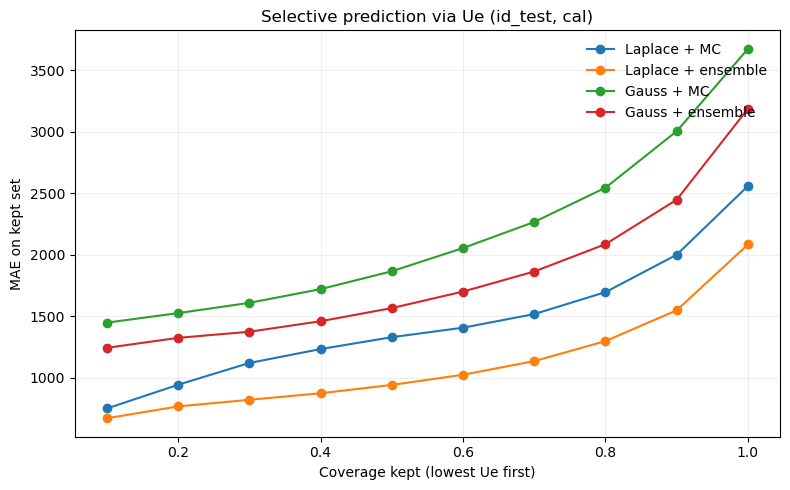

In [95]:
# --- Epistemic selective prediction: risk (MAE) vs coverage ---
# For each method with epistemic signal, sort by Ue (low=confident).
# Compute MAE on the kept subset as coverage varies.
# Handles missing methods gracefully.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = True  # True = calibrated, False = raw
EVAL_SCOPE = "id_test"              # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)

# Coverage grid (fraction kept)
COVERAGES = np.linspace(0.1, 1.0, 10)

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)

# Only methods with epistemic signals
SPECS = [s for s in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else []))
         if (s.head_type != "point" and str(s.epistemic_source).lower() in {"mc", "ensemble", "dido"})]

rows = []
curves = {}

for spec in SPECS:
    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load eval frames: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)

    try:
        _, sE, _ = _sigmas(spec, df_all)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot compute Ue: {type(e).__name__}: {e}")
        continue

    # shared valid mask
    valid = np.isfinite(abs_err) & np.isfinite(sE)
    if not np.any(valid):
        print(f"[skip] {spec.label}: no finite Ue/err")
        continue

    d = pd.DataFrame({"err": abs_err[valid], "Ue": sE[valid]})
    d = d.sort_values("Ue", ascending=True, kind="mergesort")  # low Ue = more confident

    maes = []
    for c in COVERAGES:
        k = max(1, int(np.floor(c * len(d))))
        sub = d.iloc[:k]
        maes.append(float(np.mean(sub["err"])) if len(sub) else float("nan"))

    curves[spec.label] = maes

    for c, mae in zip(COVERAGES, maes):
        rows.append(
            {
                "method": spec.label,
                "coverage": float(c),
                "mae": float(mae),
                "eval_scope": EVAL_SCOPE,
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            }
        )

df_sel = pd.DataFrame(rows)
display(df_sel)

# --- Plot ---
if not curves:
    print("No curves to plot.")
else:
    plt.figure(figsize=(8, 5))
    for method, maes in curves.items():
        plt.plot(COVERAGES, maes, marker="o", label=method)

    plt.xlabel("Coverage kept (lowest Ue first)")
    plt.ylabel("MAE on kept set")
    plt.title(f"Selective prediction via Ue ({EVAL_SCOPE}, {'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})")
    plt.grid(True, alpha=0.2)
    plt.legend(loc="upper right", frameon=False)
    plt.tight_layout()
    plt.show()


[skip] Laplace + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')
[skip] Gauss + DIDO: cannot load eval frames: ValueError: Unhandled core spec: MethodSpec(key='dido_gau', label='Gauss + DIDO', head_type='gauss', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


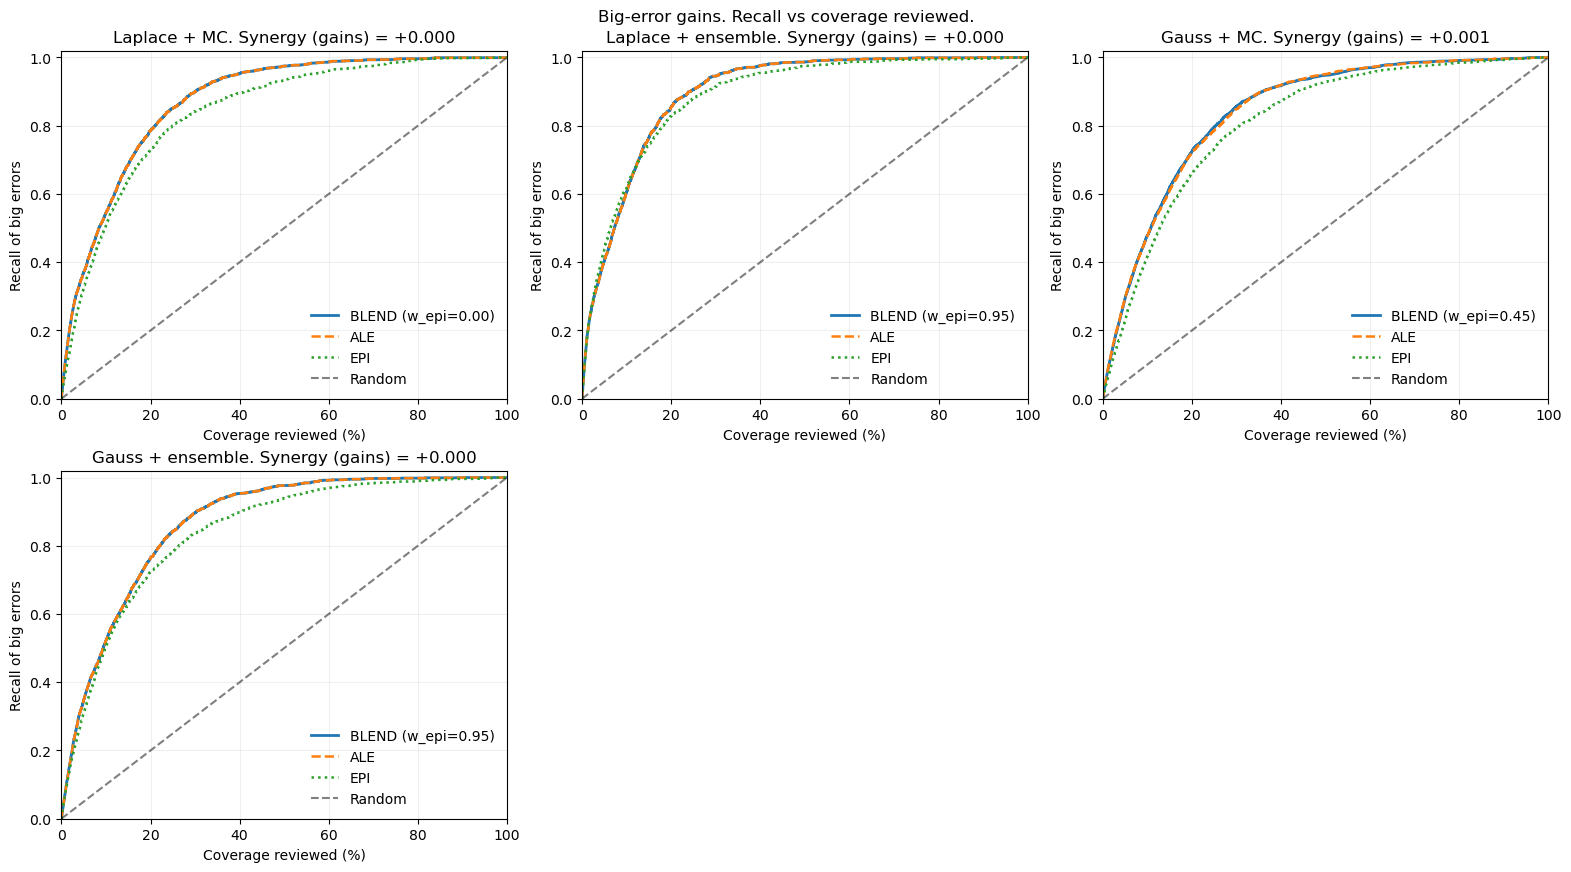

In [96]:
# --- Decision synergy: gains curves per method (ALE vs EPI vs BLEND) ---
# Produces one subplot per method, like the example figure.
# Uses LARGE_ERROR_TAU and computes recall vs coverage for:
#   ALE = Ua, EPI = Ue, BLEND = w*Ue + (1-w)*Ua (w chosen to max AURC).
# Legend includes the chosen w and synergy (AURC_blend - max(AURC_ale, AURC_epi)).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = True
EVAL_SCOPE = "id_test"              # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS)
WEIGHTS = np.linspace(0.0, 1.0, 21)

try:
    _ = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_test_frame(spec).copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)

def _gains_curve(score: np.ndarray, is_large: np.ndarray):
    d = pd.DataFrame({"score": score, "is_large": is_large}).dropna()
    if d.empty or d["is_large"].nunique() < 2:
        return None
    d = d.sort_values("score", ascending=False, kind="mergesort")
    total_pos = float(d["is_large"].sum())
    if total_pos == 0:
        return None
    cum_pos = d["is_large"].cumsum().to_numpy(float)
    recall = cum_pos / total_pos
    coverage = np.arange(1, len(d) + 1) / float(len(d))
    aurc = float(np.trapezoid(recall, coverage))
    return coverage, recall, aurc

# Methods with epistemic signal
SPECS = [s for s in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else []))
         if (s.head_type != "point" and str(s.epistemic_source).lower() in {"mc", "ensemble", "dido"})]

results = []

for spec in SPECS:
    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load eval frames: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    is_large = (abs_err > float(LARGE_ERROR_TAU)).astype(int)

    if np.nansum(is_large) == 0:
        print(f"[skip] {spec.label}: no large-error positives under tau={LARGE_ERROR_TAU:.4g}")
        continue

    try:
        sA, sE, _ = _sigmas(spec, df_all)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot compute sigmas: {type(e).__name__}: {e}")
        continue

    valid = np.isfinite(sA) & np.isfinite(sE) & np.isfinite(is_large)
    if not np.any(valid):
        print(f"[skip] {spec.label}: no rows with both Ua & Ue")
        continue

    sA = sA[valid]
    sE = sE[valid]
    y_large = is_large[valid]

    # ALE and EPI curves
    g_ale = _gains_curve(sA, y_large)
    g_epi = _gains_curve(sE, y_large)
    if g_ale is None or g_epi is None:
        print(f"[skip] {spec.label}: insufficient data for ALE/EPI")
        continue

    # Best blend
    best = {"w": None, "aurc": -np.inf, "curve": None}
    for w in WEIGHTS:
        score = w * sE + (1.0 - w) * sA
        g = _gains_curve(score, y_large)
        if g is None:
            continue
        _, _, aurc = g
        if np.isfinite(aurc) and aurc > best["aurc"]:
            best = {"w": float(w), "aurc": float(aurc), "curve": g}

    if best["curve"] is None:
        continue

    aurc_ale = g_ale[2]
    aurc_epi = g_epi[2]
    synergy = float(best["aurc"] - max(aurc_ale, aurc_epi))

    results.append(
        {
            "method": spec.label,
            "g_ale": g_ale,
            "g_epi": g_epi,
            "g_blend": best["curve"],
            "w": best["w"],
            "aurc_ale": aurc_ale,
            "aurc_epi": aurc_epi,
            "aurc_blend": best["aurc"],
            "synergy": synergy,
        }
    )

if not results:
    print("No methods produced synergy plots.")
else:
    n = len(results)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, r in zip(axes, results):
        method = r["method"]
        cov_b, rec_b, _ = r["g_blend"]
        cov_a, rec_a, _ = r["g_ale"]
        cov_e, rec_e, _ = r["g_epi"]

        ax.plot(cov_b * 100, rec_b, lw=2, label=f"BLEND (w_epi={r['w']:.2f})")
        ax.plot(cov_a * 100, rec_a, lw=1.8, ls="--", label="ALE")
        ax.plot(cov_e * 100, rec_e, lw=1.8, ls=":", label="EPI")
        ax.plot([0, 100], [0, 1], "k--", alpha=0.5, label="Random")

        ax.set_title(f"{method}. Synergy (gains) = {r['synergy']:+.3f}")
        ax.set_xlabel("Coverage reviewed (%)")
        ax.set_ylabel("Recall of big errors")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)

    for ax in axes[n:]:
        ax.set_axis_off()

    fig.suptitle("Big-error gains. Recall vs coverage reviewed.", y=1.02)
    plt.show()


In [97]:
# --- 0) Setup (core method list + global toggles) ---
# Keeps the notebook focused on a small, thesis-aligned set of methods.
# Assumes MethodSpec + RUN_DIRS + load_* + calibrated_sigmas already exist earlier.

import numpy as np

# Global toggle used by downstream analysis cells
USE_CALIBRATED_SIGMAS = True  # True = use calibrated_sigmas(); False = use raw sigma_ale_raw/sigma_epi_raw

# Helper: safe lookup into enable_methods (if present in cfg)
_enable = (cfg.get("enable_methods", {}) if "cfg" in globals() and isinstance(cfg.get("enable_methods", {}), dict) else {})

def _enabled(key: str, default: bool = True) -> bool:
    return bool(_enable.get(key, default))

# --- Core set (always try to include if enabled + run exists) ---
CORE_METHODS = [
    MethodSpec("point",        "Point",              "point",   "none",     "none",     "regression"),

    MethodSpec("lpl_mc",       "Laplace + MC",       "laplace", "analytic", "mc",       "regression"),
    MethodSpec("gau_mc",       "Gauss + MC",         "gauss",   "analytic", "mc",       "regression"),

    MethodSpec("esm_lpl",      "Laplace + ensemble", "laplace", "analytic", "ensemble", "ensemble"),
    MethodSpec("esm_gau",      "Gauss + ensemble",   "gauss",   "analytic", "ensemble", "ensemble"),
]

# --- Extensions (optional) ---
EXT_METHODS = []
if _enabled("nf_laplace", False):
    EXT_METHODS.append(MethodSpec("nf_lpl",  "Laplace (NF)",   "laplace", "nf",      "none", "nf"))
if _enabled("dido_laplace", False):
    EXT_METHODS.append(MethodSpec("dido_lpl","Laplace + DIDO", "laplace", "analytic", "dido", "dido"))

# Combine
METHODS_FOCUSED = CORE_METHODS + EXT_METHODS

# Filter based on what eval dirs actually exist (RUN_DIRS may be None for missing evals)
def _has_run_for_spec(spec: MethodSpec) -> bool:
    if spec.key == "point":
        return RUN_DIRS.get("point") is not None
    if spec.key == "lpl_mc":
        return RUN_DIRS.get("lpl") is not None
    if spec.key == "gau_mc":
        return RUN_DIRS.get("gau") is not None
    if spec.key == "esm_lpl":
        return RUN_DIRS.get("esm_lpl") is not None
    if spec.key == "esm_gau":
        return RUN_DIRS.get("esm_gau") is not None
    if spec.key == "nf_lpl":
        return RUN_DIRS.get("nf_lpl") is not None
    if spec.key == "dido_lpl":
        return RUN_DIRS.get("dido_lpl") is not None
    return True

METHODS_FOCUSED = [m for m in METHODS_FOCUSED if _has_run_for_spec(m)]

print("USE_CALIBRATED_SIGMAS =", USE_CALIBRATED_SIGMAS)
print("\nFocused method set (available runs):")
for m in METHODS_FOCUSED:
    print(f"- {m.label:18s}  key={m.key:8s}  head={m.head_type:7s}  ale={m.aleatoric_source:8s}  epi={m.epistemic_source:8s}  kind={m.kind}")

# Convenience subsets for later cells
METHODS_PRED_DIST = [m for m in METHODS_FOCUSED if m.head_type != "point" and m.kind in {"regression", "ensemble", "nf"}]
METHODS_EPI_ONLY  = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() in {"mc", "ensemble", "dido"}]
METHODS_ALE_ONLY  = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() == "none" and m.head_type != "point"]

print("\nCounts:",
      "total=", len(METHODS_FOCUSED),
      "pred_dist=", len(METHODS_PRED_DIST),
      "epi=", len(METHODS_EPI_ONLY),
      "ale_only=", len(METHODS_ALE_ONLY))


USE_CALIBRATED_SIGMAS = True

Focused method set (available runs):
- Point               key=point     head=point    ale=none      epi=none      kind=regression
- Laplace + MC        key=lpl_mc    head=laplace  ale=analytic  epi=mc        kind=regression
- Gauss + MC          key=gau_mc    head=gauss    ale=analytic  epi=mc        kind=regression
- Laplace + ensemble  key=esm_lpl   head=laplace  ale=analytic  epi=ensemble  kind=ensemble
- Gauss + ensemble    key=esm_gau   head=gauss    ale=analytic  epi=ensemble  kind=ensemble
- Laplace (NF)        key=nf_lpl    head=laplace  ale=nf        epi=none      kind=nf
- Laplace + DIDO      key=dido_lpl  head=laplace  ale=analytic  epi=dido      kind=dido

Counts: total= 7 pred_dist= 5 epi= 5 ale_only= 1


,dataset,method,kind,head_type,aleatoric_source,epistemic_source,n,PICP@90,PIW@90,ECE(10–90) pp,use_calibrated
0,id:test,Laplace (NF),nf,laplace,nf,none,25358,0.796869,7361.215891,4.394405,True
1,id:test,Laplace + ensemble,ensemble,laplace,analytic,ensemble,25358,0.852433,7479.493101,3.564161,True
2,id:test,Laplace + MC,regression,laplace,analytic,mc,25358,0.895694,10670.572051,7.017904,True
3,id:test,Gauss + ensemble,ensemble,gauss,analytic,ensemble,25358,0.926611,14854.749129,8.576299,True
4,id:test,Gauss + MC,regression,gauss,analytic,mc,25358,0.928543,17184.260167,7.786278,True
5,ood:knn_hard,Laplace + ensemble,ensemble,laplace,analytic,ensemble,1581,0.631879,11049.287379,18.051163,True
6,ood:knn_hard,Laplace (NF),nf,laplace,nf,none,1581,0.623656,11088.700574,17.924661,True
7,ood:knn_hard,Laplace + MC,regression,laplace,analytic,mc,1585,0.767823,17602.461005,6.081318,True
8,ood:knn_hard,Gauss + ensemble,ensemble,gauss,analytic,ensemble,1582,0.829330,21901.354397,2.935806,True
9,ood:knn_hard,Gauss + MC,regression,gauss,analytic,mc,1583,0.887555,27933.146531,4.666947,True


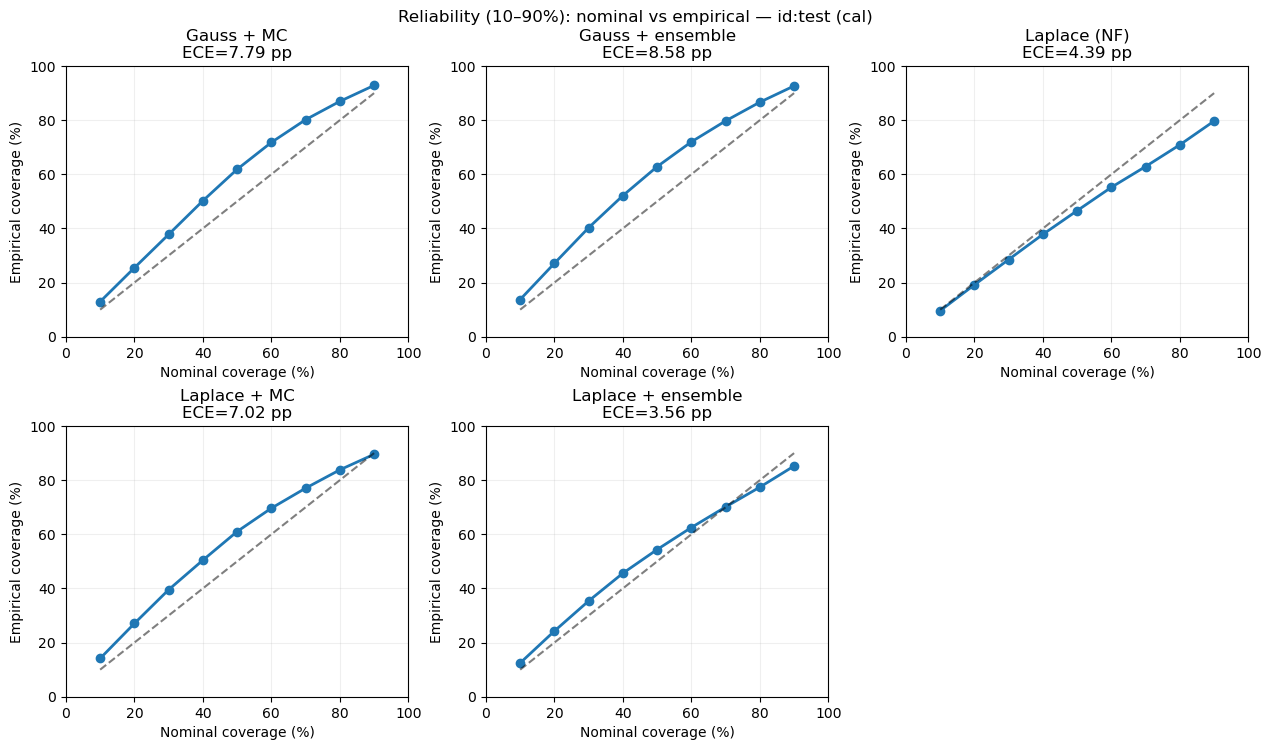

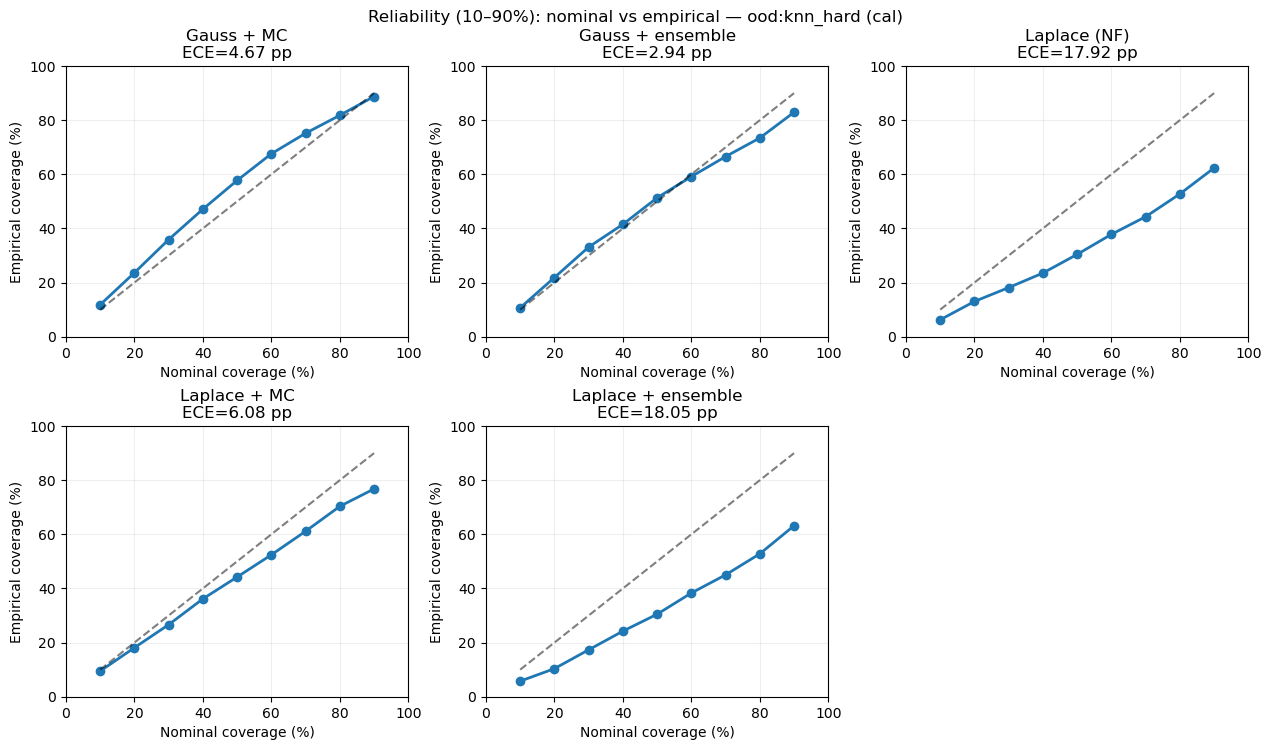

In [98]:
# --- 1) Calibration (compact): PICP@90 + PIW@90 + reliability plots (10–90) ---
# Assumes symmetric Normal intervals: PI(level) = [mu ± z(level)*σ_tot]
# Works for any method that provides mu + σ_tot (via sigma_ale_raw/sigma_epi_raw).
# Skips methods without predictive uncertainty (e.g., Point) and skips missing evals gracefully.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Toggle raw vs calibrated
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

# Include OOD evaluation in this cell?
INCLUDE_OOD = True
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# Coverage grid + target
LEVELS = np.arange(0.10, 1.00, 0.10)  # 0.10 ... 0.90
TARGET_LEVEL = 0.90
Z = {lvl: float(norm.ppf((1.0 + float(lvl)) / 2.0)) for lvl in LEVELS}

def _sigma_total(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
        return np.asarray(sT, float)

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    return np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))

def _load_frame(spec: MethodSpec, dataset: str, ood_label: str | None) -> pd.DataFrame:
    if dataset == "id:test":
        if spec.kind == "nf":
            return load_id_nf(RUN_DIRS[spec.key])
        if spec.kind in {"regression", "ensemble"}:
            return method_id_test_frame(spec)
        raise ValueError(f"Unsupported kind for ID:test: {spec.kind}")

    # OOD
    if dataset.startswith("ood:"):
        if ood_label is None:
            raise ValueError("ood_label required for OOD dataset")
        if spec.kind == "nf":
            return load_ood_nf(RUN_DIRS[spec.key], ood_label)
        if spec.kind in {"regression", "ensemble"}:
            return method_ood_frame(spec, ood_label)
        raise ValueError(f"Unsupported kind for OOD: {spec.kind}")

    raise ValueError(f"Unknown dataset={dataset!r}")

# Choose methods that represent predictive distributions (exclude point + dido)
if "METHODS_PRED_DIST" in globals():
    SPECS = list(METHODS_PRED_DIST)
elif "METHODS_FOCUSED" in globals():
    SPECS = [m for m in METHODS_FOCUSED if m.head_type != "point" and m.kind in {"regression", "ensemble", "nf"}]
else:
    SPECS = [m for m in METHODS_CORE if m.head_type != "point"]

datasets = [("id:test", None)]
if INCLUDE_OOD:
    datasets += [(f"ood:{lbl}", lbl) for lbl in OOD_LABELS_LOCAL]

summary_rows = []
curves = {}  # (dataset, method) -> (nominal%, empirical%, ece_pp)

for dataset_name, ood_label in datasets:
    for spec in SPECS:
        # Skip if run dir missing
        try:
            df = _load_frame(spec, dataset_name, ood_label)
        except Exception as e:
            print(f"[skip] {spec.label} / {dataset_name}: {type(e).__name__}: {e}")
            continue

        y = df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float)
        mu = df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)
        sT = _sigma_total(spec, df)

        err = np.abs(y - mu)
        mask = np.isfinite(err) & np.isfinite(sT) & (sT > 0)
        if not np.any(mask):
            print(f"[skip] {spec.label} / {dataset_name}: no finite (y,mu,σ_tot)")
            continue

        err = err[mask]
        sT = sT[mask]

        emp_cov = []
        mean_w = []
        for lvl in LEVELS:
            z = Z[lvl]
            emp_cov.append(float(np.mean(err <= z * sT)))
            mean_w.append(float(np.mean(2.0 * z * sT)))

        emp_cov = np.asarray(emp_cov, float)
        mean_w = np.asarray(mean_w, float)

        # ECE over 10–90: mean abs(coverage error), in percentage points
        diffs = np.abs(emp_cov - LEVELS)
        diffs = diffs[np.isfinite(diffs)]
        ece_pp = float(100.0 * np.mean(diffs)) if diffs.size else float("nan")

        # Pull @90
        i90 = int(np.where(np.isclose(LEVELS, TARGET_LEVEL))[0][0])
        picp90 = float(emp_cov[i90])
        piw90 = float(mean_w[i90])

        summary_rows.append(
            {
                "dataset": dataset_name,
                "method": spec.label,
                "kind": spec.kind,
                "head_type": spec.head_type,
                "aleatoric_source": spec.aleatoric_source,
                "epistemic_source": spec.epistemic_source,
                "n": int(err.size),
                "PICP@90": picp90,
                "PIW@90": piw90,
                "ECE(10–90) pp": ece_pp,
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            }
        )

        curves[(dataset_name, spec.label)] = (LEVELS * 100, emp_cov * 100, ece_pp)

df_cal = pd.DataFrame(summary_rows).sort_values(["dataset", "PIW@90"], ascending=[True, True]).reset_index(drop=True)
display(df_cal)

# --- Reliability plots: nominal vs empirical coverage (10–90) ---
for dataset_name, _ in datasets:
    methods_here = [m for (ds, m) in curves.keys() if ds == dataset_name]
    methods_here = sorted(set(methods_here))
    if not methods_here:
        continue

    n = len(methods_here)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, method in zip(axes, methods_here):
        x_nom, y_emp, ece_pp = curves[(dataset_name, method)]
        ax.plot(x_nom, y_emp, "-o", lw=2)
        ax.plot([10, 90], [10, 90], "k--", alpha=0.5)
        ax.set_title(f"{method}\nECE={ece_pp:.2f} pp")
        ax.set_xlabel("Nominal coverage (%)")
        ax.set_ylabel("Empirical coverage (%)")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.2)

    for ax in axes[n:]:
        ax.set_axis_off()

    fig.suptitle(
        f"Reliability (10–90%): nominal vs empirical — {dataset_name} "
        f"({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})",
        y=1.02,
    )
    plt.show()


,dataset,method,n,MAE,CRPS,use_calibrated,head_type,aleatoric_source,epistemic_source
0,id:test,Laplace + ensemble,25358,2084.424459,1561.654433,True,laplace,analytic,ensemble
1,id:test,Point,25358,2205.017043,NaN,True,NaN,NaN,NaN
2,id:test,Laplace (NF),25358,2492.417245,1893.467536,True,laplace,nf,none
3,id:test,Laplace + MC,25358,2559.358448,1921.777235,True,laplace,analytic,mc
4,id:test,Gauss + ensemble,25358,3187.595718,2367.854851,True,gauss,analytic,ensemble
5,id:test,Gauss + MC,25358,3674.631045,2714.313451,True,gauss,analytic,mc
6,ood:knn_hard,Laplace + ensemble,1585,5207.929849,4103.056487,True,laplace,analytic,ensemble
7,ood:knn_hard,Point,1585,5349.239090,NaN,True,NaN,NaN,NaN
8,ood:knn_hard,Laplace (NF),1585,5368.672024,4302.741786,True,laplace,nf,none
9,ood:knn_hard,Laplace + MC,1585,5494.136890,4203.128493,True,laplace,analytic,mc


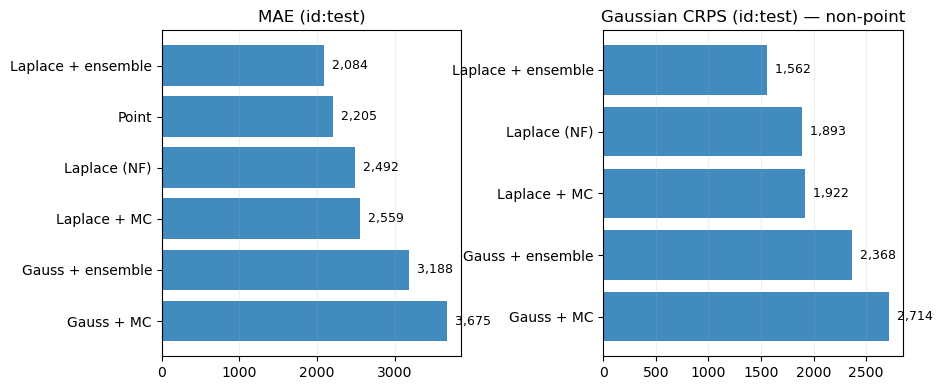

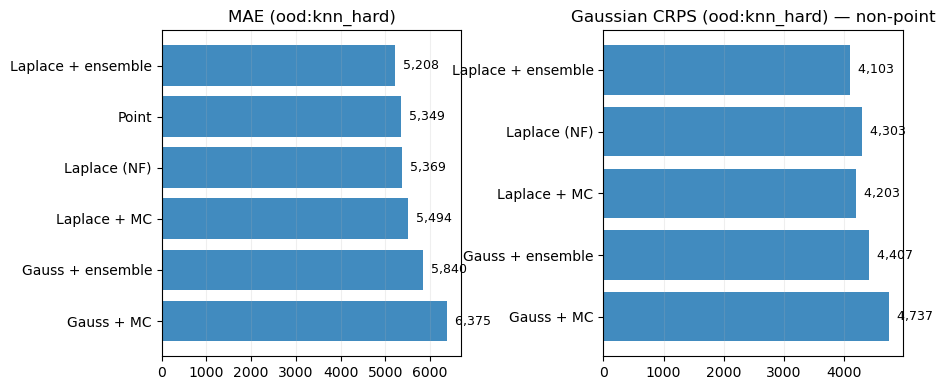

In [99]:
# --- 2) Predictive quality / basic stats: MAE + CRPS (ID-test + OOD-test) ---
# - Point: MAE only
# - Others: MAE + Gaussian CRPS using σ_tot (raw or calibrated)
# - Handles missing methods / missing OOD evals gracefully.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
INCLUDE_OOD = True
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]; mu = mu[mask]; sigma = np.clip(sigma[mask], 1e-8, None)
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def _sigma_total(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
        return np.asarray(sT, float)

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    return np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))

def _load_eval(spec: MethodSpec, dataset: str, ood_label: str | None = None) -> pd.DataFrame:
    if dataset == "id:test":
        if spec.kind == "nf":
            return load_id_nf(RUN_DIRS[spec.key])
        if spec.kind in {"regression", "ensemble", "dido"}:
            return method_id_test_frame(spec)
        raise ValueError(f"Unsupported kind for ID:test: {spec.kind}")

    if dataset.startswith("ood:"):
        if ood_label is None:
            raise ValueError("ood_label required for OOD")
        if spec.kind == "nf":
            return load_ood_nf(RUN_DIRS[spec.key], ood_label)
        if spec.kind in {"regression", "ensemble", "dido"}:
            return method_ood_frame(spec, ood_label)
        raise ValueError(f"Unsupported kind for OOD: {spec.kind}")

    raise ValueError(f"Unknown dataset={dataset!r}")

# Use focused list if available, else fall back
if "METHODS_FOCUSED" in globals():
    SPECS = list(METHODS_FOCUSED)
else:
    SPECS = list(METHODS_CORE)

datasets = [("id:test", None)]
if INCLUDE_OOD:
    datasets += [(f"ood:{lbl}", lbl) for lbl in OOD_LABELS_LOCAL]

rows = []
for dataset_name, ood_label in datasets:
    for spec in SPECS:
        # Skip DIDO for predictive quality unless it has mu/y_true (usually it's score-only)
        if spec.kind == "dido":
            continue

        try:
            df = _load_eval(spec, dataset_name, ood_label)
        except Exception as e:
            print(f"[skip] {spec.label} / {dataset_name}: {type(e).__name__}: {e}")
            continue

        y = df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float)
        mu = df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)
        mask_mu = np.isfinite(y) & np.isfinite(mu)
        mae = float(np.mean(np.abs(y[mask_mu] - mu[mask_mu]))) if np.any(mask_mu) else float("nan")

        if spec.head_type == "point":
            rows.append(
                {
                    "dataset": dataset_name,
                    "method": spec.label,
                    "n": int(np.sum(mask_mu)),
                    "MAE": mae,
                    "CRPS": np.nan,
                    "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
                }
            )
            continue

        sT = _sigma_total(spec, df)
        crps = gaussian_crps_mean(y, mu, sT)

        rows.append(
            {
                "dataset": dataset_name,
                "method": spec.label,
                "head_type": spec.head_type,
                "aleatoric_source": spec.aleatoric_source,
                "epistemic_source": spec.epistemic_source,
                "n": int(np.sum(mask_mu)),
                "MAE": mae,
                "CRPS": crps,
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            }
        )

df_metrics = pd.DataFrame(rows)
display(df_metrics.sort_values(["dataset", "MAE"], ascending=[True, True]).reset_index(drop=True))

# --- Optional: bar plots per dataset (MAE + CRPS) ---
for dataset_name, _ in datasets:
    sub = df_metrics[df_metrics["dataset"] == dataset_name].copy()
    if sub.empty:
        continue

    # order by MAE
    method_order = sub.sort_values("MAE")["method"].tolist()

    def _barh(ax, df, metric, title):
        d = df.set_index("method").reindex(method_order).reset_index()
        d = d[np.isfinite(d[metric].to_numpy(float))]
        if d.empty:
            ax.set_axis_off()
            ax.set_title(f"{title} (no data)")
            return
        y = np.arange(len(d))
        vals = d[metric].to_numpy(float)
        ax.barh(y, vals, alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(d["method"])
        ax.invert_yaxis()
        ax.set_title(title)
        ax.grid(True, axis="x", alpha=0.2)
        for yi, v in zip(y, vals):
            ax.text(v, yi, f"  {v:,.0f}", va="center", ha="left", fontsize=9)

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.5 * len(method_order))))
    _barh(axes[0], sub, "MAE", f"MAE ({dataset_name})")
    sub_prob = sub[sub["head_type"] != "point"].copy()
    _barh(axes[1], sub_prob, "CRPS", f"Gaussian CRPS ({dataset_name}) — non-point")
    fig.tight_layout()
    fig.subplots_adjust(left=0.35)
    plt.show()


[meta] loaded 126,789 unique ids from datasets/craigslist_cleaned.csv
[noise-cohort] using specs: ['Laplace (analytic)', 'Gauss (analytic)', 'Laplace (NF)', 'Gauss (NF)']


,cohort_def,method,n_cohorts,"corr(log Var(resid), log E[sA^2])",median_abs_bias
2,manufacturer+age_bucket,Laplace (NF),68,0.890163,281.516664
3,manufacturer+age_bucket,Laplace (analytic),68,0.890163,281.516777
1,manufacturer+age_bucket,Gauss (analytic),68,0.888710,551.758074
0,manufacturer+age_bucket,Gauss (NF),68,0.888710,551.758090
4,manufacturer+model,Gauss (NF),28,0.957803,697.769469
5,manufacturer+model,Gauss (analytic),28,0.957803,697.769494
7,manufacturer+model,Laplace (analytic),28,0.911952,328.726126
6,manufacturer+model,Laplace (NF),28,0.911952,328.726233


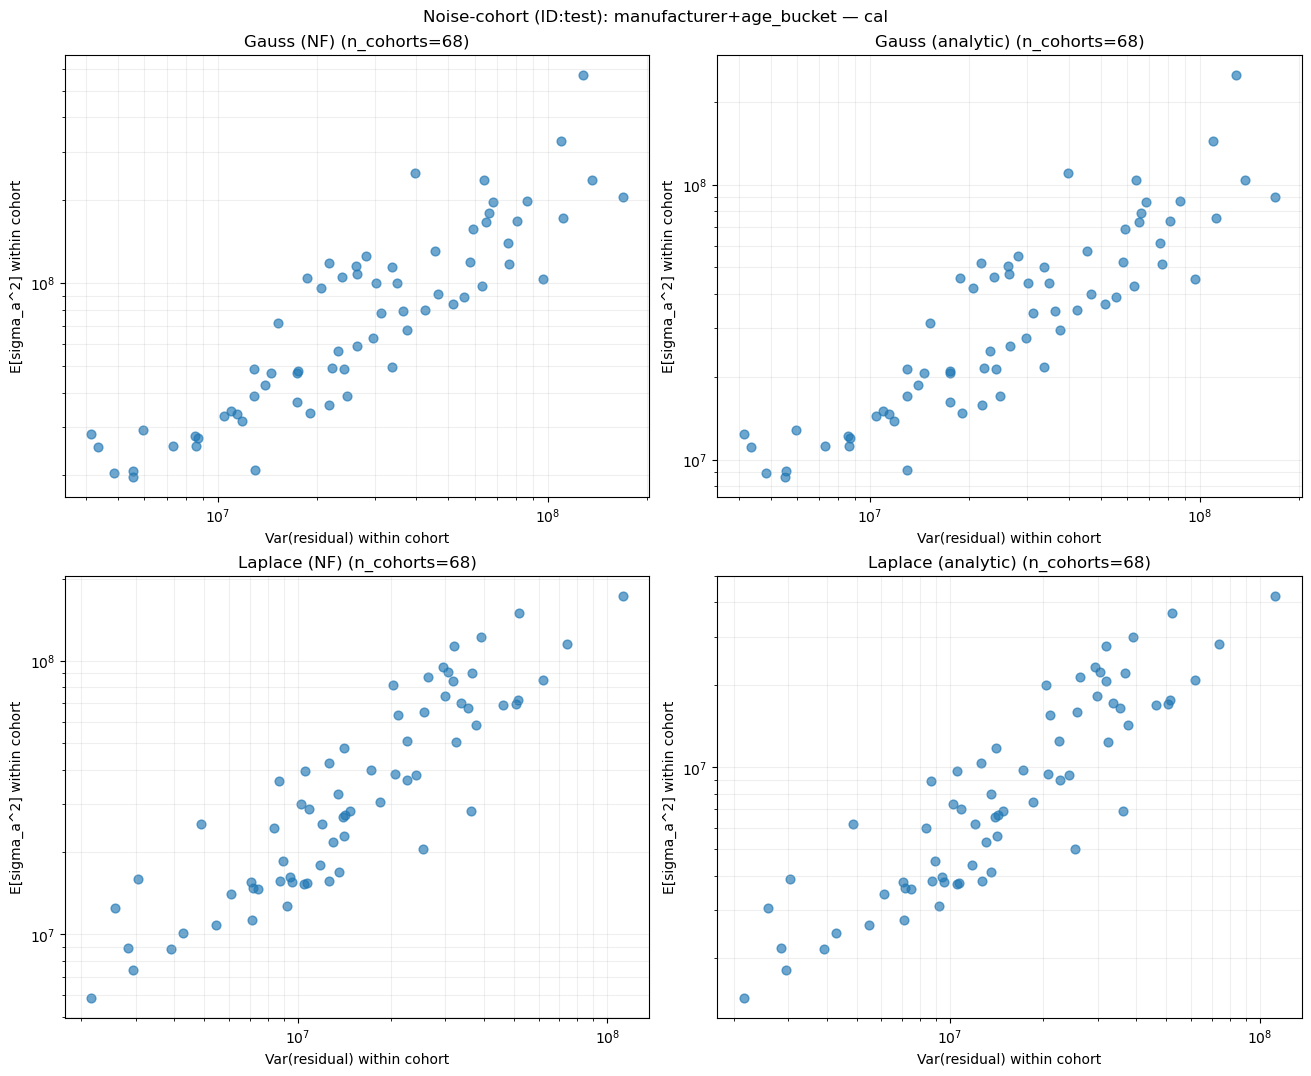

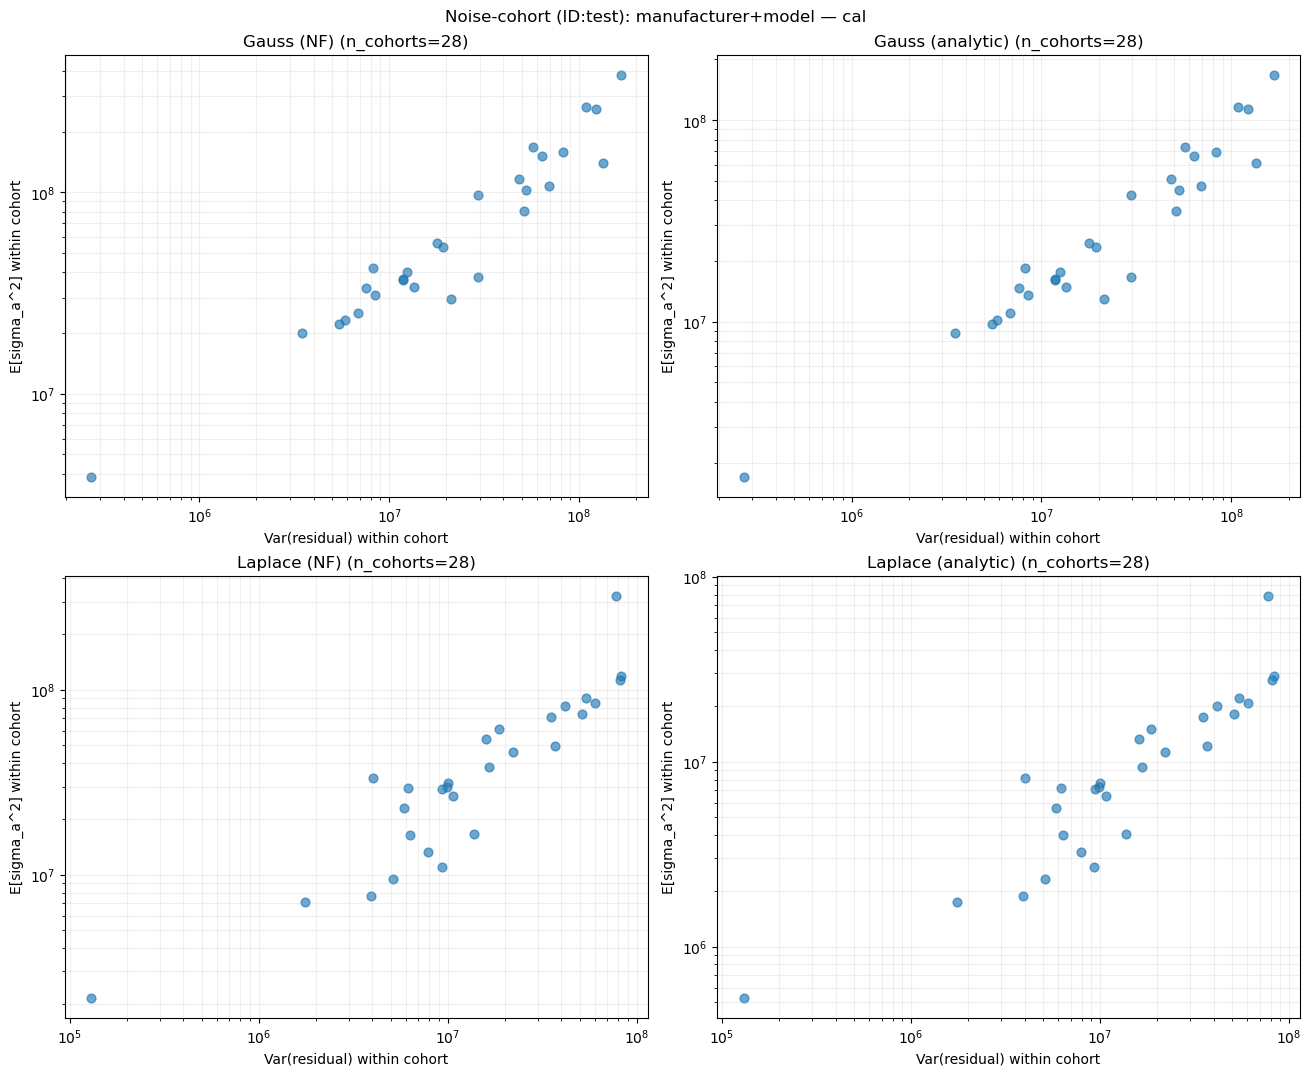

In [100]:
# --- 3) Aleatoric validity (noise-cohort) on ID:test ---
# Compares cohort noise Var(resid) vs predicted aleatoric variance E[sigma_a^2].
# Uses ONLY aleatoric-only variants:
#   - Gauss (analytic), Laplace (analytic)
#   - Laplace NF (+ Gauss NF if available)
#
# Output:
#   - Summary table per method: corr(log Var(resid), log E[sA^2]) + median_abs_bias
#   - Scatter plots (log-log), grouped by cohort_def, one subplot per method

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_CSV = "datasets/craigslist_cleaned.csv"
ID_COL = "id"

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
MIN_COHORT_N = 100

# Cohorts (good trade-off: stable + not too fragmented)
AGE_BINS = [0, 2, 4, 7, 10, 15, 25, 100]
AGE_LABELS = [f"{AGE_BINS[i]}-{AGE_BINS[i+1]}" for i in range(len(AGE_BINS) - 1)]

COHORT_DEFS = {
    "manufacturer+age_bucket": ["manufacturer", "age_bucket"],
    "manufacturer+model": ["manufacturer", "model"],
}

# ---- Load cohort metadata once ----
usecols = [ID_COL, "manufacturer", "model", "age_years"]
meta = pd.read_csv(DATASET_CSV, usecols=usecols)
meta[ID_COL] = pd.to_numeric(meta[ID_COL], errors="coerce")
meta = meta.dropna(subset=[ID_COL]).drop_duplicates(subset=[ID_COL]).copy()
meta[ID_COL] = meta[ID_COL].astype(int)

meta["age_years"] = pd.to_numeric(meta["age_years"], errors="coerce")
meta["age_bucket"] = pd.cut(meta["age_years"], bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True)

print(f"[meta] loaded {len(meta):,} unique ids from {DATASET_CSV}")

def _attach_meta(df_eval: pd.DataFrame) -> pd.DataFrame:
    if ID_COL not in df_eval.columns:
        raise KeyError(f"Eval frame missing '{ID_COL}' column; cannot join cohorts")
    out = df_eval.copy()
    out[ID_COL] = pd.to_numeric(out[ID_COL], errors="coerce")
    out = out.dropna(subset=[ID_COL])
    out[ID_COL] = out[ID_COL].astype(int)
    out = out.merge(meta[[ID_COL, "manufacturer", "model", "age_bucket"]], on=ID_COL, how="left")
    return out

def _cohort_key(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    return df[cols].astype(str).agg(" / ".join, axis=1)

def _aleatoric_sigma(spec: MethodSpec, df_eval: pd.DataFrame) -> np.ndarray:
    # returns sigma_a (not variance), aligned to df_eval rows
    sA_raw = df_eval.get("sigma_ale_raw", pd.Series(np.nan, index=df_eval.index)).to_numpy(float)

    if spec.kind == "nf":
        # NF: sigma_ale_raw is already the aleatoric sigma estimate
        return np.asarray(sA_raw, float)

    # Analytic-only: optionally apply alpha calibration (no epistemic term)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sE_zeros = np.zeros_like(sA_raw, dtype=float)
        sA, _, _ = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src="analytic",
            epi_src="none",
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_zeros,
        )
        return np.asarray(sA, float)

    return np.asarray(sA_raw, float)

def _compute_group_table(df_eval: pd.DataFrame, spec: MethodSpec, cohort_name: str, cols: list[str]) -> pd.DataFrame:
    df_eval = _attach_meta(df_eval)
    miss = [c for c in cols if c not in df_eval.columns]
    if miss:
        raise KeyError(f"Missing {miss} after join for cohort={cohort_name}")

    y = df_eval["y_true"].to_numpy(float)
    mu = df_eval["mu"].to_numpy(float)
    resid = y - mu

    sA = _aleatoric_sigma(spec, df_eval)

    tmp = pd.DataFrame(
        {
            "cohort": _cohort_key(df_eval, cols),
            "resid": resid,
            "sA2": np.square(sA),
        }
    )
    tmp = tmp[np.isfinite(tmp["resid"]) & np.isfinite(tmp["sA2"])]

    g = (
        tmp.groupby("cohort")
        .agg(
            n=("resid", "size"),
            resid_var=("resid", "var"),
            resid_bias=("resid", "mean"),
            mean_sA2=("sA2", "mean"),
        )
        .reset_index()
    )
    g = g[g["n"] >= int(MIN_COHORT_N)].copy()
    g["cohort_def"] = cohort_name
    g["method"] = spec.label
    return g

# ---- Select methods: analytic-only Gauss/Laplace + NF variants if available ----
SPECS = []
for m in (METHODS_CORE + (METHODS_AUX if "METHODS_AUX" in globals() else [])):
    if m.head_type == "point":
        continue
    # analytic-only baseline
    if m.head_type in {"gauss", "laplace"} and str(m.epistemic_source).lower() == "none" and str(m.aleatoric_source).lower() == "analytic":
        SPECS.append(m)
    # NF variants
    if str(m.kind).lower() == "nf":
        SPECS.append(m)

# De-dup by label
seen = set()
SPECS = [m for m in SPECS if (m.label not in seen and not seen.add(m.label))]

print("[noise-cohort] using specs:", [s.label for s in SPECS])

tables = []
for spec in SPECS:
    try:
        if spec.kind == "nf":
            if RUN_DIRS.get(spec.key) is None:
                raise FileNotFoundError(f"RUN_DIRS[{spec.key!r}] is None")
            df_id = load_id_nf(RUN_DIRS[spec.key])
        else:
            df_id = method_id_test_frame(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: cannot load ID test: {type(e).__name__}: {e}")
        continue

    for cohort_name, cols in COHORT_DEFS.items():
        try:
            tables.append(_compute_group_table(df_id, spec, cohort_name, cols))
        except Exception as e:
            print(f"[skip] {spec.label} / {cohort_name}: {type(e).__name__}: {e}")

if not tables:
    raise RuntimeError("No cohort tables produced. Check 'id' exists in eval CSVs and NF runs (if enabled) exist.")

df_noise = pd.concat(tables, ignore_index=True)

# ---- Summary correlations (log-log) per method + cohort_def ----
summary_rows = []
for (cohort_def, method), sub in df_noise.groupby(["cohort_def", "method"]):
    sub = sub[(sub["resid_var"] > 0) & (sub["mean_sA2"] > 0)].copy()
    if len(sub) < 5:
        continue
    x = np.log(sub["resid_var"].to_numpy(float))
    y = np.log(sub["mean_sA2"].to_numpy(float))
    corr = float(np.corrcoef(x, y)[0, 1]) if (np.std(x) > 0 and np.std(y) > 0) else float("nan")
    summary_rows.append(
        {
            "cohort_def": cohort_def,
            "method": method,
            "n_cohorts": int(len(sub)),
            "corr(log Var(resid), log E[sA^2])": corr,
            "median_abs_bias": float(np.median(np.abs(sub["resid_bias"].to_numpy(float)))),
        }
    )

df_noise_summary = pd.DataFrame(summary_rows).sort_values(
    ["cohort_def", "corr(log Var(resid), log E[sA^2])"], ascending=[True, False]
)
display(df_noise_summary)

# ---- Plots: one figure per cohort_def, subplots per method ----
def _plot_grid_for_cohort(cohort_def: str, df_all: pd.DataFrame):
    methods_here = sorted(df_all["method"].unique().tolist())
    n = len(methods_here)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5.2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, method in zip(axes, methods_here):
        sub = df_all[(df_all["method"] == method) & (df_all["resid_var"] > 0) & (df_all["mean_sA2"] > 0)].copy()
        if sub.empty:
            ax.set_axis_off()
            continue

        ax.scatter(sub["resid_var"], sub["mean_sA2"], s=40, alpha=0.65)  # constant marker size
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Var(residual) within cohort")
        ax.set_ylabel("E[sigma_a^2] within cohort")
        ax.set_title(f"{method} (n_cohorts={len(sub)})")
        ax.grid(True, which="both", alpha=0.2)

    for ax in axes[n:]:
        ax.set_axis_off()

    fig.suptitle(
        f"Noise-cohort (ID:test): {cohort_def} — "
        f"{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
        y=1.02,
    )
    plt.show()

for cohort_def, sub in df_noise.groupby("cohort_def"):
    _plot_grid_for_cohort(cohort_def, sub)


,ood_label,method,signal,n_id,n_ood,n_used,auroc,auprc,use_calibrated
0,knn_hard,Gauss + MC,Utot,25358,1585,26943,0.683881,0.118678,True
1,knn_hard,Laplace + MC,Utot,25358,1585,26943,0.681852,0.112862,True
2,knn_hard,Laplace + ensemble,Utot,25358,1585,26943,0.645590,0.095384,True
3,knn_hard,Laplace + DIDO,dido_strength_raw,25358,1585,26943,0.643659,0.096648,False
4,knn_hard,Laplace + MC,Ue,25358,1585,26943,0.638926,0.090796,True
5,knn_hard,Laplace + ensemble,Ue,25358,1585,26943,0.632286,0.096443,True
6,knn_hard,Gauss + ensemble,Utot,25358,1585,26943,0.628383,0.101391,True
7,knn_hard,Gauss + ensemble,Ue,25358,1585,26943,0.563059,0.085802,True
8,knn_hard,Gauss + MC,Ue,25358,1585,26943,0.550138,0.072716,True


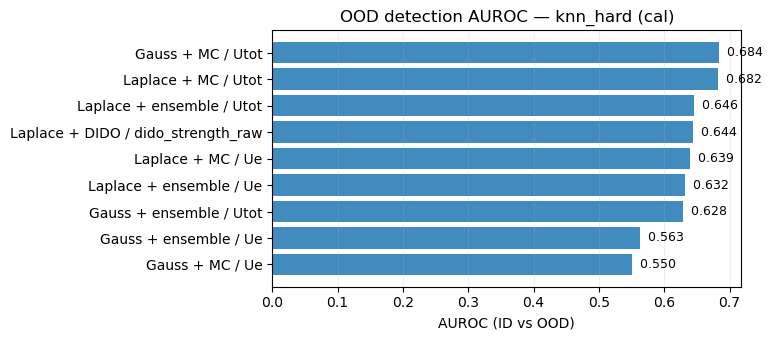

In [101]:
# --- 4) Epistemic behavior on OOD: ID vs OOD detection (AUROC/AUPRC) ---
# Compares epistemic-capable methods using Ue and Utot, and includes DIDO (if available).
# Robust to missing methods/evals and to sigma naming (sigma_*_raw vs sigma_*_orig).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

SIGMAS_SIGNALS = ["Ue", "Utot"]

# ---- DIDO toggle ----
INCLUDE_DIDO = True
DIDO_SIGNAL = "dido_strength_raw"  # "auto" or one of: "dido_entropy_raw" | "dido_vacuity_raw" | "dido_strength_raw"
DIDO_CANDIDATES = ["dido_entropy_raw", "dido_vacuity_raw", "dido_strength_raw"]
DIDO_ALLOW_FLIP = True  # if True, also try -score and keep the better AUROC (direction can be arbitrary)

def _label_candidates(label: str) -> list[str]:
    c = [label]
    if label.endswith("_hard"):
        c.append(label.replace("_hard", ""))  # e.g. knn_hard -> knn
    return list(dict.fromkeys(c))

def _ood_metrics(y_true_bin: np.ndarray, score: np.ndarray):
    y_true_bin = np.asarray(y_true_bin, int)
    score = np.asarray(score, float)
    mask = np.isfinite(score) & np.isfinite(y_true_bin)
    if not np.any(mask):
        return float("nan"), float("nan"), 0
    y = y_true_bin[mask]
    s = score[mask]
    if len(np.unique(y)) < 2:
        return float("nan"), float("nan"), int(mask.sum())
    return float(roc_auc_score(y, s)), float(average_precision_score(y, s)), int(mask.sum())

def _get_col_as_float(df: pd.DataFrame, names: list[str]) -> np.ndarray:
    for n in names:
        if n in df.columns:
            return pd.to_numeric(df[n], errors="coerce").to_numpy(float)
    return np.full(len(df), np.nan, dtype=float)

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = _get_col_as_float(df, ["sigma_ale_raw", "sigma_ale_orig"])
    sE_raw = _get_col_as_float(df, ["sigma_epi_raw", "sigma_epi_orig"])

    miss_epi = ~np.isfinite(sE_raw)
    sE0 = np.nan_to_num(sE_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE0,  # keep totals defined even when epi missing
        )
        sA = np.asarray(sA, float)
        sE = np.asarray(sE, float)
        sT = np.asarray(sT, float)
        # IMPORTANT: keep missing epi as NaN so Ue metrics don't collapse to 0/garbage
        sE[miss_epi] = np.nan
        return sA, sE, sT

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)  # keep NaNs for Ue
    sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _load_id_for_spec(spec: MethodSpec) -> pd.DataFrame:
    if spec.kind == "nf":
        return load_id_nf(RUN_DIRS[spec.key])
    if spec.kind in {"regression", "ensemble"}:
        return method_id_test_frame(spec)
    raise ValueError(f"Unsupported spec.kind={spec.kind} for ID load")

def _load_ood_for_spec(spec: MethodSpec, ood_label: str) -> pd.DataFrame:
    last_err = None
    for lab in _label_candidates(ood_label):
        try:
            if spec.kind == "nf":
                return load_ood_nf(RUN_DIRS[spec.key], lab)
            if spec.kind in {"regression", "ensemble"}:
                return method_ood_frame(spec, lab)
            raise ValueError(f"Unsupported spec.kind={spec.kind} for OOD load")
        except Exception as e:
            last_err = e
    raise last_err

# Sigma-based epistemic methods (MC + ensemble)
if "METHODS_FOCUSED" in globals():
    base_specs = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() in {"mc", "ensemble"}]
else:
    base_specs = [m for m in METHODS_CORE if str(m.epistemic_source).lower() in {"mc", "ensemble"}]

rows = []

for ood_label in OOD_LABELS_LOCAL:
    # ---- Sigma-based methods: evaluate Ue and Utot ----
    for spec in base_specs:
        try:
            df_id = _load_id_for_spec(spec)
            df_ood = _load_ood_for_spec(spec, ood_label)
        except Exception as e:
            print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        df_id = df_id.copy()
        df_ood = df_ood.copy()
        df_id["is_ood"] = 0
        df_ood["is_ood"] = 1
        df_all = pd.concat([df_id, df_ood], ignore_index=True)
        ybin = df_all["is_ood"].to_numpy(int)

        sA, sE, sT = _sigmas(spec, df_all)

        # Helpful diagnostic: if Ue missing a lot on OOD, AUROC(Ue) can be NaN/near-0
        sE_id = sE[: len(df_id)]
        sE_ood = sE[len(df_id) :]
        miss_id = float(np.mean(~np.isfinite(sE_id)))
        miss_ood = float(np.mean(~np.isfinite(sE_ood)))
        if miss_ood > 0.25:
            print(f"[warn] {spec.label} Ue missing frac (id={miss_id:.2f}, ood={miss_ood:.2f}) for ood={ood_label}")

        sig_map = {"Ue": sE, "Utot": sT}
        for sig_name in SIGMAS_SIGNALS:
            auroc, auprc, n_used = _ood_metrics(ybin, sig_map[sig_name])
            rows.append(
                {
                    "ood_label": ood_label,
                    "method": spec.label,
                    "signal": sig_name,
                    "n_id": int(len(df_id)),
                    "n_ood": int(len(df_ood)),
                    "n_used": n_used,
                    "auroc": auroc,
                    "auprc": auprc,
                    "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
                }
            )

    # ---- DIDO competitor: one chosen signal (or auto) ----
    if INCLUDE_DIDO and "RUN_DIRS" in globals() and RUN_DIRS.get("dido_lpl") is not None:
        try:
            df_id_d = load_id_dido(RUN_DIRS["dido_lpl"]).copy()
            df_ood_d = None
            last = None
            for lab in _label_candidates(ood_label):
                try:
                    df_ood_d = load_ood_dido(RUN_DIRS["dido_lpl"], lab).copy()
                    break
                except Exception as e:
                    last = e
            if df_ood_d is None:
                raise last
        except Exception as e:
            print(f"[skip] Laplace DIDO / ood={ood_label}: {type(e).__name__}: {e}")
        else:
            df_id_d["is_ood"] = 0
            df_ood_d["is_ood"] = 1
            df_all_d = pd.concat([df_id_d, df_ood_d], ignore_index=True)
            ybin = df_all_d["is_ood"].to_numpy(int)

            # Choose which dido column(s) to evaluate
            if str(DIDO_SIGNAL).lower() == "auto":
                dido_cols = [c for c in DIDO_CANDIDATES if c in df_all_d.columns]
            else:
                dido_cols = [str(DIDO_SIGNAL)] if str(DIDO_SIGNAL) in df_all_d.columns else []

            if not dido_cols:
                print(f"[skip] Laplace DIDO / ood={ood_label}: dido column not found (DIDO_SIGNAL={DIDO_SIGNAL!r})")
            else:
                best = None  # (auroc, auprc, col, flipped, n_used)
                for col in dido_cols:
                    score = pd.to_numeric(df_all_d[col], errors="coerce").to_numpy(float)
                    auroc, auprc, n_used = _ood_metrics(ybin, score)
                    flipped = False
                    if DIDO_ALLOW_FLIP:
                        auroc_neg, auprc_neg, _ = _ood_metrics(ybin, -score)
                        if np.isfinite(auroc_neg) and (not np.isfinite(auroc) or auroc_neg > auroc):
                            auroc, auprc, flipped = auroc_neg, auprc_neg, True

                    cand = (float(auroc), float(auprc), col, flipped, int(n_used))
                    if best is None or (np.isfinite(cand[0]) and (not np.isfinite(best[0]) or cand[0] > best[0])):
                        best = cand

                if best is not None:
                    auroc, auprc, col, flipped, n_used = best
                    rows.append(
                        {
                            "ood_label": ood_label,
                            "method": "Laplace + DIDO",
                            "signal": col + (" (flipped)" if flipped else ""),
                            "n_id": int(len(df_id_d)),
                            "n_ood": int(len(df_ood_d)),
                            "n_used": int(n_used),
                            "auroc": auroc,
                            "auprc": auprc,
                            "use_calibrated": False,
                        }
                    )

df_ooddet = pd.DataFrame(rows)
display(df_ooddet.sort_values(["ood_label", "auroc"], ascending=[True, False]).reset_index(drop=True))

# --- Bar plot (AUROC) per OOD label ---
for ood_label in OOD_LABELS_LOCAL:
    sub = df_ooddet[df_ooddet["ood_label"] == ood_label].copy()
    sub = sub[np.isfinite(sub["auroc"].to_numpy(float))].copy()
    if sub.empty:
        continue
    sub["name"] = sub["method"] + " / " + sub["signal"]
    sub = sub.sort_values("auroc", ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(sub))))
    y = np.arange(len(sub))
    vals = sub["auroc"].to_numpy(float)

    ax.barh(y, vals, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["name"].tolist())
    ax.set_xlabel("AUROC (ID vs OOD)")
    ax.set_title(f"OOD detection AUROC — {ood_label} ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})")
    ax.grid(True, axis="x", alpha=0.2)
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.3f}", va="center", ha="left", fontsize=9)
    fig.tight_layout()
    fig.subplots_adjust(left=0.45)
    plt.show()


,ood_label,method,signal,n_id,n_ood,n_used,auroc,auprc,use_calibrated
0,knn_hard,Laplace + MC,Ua,25358,1585,26943,0.699940,0.122105,True
1,knn_hard,Gauss + MC,Ua,25358,1585,26943,0.690995,0.121215,True
2,knn_hard,Gauss + MC,Utot,25358,1585,26943,0.683881,0.118678,True
3,knn_hard,Laplace + MC,Utot,25358,1585,26943,0.681852,0.112862,True
4,knn_hard,Laplace + ensemble,Ua,25358,1585,26943,0.645590,0.095384,True
5,knn_hard,Laplace + ensemble,Utot,25358,1585,26943,0.645590,0.095384,True
6,knn_hard,Laplace + DIDO,dido_strength_raw,25358,1585,26943,0.643659,0.096648,False
7,knn_hard,Laplace + MC,Ue,25358,1585,26943,0.638926,0.090796,True
8,knn_hard,Laplace + ensemble,Ue,25358,1585,26943,0.632286,0.096443,True
9,knn_hard,Gauss + ensemble,Ua,25358,1585,26943,0.628383,0.101391,True


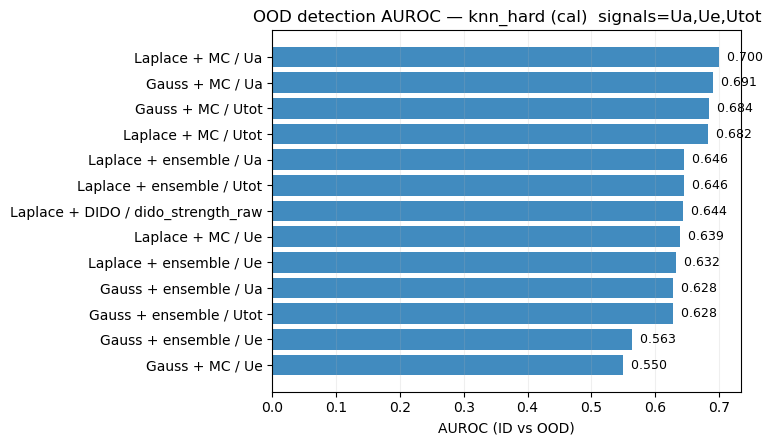

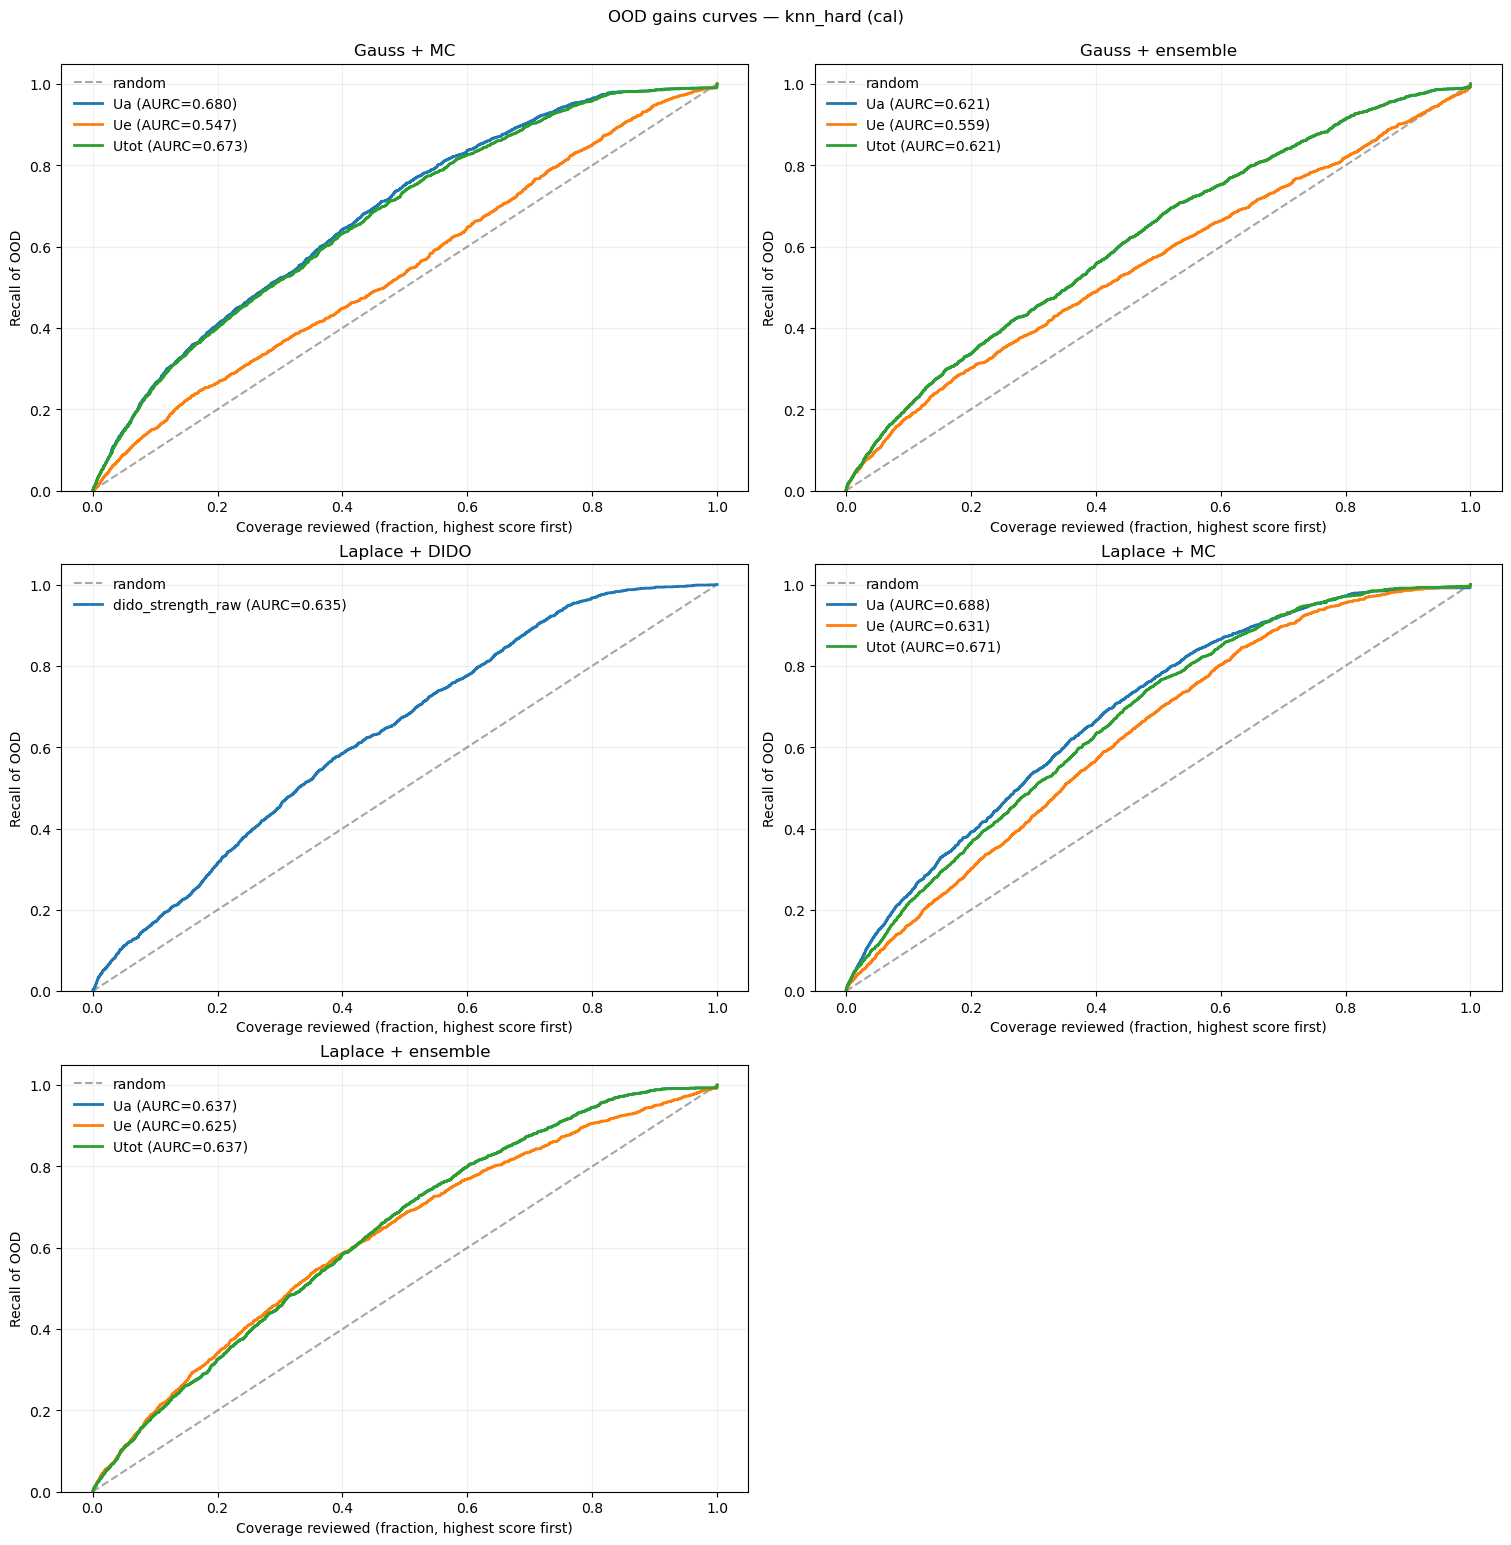

In [102]:
# --- 4) Epistemic behavior on OOD: ID vs OOD detection (AUROC/AUPRC) + gains curves ---
# - AUROC/AUPRC table + bar plot (as before)
# - NEW: gains curves (recall of OOD vs coverage reviewed), one subplot per method
# - Supports any combination of {"Ua","Ue","Utot"} via SELECT_SIGNALS
# - Includes DIDO (if available) as an alternative OOD score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# Choose any subset of {"Ua","Ue","Utot"}
SELECT_SIGNALS = ["Ua", "Ue", "Utot"]  # e.g. ["Ua"], ["Ue"], ["Utot"], ["Ua","Utot"], ["Ua","Ue","Utot"]

# ---- DIDO toggle ----
INCLUDE_DIDO = True
DIDO_SIGNAL = "dido_strength_raw"  # "auto" or: "dido_entropy_raw" | "dido_vacuity_raw" | "dido_strength_raw"
DIDO_CANDIDATES = ["dido_entropy_raw", "dido_vacuity_raw", "dido_strength_raw"]
DIDO_ALLOW_FLIP = True  # try -score too, keep better AUROC (direction can be arbitrary)

def _label_candidates(label: str) -> list[str]:
    c = [label]
    if label.endswith("_hard"):
        c.append(label.replace("_hard", ""))  # e.g. knn_hard -> knn (ensembles)
    return list(dict.fromkeys(c))

def _ood_metrics(y_true_bin: np.ndarray, score: np.ndarray):
    y_true_bin = np.asarray(y_true_bin, int)
    score = np.asarray(score, float)
    mask = np.isfinite(score) & np.isfinite(y_true_bin)
    if not np.any(mask):
        return float("nan"), float("nan"), 0
    y = y_true_bin[mask]
    s = score[mask]
    if len(np.unique(y)) < 2:
        return float("nan"), float("nan"), int(mask.sum())
    return float(roc_auc_score(y, s)), float(average_precision_score(y, s)), int(mask.sum())

def _gains_curve(y_ood: np.ndarray, score: np.ndarray):
    y_ood = np.asarray(y_ood, int)
    score = np.asarray(score, float)
    m = np.isfinite(score) & np.isfinite(y_ood)
    if not np.any(m):
        return None
    y = y_ood[m]
    s = score[m]
    if len(np.unique(y)) < 2:
        return None
    order = np.argsort(-s, kind="mergesort")  # highest score first
    y = y[order]
    total_pos = float(np.sum(y))
    if total_pos <= 0:
        return None
    cum_pos = np.cumsum(y).astype(float)
    recall = cum_pos / total_pos
    coverage = (np.arange(1, len(y) + 1) / float(len(y))).astype(float)
    aurc = float(np.trapezoid(recall, coverage))
    return coverage, recall, aurc

def _get_col_as_float(df: pd.DataFrame, names: list[str]) -> np.ndarray:
    for n in names:
        if n in df.columns:
            return pd.to_numeric(df[n], errors="coerce").to_numpy(float)
    return np.full(len(df), np.nan, dtype=float)

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = _get_col_as_float(df, ["sigma_ale_raw", "sigma_ale_orig"])
    sE_raw = _get_col_as_float(df, ["sigma_epi_raw", "sigma_epi_orig"])

    miss_epi = ~np.isfinite(sE_raw)
    sE0 = np.nan_to_num(sE_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE0,  # keep totals defined even when epi missing
        )
        sA = np.asarray(sA, float)
        sE = np.asarray(sE, float)
        sT = np.asarray(sT, float)
        sE[miss_epi] = np.nan  # keep missing epi as NaN for Ue-specific metrics
        return sA, sE, sT

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)  # keep NaNs for Ue
    sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _load_id_for_spec(spec: MethodSpec) -> pd.DataFrame:
    if spec.kind == "nf":
        return load_id_nf(RUN_DIRS[spec.key])
    if spec.kind in {"regression", "ensemble"}:
        return method_id_test_frame(spec)
    raise ValueError(f"Unsupported spec.kind={spec.kind} for ID load")

def _load_ood_for_spec(spec: MethodSpec, ood_label: str) -> pd.DataFrame:
    last_err = None
    for lab in _label_candidates(ood_label):
        try:
            if spec.kind == "nf":
                return load_ood_nf(RUN_DIRS[spec.key], lab)
            if spec.kind in {"regression", "ensemble"}:
                return method_ood_frame(spec, lab)
            raise ValueError(f"Unsupported spec.kind={spec.kind} for OOD load")
        except Exception as e:
            last_err = e
    raise last_err

# Sigma-based epistemic methods (MC + ensemble)
if "METHODS_FOCUSED" in globals():
    base_specs = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() in {"mc", "ensemble"}]
else:
    base_specs = [m for m in METHODS_CORE if str(m.epistemic_source).lower() in {"mc", "ensemble"}]

# Validate signals
SELECT_SIGNALS = [s.strip() for s in SELECT_SIGNALS]
allowed = {"Ua", "Ue", "Utot"}
bad = [s for s in SELECT_SIGNALS if s not in allowed]
if bad:
    raise ValueError(f"Unknown signals in SELECT_SIGNALS={bad}; allowed={sorted(allowed)}")

rows = []
gains_rows = []  # stores gains curves for 2nd plot

for ood_label in OOD_LABELS_LOCAL:
    # ---- Sigma-based methods ----
    for spec in base_specs:
        try:
            df_id = _load_id_for_spec(spec)
            df_ood = _load_ood_for_spec(spec, ood_label)
        except Exception as e:
            print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        df_id = df_id.copy()
        df_ood = df_ood.copy()
        df_id["is_ood"] = 0
        df_ood["is_ood"] = 1
        df_all = pd.concat([df_id, df_ood], ignore_index=True)
        ybin = df_all["is_ood"].to_numpy(int)

        sA, sE, sT = _sigmas(spec, df_all)
        sig_map = {"Ua": sA, "Ue": sE, "Utot": sT}

        if "Ue" in SELECT_SIGNALS:
            sE_id = sE[: len(df_id)]
            sE_ood = sE[len(df_id) :]
            miss_id = float(np.mean(~np.isfinite(sE_id)))
            miss_ood = float(np.mean(~np.isfinite(sE_ood)))
            if miss_ood > 0.25:
                print(f"[warn] {spec.label} Ue missing frac (id={miss_id:.2f}, ood={miss_ood:.2f}) for ood={ood_label}")

        for sig_name in SELECT_SIGNALS:
            score = sig_map[sig_name]
            auroc, auprc, n_used = _ood_metrics(ybin, score)
            rows.append(
                {
                    "ood_label": ood_label,
                    "method": spec.label,
                    "signal": sig_name,
                    "n_id": int(len(df_id)),
                    "n_ood": int(len(df_ood)),
                    "n_used": n_used,
                    "auroc": auroc,
                    "auprc": auprc,
                    "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
                }
            )

            g = _gains_curve(ybin, score)
            if g is not None:
                cov, rec, aurc = g
                gains_rows.append(
                    {
                        "ood_label": ood_label,
                        "method": spec.label,
                        "signal": sig_name,
                        "coverage": cov,
                        "recall": rec,
                        "aurc": aurc,
                    }
                )

    # ---- DIDO competitor (if evaluated) ----
    if INCLUDE_DIDO and "RUN_DIRS" in globals() and RUN_DIRS.get("dido_lpl") is not None:
        try:
            df_id_d = load_id_dido(RUN_DIRS["dido_lpl"]).copy()
            df_ood_d = None
            last = None
            for lab in _label_candidates(ood_label):
                try:
                    df_ood_d = load_ood_dido(RUN_DIRS["dido_lpl"], lab).copy()
                    break
                except Exception as e:
                    last = e
            if df_ood_d is None:
                raise last
        except Exception as e:
            print(f"[skip] Laplace DIDO / ood={ood_label}: {type(e).__name__}: {e}")
        else:
            df_id_d["is_ood"] = 0
            df_ood_d["is_ood"] = 1
            df_all_d = pd.concat([df_id_d, df_ood_d], ignore_index=True)
            ybin = df_all_d["is_ood"].to_numpy(int)

            if str(DIDO_SIGNAL).lower() == "auto":
                dido_cols = [c for c in DIDO_CANDIDATES if c in df_all_d.columns]
            else:
                dido_cols = [str(DIDO_SIGNAL)] if str(DIDO_SIGNAL) in df_all_d.columns else []

            if not dido_cols:
                print(f"[skip] Laplace DIDO / ood={ood_label}: dido column not found (DIDO_SIGNAL={DIDO_SIGNAL!r})")
            else:
                best = None  # (auroc, auprc, col, flipped, n_used, score_used)
                for col in dido_cols:
                    score0 = pd.to_numeric(df_all_d[col], errors="coerce").to_numpy(float)
                    auroc, auprc, n_used = _ood_metrics(ybin, score0)
                    flipped = False
                    score_used = score0
                    if DIDO_ALLOW_FLIP:
                        auroc_neg, auprc_neg, _ = _ood_metrics(ybin, -score0)
                        if np.isfinite(auroc_neg) and (not np.isfinite(auroc) or auroc_neg > auroc):
                            auroc, auprc, flipped = auroc_neg, auprc_neg, True
                            score_used = -score0

                    cand = (float(auroc), float(auprc), col, flipped, int(n_used), score_used)
                    if best is None or (np.isfinite(cand[0]) and (not np.isfinite(best[0]) or cand[0] > best[0])):
                        best = cand

                if best is not None:
                    auroc, auprc, col, flipped, n_used, score_used = best
                    sig_name = col + (" (flipped)" if flipped else "")
                    rows.append(
                        {
                            "ood_label": ood_label,
                            "method": "Laplace + DIDO",
                            "signal": sig_name,
                            "n_id": int(len(df_id_d)),
                            "n_ood": int(len(df_ood_d)),
                            "n_used": int(n_used),
                            "auroc": auroc,
                            "auprc": auprc,
                            "use_calibrated": False,
                        }
                    )
                    g = _gains_curve(ybin, score_used)
                    if g is not None:
                        cov, rec, aurc = g
                        gains_rows.append(
                            {
                                "ood_label": ood_label,
                                "method": "Laplace + DIDO",
                                "signal": sig_name,
                                "coverage": cov,
                                "recall": rec,
                                "aurc": aurc,
                            }
                        )

df_ooddet = pd.DataFrame(rows)
display(df_ooddet.sort_values(["ood_label", "auroc"], ascending=[True, False]).reset_index(drop=True))

# --- 1) Bar plot (AUROC) per OOD label ---
for ood_label in OOD_LABELS_LOCAL:
    sub = df_ooddet[df_ooddet["ood_label"] == ood_label].copy()
    sub = sub[np.isfinite(sub["auroc"].to_numpy(float))].copy()
    if sub.empty:
        continue
    sub["name"] = sub["method"] + " / " + sub["signal"]
    sub = sub.sort_values("auroc", ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(sub))))
    y = np.arange(len(sub))
    vals = sub["auroc"].to_numpy(float)

    ax.barh(y, vals, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["name"].tolist())
    ax.set_xlabel("AUROC (ID vs OOD)")
    ax.set_title(
        f"OOD detection AUROC — {ood_label} ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})"
        + f"  signals={','.join(SELECT_SIGNALS)}"
    )
    ax.grid(True, axis="x", alpha=0.2)
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.3f}", va="center", ha="left", fontsize=9)
    fig.tight_layout()
    fig.subplots_adjust(left=0.45)
    plt.show()

# --- 2) Gains curves: recall(OOD) vs coverage reviewed (one subplot per method) ---
df_gains = pd.DataFrame(
    [
        {k: v for k, v in r.items() if k not in {"coverage", "recall"}}
        for r in gains_rows
    ]
)
# keep arrays in a dict keyed by (ood_label, method, signal)
_gains_map = {(r["ood_label"], r["method"], r["signal"]): (r["coverage"], r["recall"], r["aurc"]) for r in gains_rows}

for ood_label in OOD_LABELS_LOCAL:
    methods = sorted({m for (ol, m, _s) in _gains_map.keys() if ol == ood_label})
    if not methods:
        continue

    n = len(methods)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 5.0 * nrows), sharex=False, sharey=False, constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, method in zip(axes, methods):
        ax.plot([0, 1], [0, 1], "k--", alpha=0.35, label="random")

        # plot any signal curves we have for this method
        sigs_here = [sig for (ol, m, sig) in _gains_map.keys() if (ol == ood_label and m == method)]
        for sig in sigs_here:
            cov, rec, aurc = _gains_map[(ood_label, method, sig)]
            ax.plot(cov, rec, lw=2, label=f"{sig} (AURC={aurc:.3f})")

        ax.set_title(method)
        ax.set_xlabel("Coverage reviewed (fraction, highest score first)")
        ax.set_ylabel("Recall of OOD")
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)

    for ax in axes[len(methods):]:
        ax.set_axis_off()

    fig.suptitle(
        f"OOD gains curves — {ood_label} ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})",
        y=1.02,
    )
    plt.show()


[skip] Laplace + DIDO: ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


,method,signal,auroc
0,Laplace + ensemble,Utot,0.917054
1,Laplace + ensemble,Ua,0.917054
2,Laplace + ensemble,Ue,0.906918
3,Gauss + ensemble,Utot,0.902832
4,Gauss + ensemble,Ua,0.902832
5,Laplace + MC,Ua,0.899374
6,Laplace (NF),Ua,0.891732
7,Laplace + MC,Utot,0.891367
8,Gauss + MC,Utot,0.884264
9,Gauss + MC,Ua,0.883860


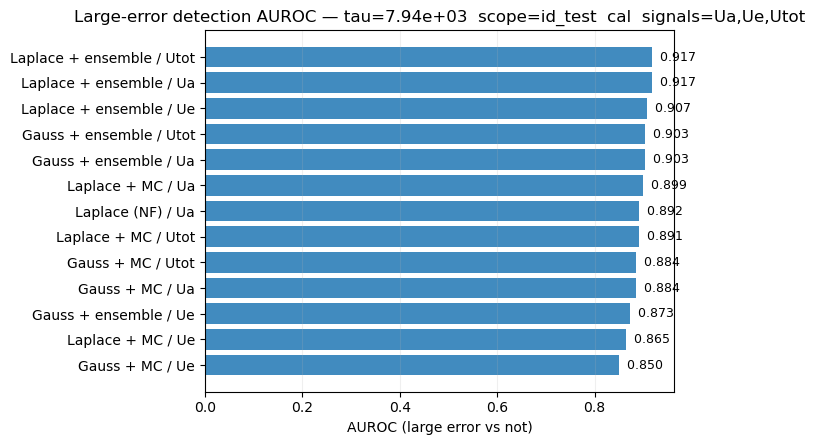

In [103]:
# --- Large-error detection AUROC (like OOD AUROC bar chart) ---
# Same as before, but bars are ALL blue and legend is removed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
EVAL_SCOPE = "id_test"  # "id_test" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

SELECT_SIGNALS = ["Ua", "Ue", "Utot"]  # any subset of ["Ua","Ue","Utot"]
INCLUDE_ALEATORIC_ONLY = False        # include analytic-only methods (Ua only)?
INCLUDE_NF = True                     # include NF methods (Ua only) if present?

try:
    TAU = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e


def _get_col_as_float(df: pd.DataFrame, names: list[str]) -> np.ndarray:
    for n in names:
        if n in df.columns:
            return pd.to_numeric(df[n], errors="coerce").to_numpy(float)
    return np.full(len(df), np.nan, dtype=float)


def _is_nf(spec: "MethodSpec") -> bool:
    return str(getattr(spec, "kind", "")).lower() == "nf" or str(getattr(spec, "aleatoric_source", "")).lower() == "nf"


def _has_epistemic(spec: "MethodSpec") -> bool:
    return str(getattr(spec, "epistemic_source", "")).lower() in {"mc", "ensemble", "dido"}


def _sigmas(spec: "MethodSpec", df: pd.DataFrame):
    sA_raw = _get_col_as_float(df, ["sigma_ale_raw", "sigma_ale_orig"])
    sE_raw = _get_col_as_float(df, ["sigma_epi_raw", "sigma_epi_orig"])
    sE0 = np.nan_to_num(sE_raw, nan=0.0)

    if _is_nf(spec):
        sA = np.asarray(sA_raw, float)
        sE = np.full_like(sA, np.nan, dtype=float)
        sT = sA.copy()
        return sA, sE, sT

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE0,
        )
        sA = np.asarray(sA, float)
        sE = np.asarray(sE, float)
        sT = np.asarray(sT, float)
        sE[~np.isfinite(sE_raw)] = np.nan
        return sA, sE, sT

    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT


def _auroc(y: np.ndarray, score: np.ndarray) -> float:
    y = np.asarray(y, int)
    score = np.asarray(score, float)
    m = np.isfinite(score) & np.isfinite(y)
    if not np.any(m):
        return float("nan")
    yy = y[m]
    ss = score[m]
    if np.unique(yy).size < 2:
        return float("nan")
    return float(roc_auc_score(yy, ss))


def _load_for_scope(spec: "MethodSpec") -> pd.DataFrame:
    parts = []

    if _is_nf(spec):
        df_id = load_id_nf(RUN_DIRS[spec.key]).copy()
    else:
        df_id = method_id_test_frame(spec).copy()
    df_id["dataset"] = "id:test"
    parts.append(df_id)

    if EVAL_SCOPE.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                if _is_nf(spec):
                    df_o = load_ood_nf(RUN_DIRS[spec.key], ood_label).copy()
                else:
                    df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")

    return pd.concat(parts, ignore_index=True)


# ---- Select specs ----
specs = []
if "METHODS_FOCUSED" in globals():
    pool = list(METHODS_FOCUSED)
else:
    pool = list(METHODS_CORE) + (list(METHODS_AUX) if "METHODS_AUX" in globals() else [])

for s in pool:
    if getattr(s, "head_type", None) == "point":
        continue
    if _is_nf(s):
        if INCLUDE_NF:
            specs.append(s)
        continue
    if INCLUDE_ALEATORIC_ONLY or _has_epistemic(s):
        specs.append(s)

_seen = set()
specs = [s for s in specs if not (_seen.add(s.key) or False)]

rows = []
for spec in specs:
    try:
        df_all = _load_for_scope(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    yL = (abs_err > TAU).astype(int)

    if np.nansum(yL) == 0 or np.nansum(yL) == len(yL):
        print(f"[skip] {spec.label}: degenerate large-error labels under tau={TAU:.4g}")
        continue

    sA, sE, sT = _sigmas(spec, df_all)
    sig_map = {"Ua": sA, "Ue": sE, "Utot": sT}

    for sig_name in SELECT_SIGNALS:
        if _is_nf(spec) and sig_name != "Ua":
            continue
        a = _auroc(yL, sig_map[sig_name])
        if not np.isfinite(a):
            continue
        rows.append({"method": spec.label, "signal": sig_name, "auroc": float(a)})

df_largeerr_auc = pd.DataFrame(rows).sort_values("auroc", ascending=False).reset_index(drop=True)
display(df_largeerr_auc)

if df_largeerr_auc.empty:
    print("[info] No AUROC rows to plot.")
else:
    sub = df_largeerr_auc.copy()
    sub["name"] = sub["method"] + " / " + sub["signal"]
    sub = sub.sort_values("auroc", ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(sub))))
    y = np.arange(len(sub))
    vals = sub["auroc"].to_numpy(float)

    ax.barh(y, vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["name"].tolist())
    ax.set_xlabel("AUROC (large error vs not)")
    ax.set_title(
        f"Large-error detection AUROC — tau={TAU:.3g}  scope={EVAL_SCOPE}  "
        f"{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}  signals={','.join(SELECT_SIGNALS)}"
    )
    ax.grid(True, axis="x", alpha=0.2)

    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.3f}", va="center", ha="left", fontsize=9)

    fig.tight_layout()
    fig.subplots_adjust(left=0.45)
    plt.show()


,method,n,prev_large,AUROC(Ua),AUROC(Ue),AUROC(Utot),AURC(Ua),AURC(Ue),AURC(Utot)
0,Laplace + ensemble,25358,0.046770,0.917054,0.906918,0.917054,0.897549,0.887886,0.897549
1,Laplace (NF),25358,0.061440,0.891732,NaN,0.891732,0.867663,NaN,0.867663
2,Gauss + ensemble,25358,0.087665,0.902832,0.872719,0.902832,0.867518,0.840045,0.867518
3,Laplace + MC,25358,0.065108,0.899374,0.864855,0.891367,0.873372,0.841101,0.865886
4,Gauss + MC,25358,0.109551,0.883860,0.850169,0.884264,0.841808,0.811808,0.842168
5,Gauss (NF),25358,0.108368,0.879443,NaN,0.879443,0.838324,NaN,0.838324


/tmp/ipykernel_892427/1168793635.py:221: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1], "k--", alpha=0.35, color=SIG_COLORS.get("random", "0.5"), label="random")


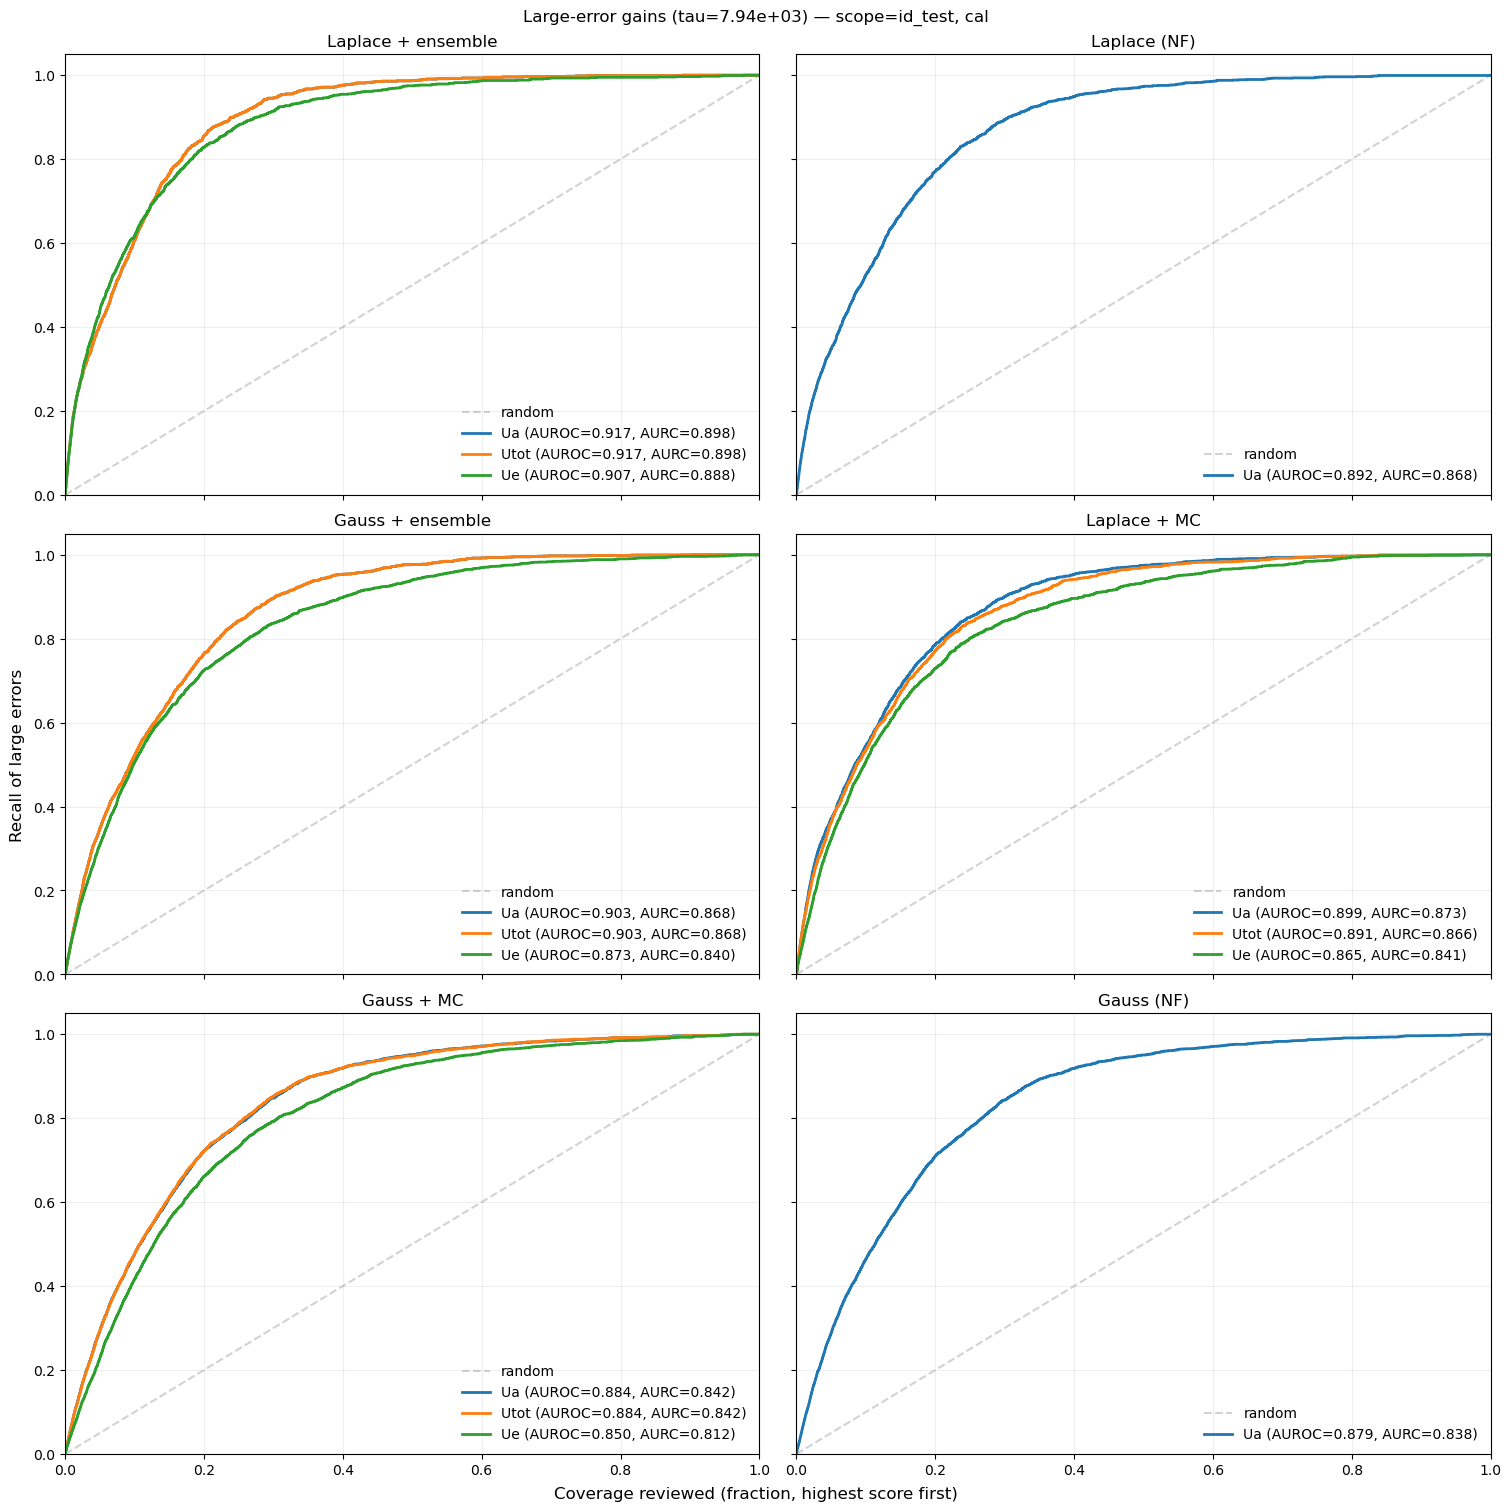

In [104]:
# --- 5) Large-error detection (gains curves + AURC) ---
# Subplots (one per method) + per-subplot default legend.
# Each line shows AUROC (ranking large errors) and AURC (gains curve area).
# UPDATED: also include Laplace/Gauss NF (if present). For NF, ONLY plot Ua (no Ue; Utot would duplicate Ua).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
EVAL_SCOPE = "id_test"  # "id_test" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# Consistent colors across plots
SIG_COLORS = globals().get(
    "SIG_COLORS",
    {"Ua": "tab:blue", "Ue": "tab:green", "Utot": "tab:orange", "random": "0.5"},
)

try:
    TAU = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e


def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    # NF: only aleatoric sigma is available; Utot = Ua; Ue = NaN
    if str(getattr(spec, "kind", "")).lower() == "nf" or str(getattr(spec, "aleatoric_source", "")).lower() == "nf":
        sA = np.asarray(sA_raw, float)
        sT = np.asarray(sA_raw, float)
        sE = np.full_like(sA, np.nan, dtype=float)
        return sA, sE, sT

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return np.asarray(sA, float), np.asarray(sE, float), np.asarray(sT, float)


def _gains(score: np.ndarray, y_large: np.ndarray):
    d = pd.DataFrame({"score": score, "y": y_large}).dropna()
    if d.empty or d["y"].nunique() < 2:
        return None
    d = d.sort_values("score", ascending=False, kind="mergesort")
    total_pos = float(d["y"].sum())
    if total_pos == 0:
        return None
    cum_pos = d["y"].cumsum().to_numpy(float)
    recall = cum_pos / total_pos
    coverage = np.arange(1, len(d) + 1) / float(len(d))
    aurc = float(np.trapezoid(recall, coverage))
    return coverage, recall, aurc


def _auroc(y: np.ndarray, score: np.ndarray) -> float:
    y = np.asarray(y, int)
    score = np.asarray(score, float)
    m = np.isfinite(score) & np.isfinite(y)
    if not np.any(m):
        return float("nan")
    yy = y[m]
    ss = score[m]
    if np.unique(yy).size < 2:
        return float("nan")
    try:
        return float(roc_auc_score(yy, ss))
    except Exception:
        return float("nan")


def _load_for_scope(spec: MethodSpec):
    parts = []

    # ID:test
    if str(getattr(spec, "kind", "")).lower() == "nf":
        df_id = load_id_nf(RUN_DIRS[spec.key]).copy()
    else:
        df_id = method_id_test_frame(spec).copy()
    df_id["dataset"] = "id:test"
    parts.append(df_id)

    # Optional OOD
    if EVAL_SCOPE.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                if str(getattr(spec, "kind", "")).lower() == "nf":
                    df_o = load_ood_nf(RUN_DIRS[spec.key], ood_label).copy()
                else:
                    df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")

    return pd.concat(parts, ignore_index=True)


# --- Specs: MC/ensemble + (optionally) NF Laplace/Gauss ---
if "METHODS_FOCUSED" in globals():
    SPECS = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() in {"mc", "ensemble"}]
else:
    SPECS = [m for m in METHODS_CORE if str(m.epistemic_source).lower() in {"mc", "ensemble"}]

# Add NF if present
if "METHODS_AUX" in globals():
    for m in METHODS_AUX:
        if str(getattr(m, "kind", "")).lower() == "nf" and str(getattr(m, "head_type", "")).lower() in {"laplace", "gauss"}:
            SPECS.append(m)

# de-dup (by key)
_seen = set()
SPECS = [m for m in SPECS if not (_seen.add(m.key) or False)]

summary_rows = []
plots = []  # {"title":..., "kind":..., "curves":{name:(cov,rec,aurc,auroc)}}

for spec in SPECS:
    try:
        df_all = _load_for_scope(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    y_large = (abs_err > TAU).astype(int)

    if np.nansum(y_large) == 0:
        print(f"[skip] {spec.label}: no large errors under tau={TAU:.4g}")
        continue

    sA, sE, sT = _sigmas(spec, df_all)

    is_nf = str(getattr(spec, "kind", "")).lower() == "nf"
    if is_nf:
        valid = np.isfinite(sA) & np.isfinite(sT) & np.isfinite(y_large)
    else:
        valid = np.isfinite(sA) & np.isfinite(sE) & np.isfinite(sT) & np.isfinite(y_large)

    if not np.any(valid):
        print(f"[skip] {spec.label}: no finite signals")
        continue

    sA, sE, sT, yL = sA[valid], sE[valid], sT[valid], y_large[valid]

    g_ua = _gains(sA, yL)
    g_ut = _gains(sT, yL)
    g_ue = None if is_nf else _gains(sE, yL)

    if g_ua is None or g_ut is None or (not is_nf and g_ue is None):
        print(f"[skip] {spec.label}: insufficient data for gains curves")
        continue

    auroc_ua = _auroc(yL, sA)
    auroc_ut = _auroc(yL, sT)
    auroc_ue = float("nan") if is_nf else _auroc(yL, sE)

    prev = float(np.mean(yL))
    summary_rows.append(
        {
            "method": spec.label,
            "n": int(len(yL)),
            "prev_large": prev,
            "AUROC(Ua)": auroc_ua,
            "AUROC(Ue)": auroc_ue,
            "AUROC(Utot)": auroc_ut,
            "AURC(Ua)": float(g_ua[2]),
            "AURC(Ue)": (float(g_ue[2]) if g_ue is not None else float("nan")),
            "AURC(Utot)": float(g_ut[2]),
        }
    )

    curves = {
        "Ua": (g_ua[0], g_ua[1], g_ua[2], auroc_ua),
        "Utot": (g_ut[0], g_ut[1], g_ut[2], auroc_ut),
    }
    if g_ue is not None:
        curves["Ue"] = (g_ue[0], g_ue[1], g_ue[2], auroc_ue)

    plots.append({"title": spec.label, "kind": str(getattr(spec, "kind", "")).lower(), "curves": curves})

df_large = pd.DataFrame(summary_rows).sort_values("AURC(Utot)", ascending=False).reset_index(drop=True)
display(df_large)

# --- Subplots: one axis per method ---
if not plots:
    print("[info] No gains curves to plot.")
else:
    order = df_large["method"].tolist()
    plots_sorted = sorted(plots, key=lambda d: order.index(d["title"]) if d["title"] in order else 10**9)

    n = len(plots_sorted)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7.5 * ncols, 5.0 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, item in zip(axes, plots_sorted):
        ax.plot([0, 1], [0, 1], "k--", alpha=0.35, color=SIG_COLORS.get("random", "0.5"), label="random")

        for name, (cov, rec, aurc, auroc) in item["curves"].items():
            # NF: only plot Ua (Ue absent, Utot duplicates Ua)
            if item.get("kind") == "nf" and name != "Ua":
                continue

            ax.plot(
                cov,
                rec,
                lw=2,
                color=SIG_COLORS.get(name, None),
                label=f"{name} (AUROC={auroc:.3f}, AURC={aurc:.3f})",
            )

        ax.set_title(item["title"])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)  # default placement ("best") per subplot

    for ax in axes[n:]:
        ax.set_axis_off()

    fig.supxlabel("Coverage reviewed (fraction, highest score first)")
    fig.supylabel("Recall of large errors")
    fig.suptitle(f"Large-error gains (tau={TAU:.3g}) — scope={EVAL_SCOPE}, {'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}")
    plt.show()


,method,n,median_corr(Ue vs z | Ua bins),mean_corr(Ue vs z | Ua bins),median_corr(Ua vs |err| | Ue bins),mean_corr(Ua vs |err| | Ue bins)
0,Laplace + MC,25358,-0.053477,-0.052622,0.366534,0.373929
1,Gauss + MC,25358,0.033713,0.052114,0.357425,0.356048
2,Laplace + ensemble,25358,0.091848,0.099222,0.333061,0.338407
3,Gauss + ensemble,25358,0.054182,0.025697,0.379094,0.377078


,method,n,prev_large,AURC(Ua),AURC(Ue),AURC(best_blend),best_w_epi,synergy_dAURC
0,Laplace + ensemble,25358,0.046770,0.897549,0.887886,0.897580,0.95,0.000031
1,Laplace + MC,25358,0.065108,0.873372,0.841101,0.873372,0.00,0.000000
2,Gauss + ensemble,25358,0.087665,0.867518,0.840045,0.867528,0.95,0.000010
3,Gauss + MC,25358,0.109551,0.841808,0.811808,0.842678,0.45,0.000870


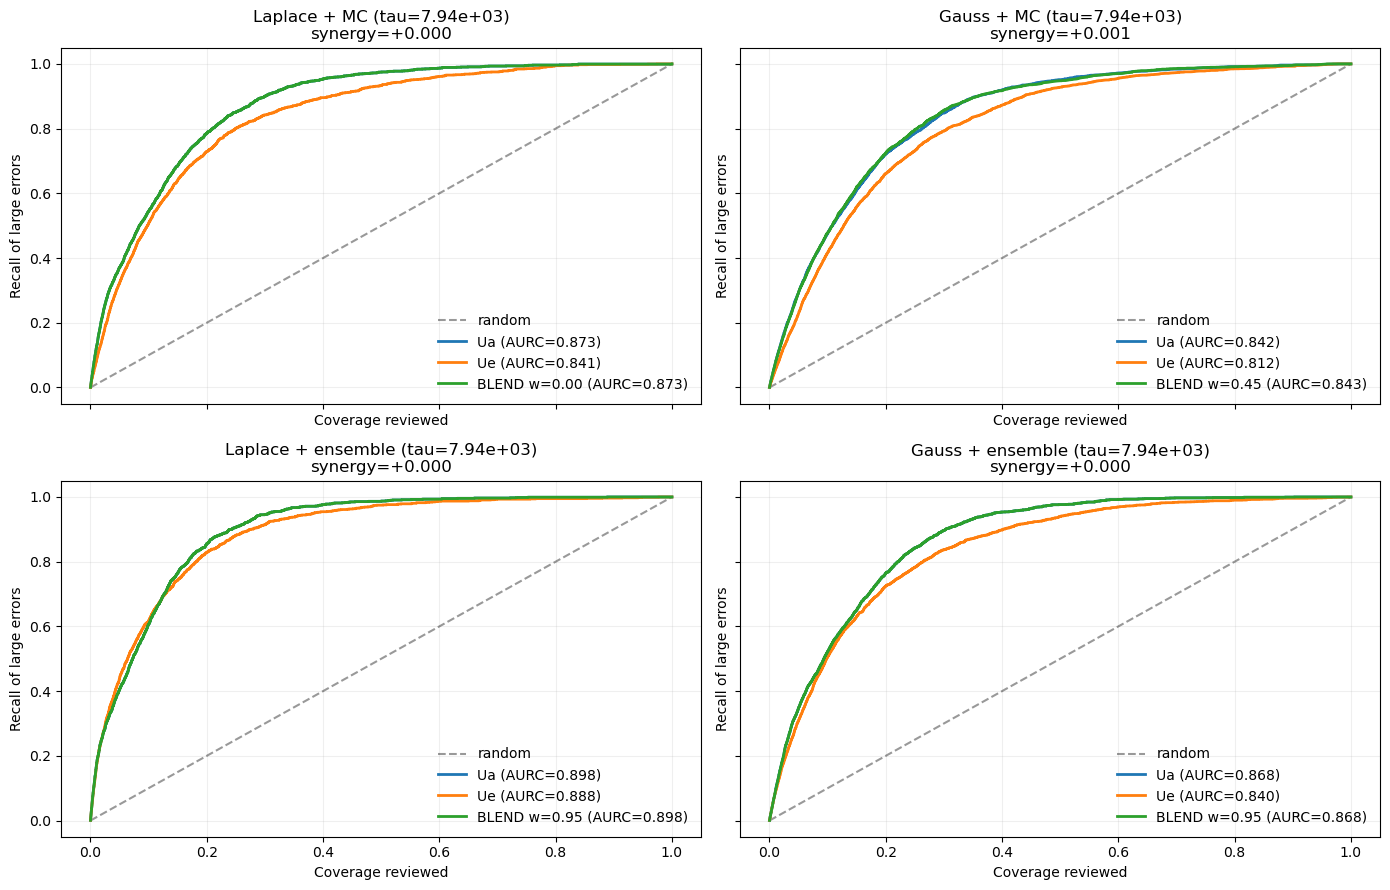

[DIDO] score=dido_strength_raw best_w_epi=0.9500000000000001 synergy=+0.001


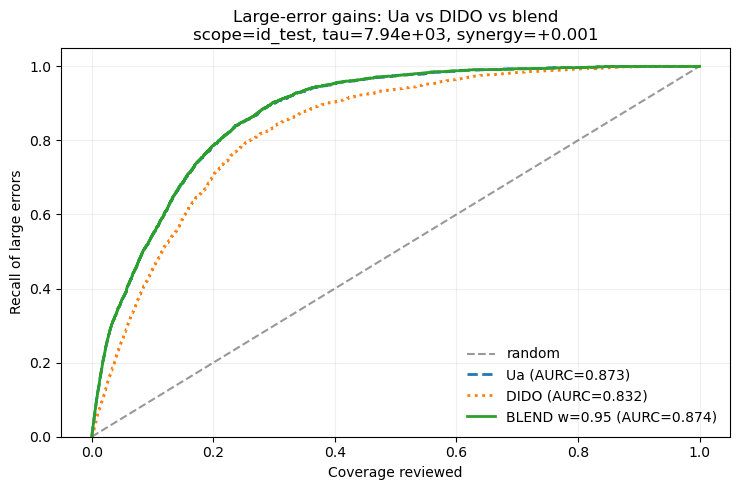

In [105]:
# --- 6) Unique information / synergy (decomposition conclusion) ---
# Conditional tests:
#   - within Ua bins: does z = |err|/Ua rise with Ue?
#   - within Ue bins: does |err| rise with Ua?
# Synergy gains:
#   - Ua, Ue, and best blend(w) gains + ΔAURC
# Optional DIDO synergy: Ua + DIDO vs Ua vs DIDO
# Robust to missing methods / missing evals.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
EVAL_SCOPE = "id_test"  # "id_test" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []
N_BINS = 10
WEIGHTS = np.linspace(0.0, 1.0, 21)
EPS = 1e-8

# Optional DIDO synergy (default off)
INCLUDE_DIDO_SYNERGY = True
DIDO_SIGNAL = "dido_strength_raw"  # "auto" or "dido_entropy_raw" | "dido_vacuity_raw" | "dido_strength_raw"
DIDO_CANDIDATES = ["dido_entropy_raw", "dido_vacuity_raw", "dido_strength_raw"]
DIDO_ALLOW_FLIP = True

try:
    TAU = float(LARGE_ERROR_TAU)
except Exception as e:
    raise RuntimeError("LARGE_ERROR_TAU not defined yet; run the tau cell first") from e

def _label_candidates(label: str) -> list[str]:
    c = [label]
    if label.endswith("_hard"):
        c.append(label.replace("_hard", ""))
    return list(dict.fromkeys(c))

def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return np.asarray(sA, float), np.asarray(sE, float), np.asarray(sT, float)

def _gains(score: np.ndarray, y_large: np.ndarray):
    d = pd.DataFrame({"score": score, "y": y_large}).dropna()
    if d.empty or d["y"].nunique() < 2:
        return None
    d = d.sort_values("score", ascending=False, kind="mergesort")
    total_pos = float(d["y"].sum())
    if total_pos == 0:
        return None
    cum_pos = d["y"].cumsum().to_numpy(float)
    recall = cum_pos / total_pos
    coverage = np.arange(1, len(d) + 1) / float(len(d))
    aurc = float(np.trapezoid(recall, coverage))
    return coverage, recall, aurc

def _corr(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 5:
        return np.nan
    x = x[m]; y = y[m]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(np.argsort(np.argsort(x)), np.argsort(np.argsort(y)))[0, 1])  # Spearman via ranks

def _load_for_scope(spec: MethodSpec):
    parts = []
    df_id = method_id_test_frame(spec).copy()
    df_id["dataset"] = "id:test"
    parts.append(df_id)

    if EVAL_SCOPE.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")

    return pd.concat(parts, ignore_index=True)

# --- Specs: only methods with BOTH ale + epi (MC/ensemble) ---
if "METHODS_FOCUSED" in globals():
    SPECS = [m for m in METHODS_FOCUSED if str(m.epistemic_source).lower() in {"mc", "ensemble"}]
else:
    SPECS = [m for m in METHODS_CORE if str(m.epistemic_source).lower() in {"mc", "ensemble"}]

cond_rows = []
synergy_rows = []
plots = []

for spec in SPECS:
    try:
        df_all = _load_for_scope(spec)
    except Exception as e:
        print(f"[skip] {spec.label}: {type(e).__name__}: {e}")
        continue

    y = df_all.get("y_true", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    mu = df_all.get("mu", pd.Series(np.nan, index=df_all.index)).to_numpy(float)
    abs_err = np.abs(y - mu)
    y_large = (abs_err > TAU).astype(int)

    sA, sE, sT = _sigmas(spec, df_all)

    # filter finite
    m = np.isfinite(sA) & np.isfinite(sE) & np.isfinite(abs_err)
    if not np.any(m):
        print(f"[skip] {spec.label}: no finite Ua/Ue/err")
        continue

    sA = sA[m]; sE = sE[m]; abs_err = abs_err[m]; yL = y_large[m]
    z = abs_err / np.clip(sA, EPS, None)

    # ---- Conditional tests ----
    # within Ua bins: corr(Ue, z)
    try:
        ua_bins = pd.qcut(sA, N_BINS, labels=False, duplicates="drop")
    except ValueError:
        ua_bins = None

    corr_ua_bins = []
    if ua_bins is not None:
        for b in np.unique(ua_bins[~pd.isna(ua_bins)]):
            idx = (ua_bins == b)
            corr_ua_bins.append(_corr(sE[idx], z[idx]))

    # within Ue bins: corr(Ua, |err|)
    try:
        ue_bins = pd.qcut(sE, N_BINS, labels=False, duplicates="drop")
    except ValueError:
        ue_bins = None

    corr_ue_bins = []
    if ue_bins is not None:
        for b in np.unique(ue_bins[~pd.isna(ue_bins)]):
            idx = (ue_bins == b)
            corr_ue_bins.append(_corr(sA[idx], abs_err[idx]))

    cond_rows.append(
        {
            "method": spec.label,
            "n": int(len(abs_err)),
            "median_corr(Ue vs z | Ua bins)": float(np.nanmedian(corr_ua_bins)) if corr_ua_bins else np.nan,
            "mean_corr(Ue vs z | Ua bins)": float(np.nanmean(corr_ua_bins)) if corr_ua_bins else np.nan,
            "median_corr(Ua vs |err| | Ue bins)": float(np.nanmedian(corr_ue_bins)) if corr_ue_bins else np.nan,
            "mean_corr(Ua vs |err| | Ue bins)": float(np.nanmean(corr_ue_bins)) if corr_ue_bins else np.nan,
        }
    )

    # ---- Synergy gains ----
    g_ua = _gains(sA, yL)
    g_ue = _gains(sE, yL)
    if g_ua is None or g_ue is None:
        print(f"[skip] {spec.label}: insufficient data for gains")
        continue

    best = {"w": None, "aurc": -np.inf, "g": None}
    for w in WEIGHTS:
        blend = (1.0 - w) * sA + w * sE
        g = _gains(blend, yL)
        if g is None:
            continue
        if g[2] > best["aurc"]:
            best = {"w": float(w), "aurc": float(g[2]), "g": g}

    synergy = float(best["aurc"] - max(g_ua[2], g_ue[2])) if best["g"] is not None else float("nan")

    synergy_rows.append(
        {
            "method": spec.label,
            "n": int(len(yL)),
            "prev_large": float(np.mean(yL)),
            "AURC(Ua)": float(g_ua[2]),
            "AURC(Ue)": float(g_ue[2]),
            "AURC(best_blend)": float(best["aurc"]),
            "best_w_epi": float(best["w"]) if best["w"] is not None else np.nan,
            "synergy_dAURC": synergy,
        }
    )

    plots.append(
        (
            f"{spec.label} (tau={TAU:.3g})",
            {
                "Ua": g_ua,
                "Ue": g_ue,
                "BLEND": best["g"],
                "best_w": best["w"],
                "synergy": synergy,
            },
        )
    )

df_cond = pd.DataFrame(cond_rows)
df_syn = pd.DataFrame(synergy_rows).sort_values("AURC(best_blend)", ascending=False).reset_index(drop=True)
display(df_cond)
display(df_syn)

# ---- Plot gains curves (one subplot per method, per-axes legend) ----
if plots:
    n = len(plots)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, (title, curves) in zip(axes, plots):
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")

        cov, rec, aurc = curves["Ua"]
        ax.plot(cov, rec, lw=2, label=f"Ua (AURC={aurc:.3f})")

        cov, rec, aurc = curves["Ue"]
        ax.plot(cov, rec, lw=2, label=f"Ue (AURC={aurc:.3f})")

        if curves["BLEND"] is not None:
            cov, rec, aurc = curves["BLEND"]
            w = curves["best_w"]
            ax.plot(cov, rec, lw=2, label=f"BLEND w={w:.2f} (AURC={aurc:.3f})")

        ax.set_title(f"{title}\nsynergy={curves['synergy']:+.3f}")
        ax.set_xlabel("Coverage reviewed")
        ax.set_ylabel("Recall of large errors")
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False, loc="lower right")

    for ax in axes[len(plots):]:
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("No methods produced gains curves.")

# ---- Optional DIDO synergy (Ua + DIDO vs Ua vs DIDO) ----
if INCLUDE_DIDO_SYNERGY and "RUN_DIRS" in globals() and RUN_DIRS.get("dido_lpl") is not None:
    try:
        df_id_d = load_id_dido(RUN_DIRS["dido_lpl"]).copy()
        df_id_d["dataset"] = "id:test"
        parts = [df_id_d]

        if EVAL_SCOPE.strip().lower() == "id_test+ood":
            for ood_label in OOD_LABELS_LOCAL:
                try:
                    df_o_d = load_ood_dido(RUN_DIRS["dido_lpl"], ood_label).copy()
                    df_o_d["dataset"] = f"ood:{ood_label}"
                    parts.append(df_o_d)
                except Exception as e:
                    print(f"[skip] DIDO / ood={ood_label}: {type(e).__name__}: {e}")

        df_d = pd.concat(parts, ignore_index=True)

        # choose dido score
        if str(DIDO_SIGNAL).lower() == "auto":
            dido_col = next((c for c in DIDO_CANDIDATES if c in df_d.columns), None)
        else:
            dido_col = DIDO_SIGNAL if DIDO_SIGNAL in df_d.columns else None
        if dido_col is None:
            raise KeyError(f"No DIDO signal found (DIDO_SIGNAL={DIDO_SIGNAL!r})")

        # Use Laplace+MC as the prediction source for Ua and error labels
        lpl_mc = next((m for m in SPECS if m.key == "lpl_mc"), None)
        if lpl_mc is None:
            raise FileNotFoundError("Laplace+MC not available; cannot label large errors for DIDO block")

        df_pred = _load_for_scope(lpl_mc)
        if "id" not in df_d.columns or "id" not in df_pred.columns:
            raise KeyError("Missing 'id' for joining DIDO with predictions")

        dd = df_d.copy()
        pp = df_pred[["id", "y_true", "mu", "sigma_ale_raw", "sigma_epi_raw"]].copy()
        dd["id"] = pd.to_numeric(dd["id"], errors="coerce")
        pp["id"] = pd.to_numeric(pp["id"], errors="coerce")
        dd = dd.dropna(subset=["id"]); pp = pp.dropna(subset=["id"])
        dd["id"] = dd["id"].astype(int); pp["id"] = pp["id"].astype(int)

        merged = dd.merge(pp, on="id", how="inner")
        if merged.empty:
            raise RuntimeError("No overlap between DIDO ids and prediction ids")

        y = merged["y_true"].to_numpy(float)
        mu = merged["mu"].to_numpy(float)
        abs_err = np.abs(y - mu)
        yL = (abs_err > TAU).astype(int)

        sA_raw = merged.get("sigma_ale_raw", pd.Series(np.nan, index=merged.index)).to_numpy(float)
        sE_raw = merged.get("sigma_epi_raw", pd.Series(np.nan, index=merged.index)).fillna(0.0).to_numpy(float)
        if USE_CALIBRATED_SIGMAS_LOCAL:
            sA, _, _ = calibrated_sigmas(
                head_type="laplace",
                ale_src="analytic",
                epi_src="mc",
                sigma_ale_raw=sA_raw,
                sigma_epi_raw=sE_raw,
            )
        else:
            sA = np.asarray(sA_raw, float)

        dido = pd.to_numeric(merged[dido_col], errors="coerce").to_numpy(float)

        if DIDO_ALLOW_FLIP:
            g_pos = _gains(dido, yL)
            g_neg = _gains(-dido, yL)
            if g_neg is not None and (g_pos is None or g_neg[2] > g_pos[2]):
                dido = -dido
                dido_col = dido_col + " (flipped)"

        g_ale = _gains(sA, yL)
        g_epi = _gains(dido, yL)

        best = {"w": None, "aurc": -np.inf, "g": None}
        for w in WEIGHTS:
            score = (1.0 - w) * sA + w * dido
            g = _gains(score, yL)
            if g is None:
                continue
            if g[2] > best["aurc"]:
                best = {"w": float(w), "aurc": float(g[2]), "g": g}

        synergy = float(best["aurc"] - max(g_ale[2], g_epi[2])) if best["g"] is not None else float("nan")
        print(f"[DIDO] score={dido_col} best_w_epi={best['w']} synergy={synergy:+.3f}")

        plt.figure(figsize=(7.5, 5))
        plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
        plt.plot(g_ale[0], g_ale[1], "--", lw=2, label=f"Ua (AURC={g_ale[2]:.3f})")
        plt.plot(g_epi[0], g_epi[1], ":", lw=2, label=f"DIDO (AURC={g_epi[2]:.3f})")
        if best["g"] is not None:
            plt.plot(best["g"][0], best["g"][1], "-", lw=2, label=f"BLEND w={best['w']:.2f} (AURC={best['aurc']:.3f})")
        plt.xlabel("Coverage reviewed")
        plt.ylabel("Recall of large errors")
        plt.title(f"Large-error gains: Ua vs DIDO vs blend\nscope={EVAL_SCOPE}, tau={TAU:.3g}, synergy={synergy:+.3f}")
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.2)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[skip] DIDO synergy: {type(e).__name__}: {e}")
else:
    if INCLUDE_DIDO_SYNERGY:
        print("[info] DIDO not available; skipping DIDO synergy.")


In [106]:
# --- 7) NF vs Analytic (Laplace + Gauss): CRPS + PICP/PIW + noise-cohort corr/bias ---
# Uses eval paths from config/RUN_DIRS (no hard-coded paths).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
PRED_COVER = 0.90

# ---- Resolve NF eval dirs from RUN_DIRS or cfg.runs ----
def _resolve_run_dir(run_key: str, cfg_key: str):
    if "RUN_DIRS" in globals() and RUN_DIRS.get(run_key) is not None:
        return Path(RUN_DIRS[run_key])
    cfg_runs = (cfg.get("runs", {}) if "cfg" in globals() else {}) or {}
    p = cfg_runs.get(cfg_key)
    if not p:
        return None
    p = Path(p)
    if not p.is_absolute() and "PROJECT_ROOT" in globals():
        p = Path(PROJECT_ROOT) / p
    return p if p.exists() else None

nf_lpl_dir = _resolve_run_dir("nf_lpl", "nf_laplace")
nf_gau_dir = _resolve_run_dir("nf_gau", "nf_gauss")

if "RUN_DIRS" in globals():
    if nf_lpl_dir is not None:
        RUN_DIRS["nf_lpl"] = nf_lpl_dir
    if nf_gau_dir is not None:
        RUN_DIRS["nf_gau"] = nf_gau_dir

for key, path in {"nf_lpl": nf_lpl_dir, "nf_gau": nf_gau_dir}.items():
    if path is None:
        print(f"[warn] {key} eval dir not found in RUN_DIRS or config")
    else:
        csv_path = path / "flow_eval_test.csv"
        if csv_path.exists():
            print(f"[ok] {key} eval dir: {path}")
        else:
            print(f"[warn] {key} eval dir found but missing flow_eval_test.csv: {path}")

def _iter_method_pools():
    if "METHODS_FOCUSED" in globals():
        yield METHODS_FOCUSED
    if "METHODS_CORE" in globals():
        yield METHODS_CORE
    if "METHODS_AUX" in globals():
        yield METHODS_AUX

def _find_spec(pred):
    for pool in _iter_method_pools():
        for s in pool:
            try:
                if pred(s):
                    return s
            except Exception:
                continue
    return None

def _is_analytic(s: MethodSpec):
    return (
        s.head_type in {"laplace", "gauss"}
        and str(s.aleatoric_source).lower() == "analytic"
        and str(s.kind).lower() != "nf"
    )

def _is_nf(s: MethodSpec):
    return str(s.kind).lower() == "nf"

laplace_analytic = _find_spec(lambda s: _is_analytic(s) and s.head_type == "laplace")
gauss_analytic   = _find_spec(lambda s: _is_analytic(s) and s.head_type == "gauss")

laplace_nf = _find_spec(lambda s: _is_nf(s) and s.head_type == "laplace")
gauss_nf   = _find_spec(lambda s: _is_nf(s) and s.head_type == "gauss")

# Fallback: create NF specs if missing but RUN_DIRS has nf_* entries
if laplace_nf is None and "RUN_DIRS" in globals() and RUN_DIRS.get("nf_lpl") is not None:
    try:
        laplace_nf = MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf")
        print("[info] Created fallback Laplace (NF) MethodSpec.")
    except Exception:
        print("[warn] Could not create Laplace (NF) MethodSpec.")

if gauss_nf is None and "RUN_DIRS" in globals() and RUN_DIRS.get("nf_gau") is not None:
    try:
        gauss_nf = MethodSpec("nf_gau", "Gauss (NF)", "gauss", "nf", "none", "nf")
        print("[info] Created fallback Gauss (NF) MethodSpec.")
    except Exception:
        print("[warn] Could not create Gauss (NF) MethodSpec.")

if laplace_analytic is None:
    print("[warn] Laplace analytic MethodSpec not found in method lists.")
if gauss_analytic is None:
    print("[warn] Gauss analytic MethodSpec not found in method lists.")
if laplace_nf is None:
    print("[warn] Laplace NF MethodSpec not found/created; NF comparison will be skipped.")
if gauss_nf is None:
    print("[warn] Gauss NF MethodSpec not found/created; NF comparison will be skipped.")

SPECS = [s for s in [laplace_analytic, gauss_analytic, laplace_nf, gauss_nf] if s is not None]
if not SPECS:
    print("[skip] No analytic/NF specs available.")
else:
    def _get_sigmas_for_eval(spec: MethodSpec, df: pd.DataFrame):
        sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
        sE_raw = df.get("sigma_epi_raw", pd.Series(0.0, index=df.index)).fillna(0.0).to_numpy(float)
        if USE_CALIBRATED_SIGMAS_LOCAL and str(spec.aleatoric_source).lower() == "analytic":
            sA, _, _ = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src="none",
                sigma_ale_raw=sA_raw,
                sigma_epi_raw=sE_raw,
            )
        else:
            sA = np.asarray(sA_raw, float)
        return np.asarray(sA, float)

    def _picp_piw(y, mu, sigma, cover=PRED_COVER):
        z = float(norm.ppf((1 + cover) / 2.0))
        lo = mu - z * sigma
        hi = mu + z * sigma
        mask = np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
        if not np.any(mask):
            return np.nan, np.nan
        inside = (y[mask] >= lo[mask]) & (y[mask] <= hi[mask])
        picp = float(np.mean(inside))
        piw = float(np.mean(hi[mask] - lo[mask]))
        return picp, piw

    def _load_eval(spec: MethodSpec):
        if str(spec.kind).lower() == "nf":
            if "RUN_DIRS" not in globals() or RUN_DIRS.get(spec.key) is None:
                raise FileNotFoundError(f"RUN_DIRS[{spec.key}] is None")
            path = Path(RUN_DIRS[spec.key]) / "flow_eval_test.csv"
            if not path.exists():
                raise FileNotFoundError(f"flow_eval_test.csv not found in {RUN_DIRS[spec.key]}")
            return load_id_nf(RUN_DIRS[spec.key])
        return method_id_test_frame(spec)

    # ---- CRPS + PICP/PIW ----
    rows = []
    for spec in SPECS:
        try:
            df = _load_eval(spec)
        except Exception as e:
            print(f"[skip] {spec.label}: {type(e).__name__}: {e}")
            continue

        y = df["y_true"].to_numpy(float)
        mu = df["mu"].to_numpy(float)
        sA = _get_sigmas_for_eval(spec, df)

        crps = gaussian_crps_mean(y, mu, sA)
        picp, piw = _picp_piw(y, mu, sA, cover=PRED_COVER)

        rows.append(
            {
                "method": spec.label,
                "n": int(len(df)),
                "CRPS": float(crps),
                f"PICP@{int(PRED_COVER*100)}": float(picp),
                f"PIW@{int(PRED_COVER*100)}": float(piw),
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            }
        )

    df_nf_cmp = pd.DataFrame(rows)
    display(df_nf_cmp)

    # ---- Noise-cohort corr/bias ----
    DATASET_CSV = "datasets/craigslist_cleaned.csv"
    ID_COL = "id"
    COHORT_DEFS = {
        "manufacturer+age_bucket": ["manufacturer", "age_bucket"],
        "manufacturer+model": ["manufacturer", "model"],
    }
    AGE_BINS = [0, 2, 4, 7, 10, 15, 25]
    AGE_LABELS = [f"{AGE_BINS[i]}-{AGE_BINS[i+1]}" for i in range(len(AGE_BINS) - 1)]

    if "meta" not in globals():
        usecols = [ID_COL, "manufacturer", "model", "age_years"]
        meta = pd.read_csv(DATASET_CSV, usecols=usecols)
        meta[ID_COL] = pd.to_numeric(meta[ID_COL], errors="coerce")
        meta = meta.dropna(subset=[ID_COL]).drop_duplicates(subset=[ID_COL]).copy()
        meta[ID_COL] = meta[ID_COL].astype(int)
        meta["age_years"] = pd.to_numeric(meta["age_years"], errors="coerce")
        meta["age_bucket"] = pd.cut(meta["age_years"], bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True)

    def _attach_meta(df_eval: pd.DataFrame) -> pd.DataFrame:
        out = df_eval.copy()
        out[ID_COL] = pd.to_numeric(out[ID_COL], errors="coerce")
        out = out.dropna(subset=[ID_COL])
        out[ID_COL] = out[ID_COL].astype(int)
        return out.merge(meta[[ID_COL, "manufacturer", "model", "age_bucket"]], on=ID_COL, how="left")

    def _cohort_key(df: pd.DataFrame, cols):
        return df[cols].astype(str).agg(" / ".join, axis=1)

    def _noise_table(df_eval: pd.DataFrame, spec: MethodSpec, cohort_name: str, cols: list[str]):
        df_eval = _attach_meta(df_eval)
        y = df_eval["y_true"].to_numpy(float)
        mu = df_eval["mu"].to_numpy(float)
        resid = y - mu
        sA = _get_sigmas_for_eval(spec, df_eval)

        tmp = pd.DataFrame({"cohort": _cohort_key(df_eval, cols), "resid": resid, "sA2": np.square(sA)})
        tmp = tmp[np.isfinite(tmp["resid"]) & np.isfinite(tmp["sA2"])]

        g = (
            tmp.groupby("cohort")
            .agg(
                n=("resid", "size"),
                resid_var=("resid", "var"),
                resid_bias=("resid", "mean"),
                mean_sA2=("sA2", "mean"),
            )
            .reset_index()
        )
        g = g[g["n"] >= 100].copy()
        g["cohort_def"] = cohort_name
        g["method"] = spec.label
        return g

    noise_rows = []
    for spec in SPECS:
        try:
            df = _load_eval(spec)
        except Exception as e:
            print(f"[skip] {spec.label}: {type(e).__name__}: {e}")
            continue
        for cohort_name, cols in COHORT_DEFS.items():
            try:
                g = _noise_table(df, spec, cohort_name, cols)
                noise_rows.append(g)
            except Exception as e:
                print(f"[skip] {spec.label} / {cohort_name}: {type(e).__name__}: {e}")

    if noise_rows:
        df_noise_nf = pd.concat(noise_rows, ignore_index=True)
        summary_rows = []
        for (cohort_def, method), sub in df_noise_nf.groupby(["cohort_def", "method"]):
            sub = sub[(sub["resid_var"] > 0) & (sub["mean_sA2"] > 0)].copy()
            if len(sub) < 5:
                continue
            x = np.log(sub["resid_var"].to_numpy(float))
            y = np.log(sub["mean_sA2"].to_numpy(float))
            corr = float(np.corrcoef(x, y)[0, 1]) if (np.std(x) > 0 and np.std(y) > 0) else float("nan")
            summary_rows.append(
                {
                    "cohort_def": cohort_def,
                    "method": method,
                    "n_cohorts": int(len(sub)),
                    "corr(log Var(resid), log E[sA^2])": corr,
                    "median_abs_bias": float(np.median(np.abs(sub["resid_bias"].to_numpy(float)))),
                }
            )
        df_noise_nf_summary = pd.DataFrame(summary_rows).sort_values(
            ["cohort_def", "corr(log Var(resid), log E[sA^2])"], ascending=[True, False]
        )
        display(df_noise_nf_summary)
    else:
        print("[info] No noise-cohort tables produced; check eval files and cohort columns.")


[ok] nf_lpl eval dir: outputs/evals/nf_lpl_l_20251221-222438_304508
[ok] nf_gau eval dir: outputs/evals/nf_gau_l_20251221-204946_304381


,method,n,CRPS,PICP@90,PIW@90,use_calibrated
0,Laplace + MC,25358,1924.361873,0.791466,7361.215002,True
1,Gauss + MC,25358,2705.763866,0.918487,16542.575498,True
2,Laplace (NF),25358,1973.049293,0.953033,14890.064036,True
3,Gauss (NF),25358,2953.082752,0.974367,24976.865062,True


,cohort_def,method,n_cohorts,"corr(log Var(resid), log E[sA^2])",median_abs_bias
3,manufacturer+age_bucket,Laplace + MC,68,0.897345,301.128758
1,manufacturer+age_bucket,Gauss + MC,68,0.892883,686.856865
2,manufacturer+age_bucket,Laplace (NF),68,0.890163,281.516664
0,manufacturer+age_bucket,Gauss (NF),68,0.888710,551.758090
5,manufacturer+model,Gauss + MC,28,0.960839,886.190342
4,manufacturer+model,Gauss (NF),28,0.957803,697.769469
7,manufacturer+model,Laplace + MC,28,0.922901,414.590202
6,manufacturer+model,Laplace (NF),28,0.911952,328.726233


In [107]:
# --- Diagnose why NF has fewer cohorts than analytic (Laplace) ---
# Compares row loss + cohort counts at each stage for:
#   - Laplace (analytic)
#   - Laplace (NF)
#
# Outputs:
#   - eval rows, valid id rows, joined rows
#   - rows with missing cohort cols
#   - rows with valid resid/sigma
#   - cohort counts before/after MIN_COHORT_N

import numpy as np
import pandas as pd
from pathlib import Path

DATASET_CSV = "datasets/craigslist_cleaned.csv"
ID_COL = "id"
MIN_COHORT_N = 100
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

COHORT_DEFS = {
    "manufacturer+age_bucket": ["manufacturer", "age_bucket"],
    "manufacturer+model": ["manufacturer", "model"],
}

AGE_BINS = [0, 2, 4, 7, 10, 15, 25]
AGE_LABELS = [f"{AGE_BINS[i]}-{AGE_BINS[i+1]}" for i in range(len(AGE_BINS) - 1)]

def _iter_method_pools():
    if "METHODS_FOCUSED" in globals():
        yield METHODS_FOCUSED
    if "METHODS_CORE" in globals():
        yield METHODS_CORE
    if "METHODS_AUX" in globals():
        yield METHODS_AUX

def _find_spec(pred):
    for pool in _iter_method_pools():
        for s in pool:
            try:
                if pred(s):
                    return s
            except Exception:
                continue
    return None

laplace_analytic = _find_spec(lambda s: s.head_type == "laplace" and str(s.epistemic_source).lower() == "none")
laplace_nf = _find_spec(lambda s: str(s.kind).lower() == "nf" and s.head_type == "laplace")

# Fallback NF spec if method lists don't include it but RUN_DIRS has nf_lpl
if laplace_nf is None and "RUN_DIRS" in globals() and RUN_DIRS.get("nf_lpl") is not None:
    try:
        laplace_nf = MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf")
    except Exception:
        pass

if laplace_analytic is None:
    print("[warn] Laplace analytic spec not found.")
if laplace_nf is None:
    print("[warn] Laplace NF spec not found.")

if laplace_analytic is None and laplace_nf is None:
    print("[skip] No Laplace analytic/NF specs available.")
else:
    # Load meta once
    usecols = [ID_COL, "manufacturer", "model", "age_years"]
    meta = pd.read_csv(DATASET_CSV, usecols=usecols)
    meta[ID_COL] = pd.to_numeric(meta[ID_COL], errors="coerce")
    meta = meta.dropna(subset=[ID_COL]).drop_duplicates(subset=[ID_COL]).copy()
    meta[ID_COL] = meta[ID_COL].astype(int)
    meta["age_years"] = pd.to_numeric(meta["age_years"], errors="coerce")
    meta["age_bucket"] = pd.cut(meta["age_years"], bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True)

    def _load_eval(spec):
        if spec is None:
            return None
        if str(spec.kind).lower() == "nf":
            return load_id_nf(RUN_DIRS[spec.key])
        return method_id_test_frame(spec)

    def _get_sigmas_for_eval(spec, df):
        sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
        sE_raw = df.get("sigma_epi_raw", pd.Series(0.0, index=df.index)).fillna(0.0).to_numpy(float)
        if USE_CALIBRATED_SIGMAS_LOCAL and spec.aleatoric_source == "analytic":
            sA, _, _ = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src="none",
                sigma_ale_raw=sA_raw,
                sigma_epi_raw=sE_raw,
            )
        else:
            sA = np.asarray(sA_raw, float)
        return np.asarray(sA, float)

    def _attach_meta(df_eval):
        out = df_eval.copy()
        out[ID_COL] = pd.to_numeric(out[ID_COL], errors="coerce")
        n_eval = len(out)
        out = out.dropna(subset=[ID_COL])
        n_valid_id = len(out)
        out[ID_COL] = out[ID_COL].astype(int)
        out = out.merge(meta[[ID_COL, "manufacturer", "model", "age_bucket"]], on=ID_COL, how="left")
        n_joined = len(out)
        return out, n_eval, n_valid_id, n_joined

    def _cohort_key(df, cols):
        return df[cols].astype(str).agg(" / ".join, axis=1)

    def _stats_for_spec(spec, cohort_name, cols):
        df = _load_eval(spec)
        if df is None:
            return None

        df_meta, n_eval, n_valid_id, n_joined = _attach_meta(df)
        n_missing_cols = int(df_meta[cols].isna().any(axis=1).sum())
        df_meta = df_meta.dropna(subset=cols)

        y = df_meta["y_true"].to_numpy(float)
        mu = df_meta["mu"].to_numpy(float)
        resid = y - mu
        sA = _get_sigmas_for_eval(spec, df_meta)

        tmp = pd.DataFrame({
            "cohort": _cohort_key(df_meta, cols),
            "resid": resid,
            "sA2": np.square(sA),
        })
        tmp = tmp[np.isfinite(tmp["resid"]) & np.isfinite(tmp["sA2"])]

        # cohort counts
        counts = tmp.groupby("cohort")["resid"].size()
        n_cohorts_total = int(len(counts))
        n_cohorts_ge = int((counts >= MIN_COHORT_N).sum())
        rows_in_ge = int(counts[counts >= MIN_COHORT_N].sum())

        return {
            "method": spec.label,
            "cohort_def": cohort_name,
            "n_eval_rows": int(n_eval),
            "n_valid_id": int(n_valid_id),
            "n_joined": int(n_joined),
            "rows_missing_cohort_cols": int(n_missing_cols),
            "rows_after_drop_cols": int(len(df_meta)),
            "rows_valid_resid_sigma": int(len(tmp)),
            "n_cohorts_total": n_cohorts_total,
            "n_cohorts_ge_min": n_cohorts_ge,
            "rows_in_ge_min": rows_in_ge,
        }

    rows = []
    for spec in [laplace_analytic, laplace_nf]:
        if spec is None:
            continue
        for cohort_name, cols in COHORT_DEFS.items():
            try:
                rows.append(_stats_for_spec(spec, cohort_name, cols))
            except Exception as e:
                print(f"[skip] {spec.label} / {cohort_name}: {type(e).__name__}: {e}")

    df_diag = pd.DataFrame(rows)
    display(df_diag)


,method,cohort_def,n_eval_rows,n_valid_id,n_joined,rows_missing_cohort_cols,rows_after_drop_cols,rows_valid_resid_sigma,n_cohorts_total,n_cohorts_ge_min,rows_in_ge_min
0,Laplace (NF),manufacturer+age_bucket,25358,25358,25358,0,25358,25358,103,68,24193
1,Laplace (NF),manufacturer+model,25358,25358,25358,0,25358,25358,4513,28,4055
2,Laplace (NF),manufacturer+age_bucket,25358,25358,25358,0,25358,25358,103,68,24193
3,Laplace (NF),manufacturer+model,25358,25358,25358,0,25358,25358,4513,28,4055


[skip] Laplace (NF) (ID): ValueError: Unhandled core spec: MethodSpec(key='nf_lpl', label='Laplace (NF)', head_type='laplace', aleatoric_source='nf', epistemic_source='none', kind='nf')
[skip] Laplace + DIDO (ID): ValueError: Unhandled core spec: MethodSpec(key='dido_lpl', label='Laplace + DIDO', head_type='laplace', aleatoric_source='analytic', epistemic_source='dido', kind='dido')


,method,head_type,mae_id,crps_id,mae_ood,crps_ood
0,Laplace + ensemble,laplace,2084.424459,1561.654433,5207.929849,4103.056487
1,Point,point,2205.017043,NaN,5349.239090,NaN
2,Laplace + MC,laplace,2559.358448,1921.777235,5494.136890,4203.128493
3,Gauss + ensemble,gauss,3187.595718,2367.854851,5839.654201,4406.610436
4,Gauss + MC,gauss,3674.631045,2714.313451,6375.190670,4737.017384


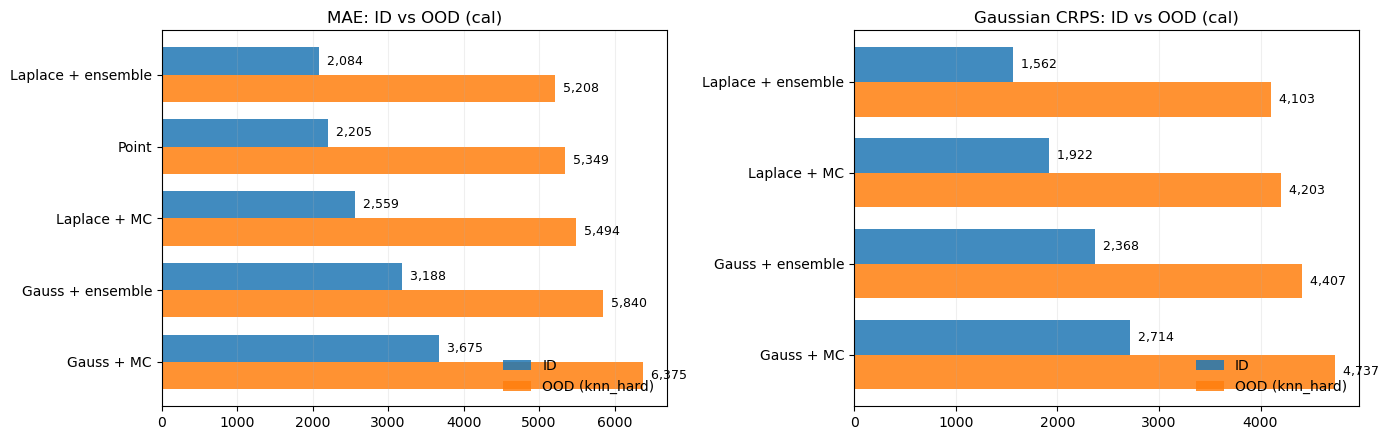

In [108]:
# --- ID vs OOD metrics (side-by-side bars): MAE + CRPS ---
# Blue = ID:test, Orange = OOD
# Robust to missing methods / missing OOD evals.
# Uses calibrated or raw sigmas for CRPS via USE_CALIBRATED_SIGMAS_LOCAL.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
OOD_LABEL_TO_PLOT = (OOD_LABELS[0] if ("OOD_LABELS" in globals() and len(OOD_LABELS) > 0) else "knn_hard")

# If gaussian_crps_mean isn't defined earlier, define a local one
if "gaussian_crps_mean" not in globals():
    from scipy.stats import norm as _norm
    def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
        y = np.asarray(y, float); mu = np.asarray(mu, float); sigma = np.asarray(sigma, float)
        m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
        if not np.any(m):
            return float("nan")
        y = y[m]; mu = mu[m]; sigma = sigma[m]
        z = (y - mu) / sigma
        crps = sigma * (z * (2 * _norm.cdf(z) - 1) + 2 * _norm.pdf(z) - 1 / np.sqrt(np.pi))
        return float(np.mean(crps))

def _sigmas_total(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
        return np.asarray(sT, float)
    sA = np.asarray(sA_raw, float)
    sE = np.asarray(sE_raw, float)
    return np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))

def _compute_metrics_for(spec: MethodSpec, df: pd.DataFrame) -> dict:
    y = df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float)
    mu = df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)
    mae = float(np.nanmean(np.abs(y - mu))) if len(df) else float("nan")
    if spec.head_type == "point":
        return {"MAE": mae, "CRPS": float("nan")}
    sT = _sigmas_total(spec, df)
    crps = gaussian_crps_mean(y, mu, sT)
    return {"MAE": mae, "CRPS": crps}

# Prefer METHODS_FOCUSED if present (your “core + extensions” list), else METHODS_CORE
SPECS = (METHODS_FOCUSED if "METHODS_FOCUSED" in globals() else METHODS_CORE)

rows = []
for spec in SPECS:
    # ID
    try:
        df_id = method_id_test_frame(spec)
        id_m = _compute_metrics_for(spec, df_id)
    except Exception as e:
        print(f"[skip] {spec.label} (ID): {type(e).__name__}: {e}")
        continue

    # OOD (may be missing)
    ood_m = {"MAE": float("nan"), "CRPS": float("nan")}
    try:
        df_ood = method_ood_frame(spec, OOD_LABEL_TO_PLOT)
        ood_m = _compute_metrics_for(spec, df_ood)
    except Exception as e:
        print(f"[skip] {spec.label} (OOD={OOD_LABEL_TO_PLOT}): {type(e).__name__}: {e}")

    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "mae_id": id_m["MAE"],
            "crps_id": id_m["CRPS"],
            "mae_ood": ood_m["MAE"],
            "crps_ood": ood_m["CRPS"],
        }
    )

df_idood = pd.DataFrame(rows)
display(df_idood.sort_values("mae_id", ascending=True).reset_index(drop=True))

def _grouped_barh(ax, labels, v_id, v_ood, title, fmt):
    y = np.arange(len(labels))
    h = 0.38
    ax.barh(y - h/2, v_id, height=h, color="tab:blue", alpha=0.85, label="ID")
    ax.barh(y + h/2, v_ood, height=h, color="tab:orange", alpha=0.85, label=f"OOD ({OOD_LABEL_TO_PLOT})")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

    for yi, (a, b) in enumerate(zip(v_id, v_ood)):
        if np.isfinite(a):
            ax.text(a, yi - h/2, "  " + fmt(a), va="center", ha="left", fontsize=9)
        if np.isfinite(b):
            ax.text(b, yi + h/2, "  " + fmt(b), va="center", ha="left", fontsize=9)

# Order methods by ID MAE
order = df_idood.sort_values("mae_id", ascending=True)["method"].tolist()
dfp = df_idood.set_index("method").reindex(order).reset_index()

# Plot MAE (include point)
mae_id = dfp["mae_id"].to_numpy(float)
mae_ood = dfp["mae_ood"].to_numpy(float)
labels_mae = dfp["method"].tolist()

# Plot CRPS (exclude point automatically via NaNs)
mask_crps = np.isfinite(dfp["crps_id"].to_numpy(float)) | np.isfinite(dfp["crps_ood"].to_numpy(float))
dfc = dfp[mask_crps].copy()
crps_id = dfc["crps_id"].to_numpy(float)
crps_ood = dfc["crps_ood"].to_numpy(float)
labels_crps = dfc["method"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, max(4.5, 0.35 * len(labels_mae))))

_grouped_barh(
    axes[0],
    labels_mae,
    mae_id,
    mae_ood,
    title=f"MAE: ID vs OOD ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})",
    fmt=lambda v: f"{v:,.0f}",
)

_grouped_barh(
    axes[1],
    labels_crps,
    crps_id,
    crps_ood,
    title=f"Gaussian CRPS: ID vs OOD ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})",
    fmt=lambda v: f"{v:,.0f}",
)

axes[0].legend(loc="lower right", frameon=False)
axes[1].legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()
